# EV2 - Proyecto de Mineria de Datos

*Integrantes* :<b>Flavio Henriquez / Bastian Bianchi / Martin Pero</b> <br>
*Docente* : <b>Italo Bonnet</b>  <br>
*Asignatura* : <b>Mineria de datos BIY7121-005D</b><br>
*Grupo* : <b>4</b>

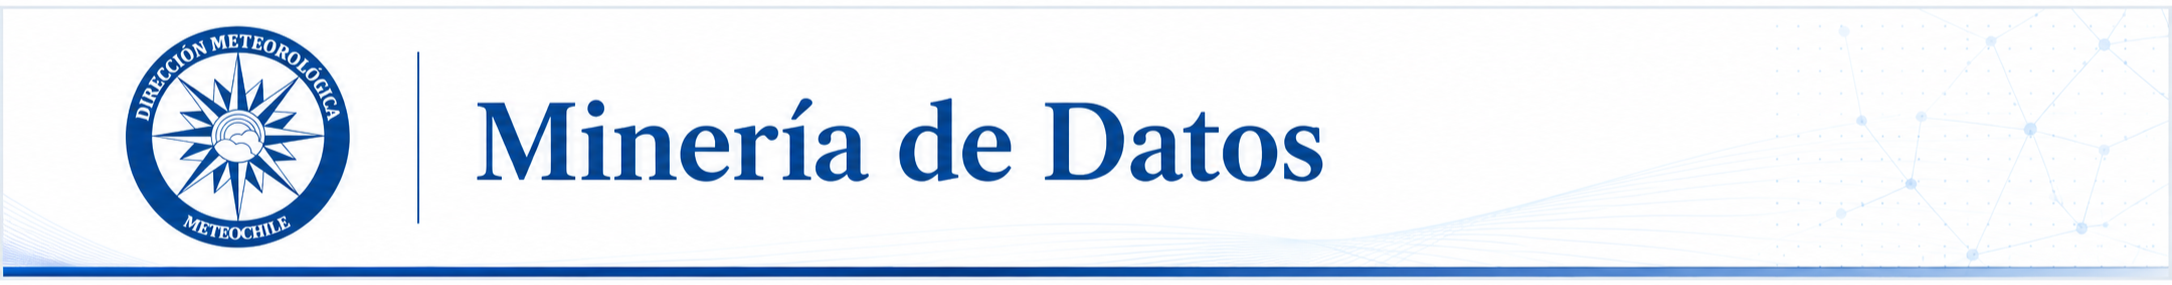

## Analisis de precipitaciones, temperaturas y estaciones meteorologicas en Chile

**Asignatura:** BIY7121 - Mineria de Datos  
**Metodologia:** CRISP-DM  
**Dataset base:** precipitaciones, temperaturas y estaciones meteorologicas de Chile  
**Periodo de analisis:** 2021-2025

Este notebook desarrolla un proyecto de mineria de datos aplicado a informacion meteorologica nacional. El objetivo es analizar el comportamiento de las precipitaciones y temperaturas registradas por estaciones meteorologicas, detectar patrones climaticos relevantes y construir modelos predictivos y descriptivos que apoyen la toma de decisiones.

## Estructura del notebook

La estructura del trabajo sigue la pauta entregada en `estructura.txt` y se mantiene alineada con CRISP-DM:

1. **Entendimiento del Negocio**: contexto, datos relevantes, hipotesis, KPIs y problema de negocio.
2. **Entendimiento de Datos**: tipos de variables, nulos, outliers, transformaciones exploratorias, estadisticos, correlaciones y patrones.
3. **Transformacion / Preparacion de Datos**: preparacion final para modelos, imputacion, encoding, escalamiento y dataset para cluster.
4. **Modelamiento**: regresion, clasificacion y cluster, separando seleccion de variables, parametros, aplicacion y metricas.
5. **Evaluacion**: se desarrollara despues de cerrar modelamiento.
6. **Deploy / Despliegue**: se desarrollara al final, despues de evaluar resultados.

En esta version se conserva completo el avance hasta la Fase 3 y se reinicia la Fase 4 para construirla paso a paso.


In [1]:
from pathlib import Path
import csv
import json
import re
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, QuantileTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.svm import SVR, SVC
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
try:
    from kneed import KneeLocator
except ImportError:
    KneeLocator = None
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, silhouette_score, silhouette_samples, classification_report,
    adjusted_rand_score, normalized_mutual_info_score, fowlkes_mallows_score, calinski_harabasz_score,
)

try:
    import seaborn as sns
    SEABORN_DISPONIBLE = True
except ImportError:
    SEABORN_DISPONIBLE = False
    sns = None

In [2]:
# Toda la carga de datos se hace en memoria desde las raw URLs de GitHub.
# No se descarga ningun archivo a disco: cada lectura pide el dato directamente al repositorio.
RAW_BASE = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/refs/heads/main'

def descargar_texto(url, encoding='utf-8', errores='strict'):
    with urllib.request.urlopen(url) as respuesta:
        return respuesta.read().decode(encoding, errors=errores)

def descargar_bytes(url):
    with urllib.request.urlopen(url) as respuesta:
        return respuesta.read()

**Analisis de la fuente de datos:**

Los datos se consumen directamente desde GitHub mediante raw URLs, en memoria y sin copia local. El proyecto combina **dos datasets**:

1. **Dataset meteorologico de estaciones de Chile (DMC)**: precipitacion y temperatura diaria por estacion. Es la fuente principal (target de clasificacion de lluvia y de regresion de temperatura).
2. **Dataset atmosferico de reanalisis de la NASA (NASA POWER)**: humedad, viento, radiacion, nubosidad y presion por estacion y dia. Aporta el **estado atmosferico** que mejora la regresion.

El dataset atmosferico se obtuvo del proyecto **NASA POWER** (Prediction Of Worldwide Energy Resources, NASA Langley Research Center):

- Portal oficial: https://power.larc.nasa.gov/
- API usada (datos diarios por punto): https://power.larc.nasa.gov/api/temporal/daily/point

Se consulto por coordenadas de cada estacion (latitud/longitud) para el periodo 2021-2025, y el resultado se consolido en `atmosfera_diario.csv`. Se complementan con metadata de estaciones, el raster Koppen-Geiger y el mapa de Chile. Todo es reproducible en cualquier equipo con conexion.

In [3]:
PRECIP_TEMP_CSV = f'{RAW_BASE}/dataset_precipitaciones_temperaturas_chile.csv'
PRECIP_DIARIA_CSV = f'{RAW_BASE}/dataset_precipitaciones_diarias_chile_COMPLETO.csv'
STATIONS_JSON = f'{RAW_BASE}/getEstacionesRedEma.json'
CHILE_GEOJSON = f'{RAW_BASE}/chile_country.geojson'
KOPPEN_TIF = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/main/koppen_geiger_1991_2020_1km.tif'
KOPPEN_LEGEND = f'{RAW_BASE}/legend.txt'
ATMOSFERA_CSV = f'{RAW_BASE}/atmosfera_diario.csv'  # reanalisis NASA POWER

fuentes = pd.DataFrame([
    {'fuente': 'Dataset meteorologico: precipitaciones + temperaturas', 'origen': 'Estaciones DMC (Chile)', 'url': PRECIP_TEMP_CSV},
    {'fuente': 'Dataset atmosferico diario', 'origen': 'NASA POWER (reanalisis)', 'url': ATMOSFERA_CSV},
    {'fuente': 'Catalogo de estaciones de la Red EMA', 'origen': 'Red EMA / DMC', 'url': STATIONS_JSON},
    {'fuente': 'Precipitaciones diarias (cobertura completa)', 'origen': 'Estaciones DMC (Chile)', 'url': PRECIP_DIARIA_CSV},
    {'fuente': 'Zonas climaticas Koppen-Geiger 1km', 'origen': 'Raster climatico 1991-2020', 'url': KOPPEN_TIF},
    {'fuente': 'Mapa de Chile (GeoJSON)', 'origen': 'Limites geograficos', 'url': CHILE_GEOJSON},
])
display(fuentes)

,fuente,origen,url
0,Dataset meteorologico: precipitaciones + tempe...,Estaciones DMC (Chile),https://raw.githubusercontent.com/4mnesia/Data...
1,Dataset atmosferico diario,NASA POWER (reanalisis),https://raw.githubusercontent.com/4mnesia/Data...
2,Catalogo de estaciones de la Red EMA,Red EMA / DMC,https://raw.githubusercontent.com/4mnesia/Data...
3,Precipitaciones diarias (cobertura completa),Estaciones DMC (Chile),https://raw.githubusercontent.com/4mnesia/Data...
4,Zonas climaticas Koppen-Geiger 1km,Raster climatico 1991-2020,https://raw.githubusercontent.com/4mnesia/Data...
5,Mapa de Chile (GeoJSON),Limites geograficos,https://raw.githubusercontent.com/4mnesia/Data...


**Analisis de disponibilidad de las fuentes:**

Todas las fuentes se consumen **en memoria** desde las raw URLs de GitHub: el notebook **no descarga archivos al disco ni clona** ningun repositorio (ya no se usa la carpeta `.data`). Asi queda reproducible en cualquier equipo con conexion -incluido Google Colab- sin pasos previos de preparacion de datos.

# 1. Entendimiento del Negocio

La fase de entendimiento del negocio define el contexto del problema, los datos disponibles, las hipotesis iniciales, los indicadores clave y el problema de mineria de datos que se abordara. Esta fase es fundamental en CRISP-DM, porque orienta las decisiones posteriores de limpieza, transformacion, modelamiento y evaluacion.

## 1.1 Contexto

Chile presenta una geografia extensa y diversa, con diferencias climaticas importantes entre el norte, centro, sur, zonas costeras, valles, precordillera y cordillera. Esta diversidad hace que el comportamiento de las precipitaciones y temperaturas varie de forma significativa segun ubicacion, altura, estacion del anio y zona geografica.

El analisis de datos meteorologicos permite transformar registros historicos en conocimiento util para la toma de decisiones. En particular, la informacion de precipitaciones, temperaturas y estaciones puede apoyar procesos relacionados con monitoreo climatico, gestion territorial, planificacion agricola, prevencion de riesgos, gestion hidrica y deteccion de eventos extremos.

Desde la perspectiva de mineria de datos, el problema no consiste solo en describir registros climaticos, sino en descubrir patrones, relaciones y comportamientos que no son evidentes al observar los datos de forma aislada. Por ello, el proyecto se abordara mediante una combinacion de analisis exploratorio, limpieza de datos, transformacion de variables, modelos predictivos y modelos descriptivos.

## 1.2 Datos relevantes

Los datos se leen **en memoria** desde las **raw URLs** del repositorio publico `4mnesia/DataMining_Datos` en GitHub. **No se descarga ni se clona nada** al disco (no existe carpeta `.data`): cada lectura pide el archivo directamente a su URL, lo que mantiene el proyecto reproducible en cualquier equipo con conexion. Se combinan dos datasets principales mas recursos de apoyo:

| Fuente | Contenido | Uso en el proyecto |
|---|---|---|
| Dataset DMC: precipitaciones + temperaturas | Precipitacion, temperatura (max/min/media), fecha, estacion y variables geograficas | Fuente principal: target de regresion (`temp_media`) y de clasificacion (lluvia) |
| Dataset atmosferico (reanalisis NASA POWER) `atmosfera_diario.csv` | Humedad, viento, radiacion, nubosidad, presion por estacion y dia | Predictores atmosfericos del dia, que mejoran la regresion |
| Catalogo de estaciones `getEstacionesRedEma.json` | 148 estaciones de la Red EMA: codigo, nombre, region, zona, coordenadas, altura, codigos OMM/OACI | Cobertura territorial y base para el clustering de estaciones |
| Precipitaciones diarias `..._COMPLETO.csv` | Precipitacion diaria por estacion (cobertura completa) | Respaldo de cobertura para el analisis de estaciones |
| Raster Koppen-Geiger `koppen_geiger_1991_2020_1km.tif` | Zona climatica oficial por coordenada | Contexto climatico y apoyo al clustering |
| Mapa de Chile `chile_country.geojson` | Poligono del pais | Visualizaciones geograficas |

> El dataset atmosferico proviene de **NASA POWER** (NASA Langley Research Center): portal https://power.larc.nasa.gov/ , API de datos diarios por punto https://power.larc.nasa.gov/api/temporal/daily/point

Resumen verificado del dataset principal:

| Caracteristica | Valor |
|---|---:|
| Registros | 187.876 |
| Periodo | 2021-01-01 a 2025-12-31 |
| Estaciones presentes | 109 |
| Regiones | 16 |
| Zonas geograficas | Cordillera, Litoral, PreCordillera, Secano Costero, Secano Interior, Valle |
| Filas con formato especial a corregir | 74.112 |
| Nulos en `agua_caida` | 9,08% |
| Nulos en temperatura (`temp_*`) | 11-12% |

Variables principales:

| Grupo | Variables | Descripcion |
|---|---|---|
| Temporales | `fecha`, `anio`, `mes`, `dia` | Estacionalidad y comportamiento por periodo. |
| Geograficas | `region`, `nombre_region`, `latitud`, `longitud`, `altura`, `zona_geografica` | Relacionan el clima con la ubicacion. |
| Estacion | `codigo_estacion`, `nombre_estacion` | Identifican el origen de cada registro. |
| Precipitacion | `agua_caida` | Lluvia diaria (objetivo de clasificacion). |
| Temperatura | `temp_max`, `temp_min`, `temp_media` | Comportamiento termico (`temp_media` es el objetivo de regresion). |
| Atmosfericas (reanalisis) | `humedad`, `viento`, `radiacion`, `nubosidad`, `presion` | Estado atmosferico del dia, predictoras de la regresion. |

El dataset principal presenta filas completas encerradas entre comillas, por lo que requiere una **carga controlada** antes del analisis (se resuelve en la Fase 2).

**Analisis de los datos relevantes:**

El dataset principal combina volumen temporal (5 anios), cobertura territorial (109 estaciones, 16 regiones) y variables climaticas y atmosfericas, lo que sostiene un objetivo predictivo y no solo descriptivo. La presencia de nulos moderados y de filas mal formateadas anticipa el trabajo de limpieza de la Fase 2.

## 1.3 Hipotesis y tesis consideradas

### Tesis general del proyecto

El comportamiento de las precipitaciones y temperaturas en Chile puede explicarse parcialmente mediante variables temporales, geograficas, termicas y atmosfericas. A partir de ellas es posible detectar patrones climaticos y construir modelos predictivos y descriptivos utiles.

### Hipotesis de trabajo

Se plantean **dos hipotesis por familia de modelo** (regresion, clasificacion y cluster): seis en total. Son hipotesis sobre **patrones y relaciones de los datos** -no sobre metricas de los modelos-, y cada una es **trazable** a una evidencia concreta de las fases siguientes.

**Regresion (temperatura media diaria)**

| Hipotesis | Descripcion | Como se contrasta |
|---|---|---|
| HR1 | La temperatura media diaria esta determinada principalmente por la ubicacion (latitud, altura) y la epoca del anio. | Matriz de correlacion general (2.9) y `R2` del modelo (4.1 / 5.1). |
| HR2 | El estado atmosferico (NASA POWER) y la persistencia (temperatura del dia anterior) aportan senal adicional sobre la base geografica-temporal. | Aporte medido del bloque atmosferico en la regresion (4.1). |

**Clasificacion (ocurrencia de lluvia, `llueve`)**

| Hipotesis | Descripcion | Como se contrasta |
|---|---|---|
| HC1 | La ocurrencia de lluvia tiene un patron estacional y territorial marcado (mas frecuente en el sur y en invierno). | Tasa de lluvia por zona y mes (Fase 2) y desempeno por zona/mes (Fase 5). |
| HC2 | La persistencia (lluvia de dias previos) es el predictor individual mas fuerte de que llueva, por encima del estado atmosferico instantaneo. | AUC univariada por variable (Fase 5, analisis exploratorio del pronostico). |

**Cluster (perfiles de estaciones)**

| Hipotesis | Descripcion | Como se contrasta |
|---|---|---|
| HK1 | **Granularidad ESPACIAL:** las estaciones meteorologicas se agrupan en las zonas climaticas Koppen de Chile. | Cluster espacial: validacion intrinseca (Hopkins, silhouette, Calinski-Harabasz) + extrinseca vs Koppen (ARI / NMI / Fowlkes-Mallows) (4.3 / 5). |
| HK2 | **Granularidad TEMPORAL:** el clima se organiza en las 4 estaciones del anio (verano/otono/invierno/primavera). | Cluster temporal de las mediciones mensuales normalizadas por estacion + validacion extrinseca vs la estacion del anio: ARI / NMI (4.3). |

Estas hipotesis guian la seleccion de variables y la construccion de nuevas caracteristicas en las fases siguientes.

## 1.4 KPIs relevantes

Los KPI traducen las variables disponibles en **indicadores medibles** que conectan el clima con decisiones de negocio (gestion hidrica, agricola y de riesgos) y dan una base objetiva para justificar los modelos.

| KPI | Formula o criterio | Utilidad |
|---|---|---|
| **Precipitacion acumulada** | Suma de `agua_caida` por estacion, region, zona o periodo | Identificar territorios con mayor volumen de lluvia. |
| **Precipitacion promedio diaria** | Promedio de `agua_caida` | Comparar el comportamiento normal entre estaciones o regiones. |
| **Porcentaje de dias con lluvia** | Dias con `agua_caida > 0` / total de dias | Medir la frecuencia de lluvia de forma comparable. |
| **Eventos de lluvia intensa** | Registros sobre umbral estadistico (Q3 + 1.5*IQR de los dias con lluvia, regla de Tukey) | Detectar eventos relevantes para riesgo climatico. |
| **Temperatura media y rango termico** | `temp_media`, `temp_max - temp_min` | Caracterizar el regimen termico (objetivo de la regresion). |
| **Porcentaje de nulos** | `isna()` por variable | Vigilar la calidad de los datos. |

**Analisis de KPI:**

Los KPI conectan las variables disponibles con decisiones de negocio (precipitacion acumulada, lluvia intensa, temperatura, cobertura territorial) y dan una base medible para justificar los modelos posteriores.

## 1.5 Problema de negocio (Prediccion)

El problema de negocio es anticipar y comprender el comportamiento de precipitaciones y temperaturas en Chile usando informacion historica, geografica, temporal y atmosferica. Cada tecnica se aplica a la variable que mejor predice:

### Problema predictivo de regresion

Estimar la **temperatura media diaria** (`temp_media`) de cada estacion a partir de su ubicacion, la epoca del anio, el estado atmosferico del dia (segundo dataset de reanalisis) y la persistencia (temperatura del dia anterior). Se elige la temperatura como objetivo de regresion porque es una variable continua y predecible a escala diaria; la precipitacion diaria, en cambio, es caotica (su parte predecible es baja) y se aborda como clasificacion.

**Variable objetivo:** `temp_media` (grados C por dia y estacion).

### Problema predictivo de clasificacion

Clasificar a nivel diario si hay lluvia (`llueve`) o lluvia intensa (`lluvia_intensa`).

### Problema descriptivo de clustering

Segmentar estaciones por perfil climatico.

### Criterios de exito

- **Regresion (temperatura diaria):** `R2` alto (objetivo >= 0.7) y `RMSE` bajo en grados C.
- **Clasificacion (lluvia):** `F1` por encima del azar, priorizando `recall` en eventos intensos.
- **Cluster:** `silhouette` con grupos cohesivos.

## Cierre de Fase 1

La Fase 1 establece el marco formal del proyecto. Se definio el contexto, se verificaron las fuentes de datos disponibles, se formularon **seis hipotesis (dos por familia de modelo)** trazables a las fases siguientes, se establecieron KPI relevantes y se delimito el problema de negocio como un proyecto mixto de prediccion y descripcion climatica.

La siguiente fase corresponde al **Entendimiento de Datos**, donde se cargara el dataset, se corregira el formato especial de algunas filas, se identificaran tipos de variables, nulos, outliers, estadisticos basicos, correlaciones y primeros patrones observados.

# 2. Entendimiento de Datos

En esta fase se estudia la estructura real del dataset antes de tomar decisiones de limpieza profunda o modelamiento. El objetivo es conocer la calidad de los datos, identificar tipos de variables, nulos, outliers, distribuciones, correlaciones y primeros patrones climaticos.

La decision principal de esta fase es trabajar con el archivo `dataset_precipitaciones_temperaturas_chile.csv`, porque integra precipitaciones, temperaturas, estaciones y variables geograficas. El archivo de precipitaciones diarias se usara como respaldo si se requiere contrastar la variable `agua_caida`.


## 2.0 Carga controlada del dataset principal

Antes de analizar los datos se debe resolver un problema de formato detectado en el CSV principal: una parte de las filas viene encerrada completamente entre comillas. Si se carga el archivo directamente, esas filas quedan interpretadas como un solo campo y se distorsionan los tipos de datos, los nulos y los conteos de estaciones.

Por esta razon se construye una carga controlada. Esta carga no cambia los valores originales del dataset; solo corrige la lectura de filas completas entre comillas para que cada columna quede en su posicion correcta.


In [4]:
COLUMNAS_CLIMA = [
    'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
    'anio', 'mes', 'dia', 'agua_caida', 'fecha', 'nombre_estacion',
    'nombre_region', 'zona_geografica', 'temp_max', 'temp_min', 'temp_media'
]


In [5]:
def leer_filas_clima(url_csv):
    texto = descargar_texto(url_csv, encoding='utf-8-sig')
    lineas = texto.splitlines()

    filas = []
    filas_entre_comillas = 0
    filas_con_error = []

    for numero_linea, fila in enumerate(lineas[1:], start=2):  # se omite el encabezado
        if len(fila) >= 2 and fila[0] == '"' and fila[-1] == '"':
            filas_entre_comillas += 1
            fila = fila[1:-1].replace('""', '"')

        valores = next(csv.reader([fila]))
        if len(valores) == len(COLUMNAS_CLIMA):
            filas.append(valores)
        else:
            filas_con_error.append((numero_linea, len(valores)))

    return filas, filas_entre_comillas, filas_con_error

In [6]:
def corregir_texto_mojibake(valor):
    if pd.isna(valor):
        return valor
    valor = str(valor)
    try:
        return valor.encode('latin1').decode('utf-8')
    except UnicodeError:
        return valor


def convertir_tipos_clima(filas):
    datos = pd.DataFrame(filas, columns=COLUMNAS_CLIMA)

    columnas_numericas = [
        'codigo_estacion', 'region', 'altura', 'latitud', 'longitud',
        'anio', 'mes', 'dia', 'agua_caida', 'temp_max', 'temp_min', 'temp_media'
    ]
    for columna in columnas_numericas:
        datos[columna] = pd.to_numeric(datos[columna], errors='coerce')

    datos['fecha'] = pd.to_datetime(datos['fecha'], errors='coerce')

    for columna in ['nombre_estacion', 'nombre_region', 'zona_geografica']:
        datos[columna] = datos[columna].apply(corregir_texto_mojibake).astype('string').str.strip()

    return datos


In [7]:
def cargar_dataset_clima(ruta_csv):
    filas, filas_entre_comillas, filas_con_error = leer_filas_clima(ruta_csv)
    datos = convertir_tipos_clima(filas)

    resumen = {
        'filas_cargadas': len(datos),
        'columnas_cargadas': datos.shape[1],
        'filas_entre_comillas_corregidas': filas_entre_comillas,
        'filas_con_error': len(filas_con_error),
    }

    return datos, resumen, filas_con_error


In [8]:
df, resumen_carga, filas_con_error = cargar_dataset_clima(PRECIP_TEMP_CSV)

display(pd.DataFrame([resumen_carga]))
display(df.head(3))


,filas_cargadas,columnas_cargadas,filas_entre_comillas_corregidas,filas_con_error
0,187876,16,74112,0


,codigo_estacion,region,altura,latitud,longitud,anio,mes,dia,agua_caida,fecha,nombre_estacion,nombre_region,zona_geografica,temp_max,temp_min,temp_media
0,170001,15,4084,-17.595,-69.4775,2023,1,1,NaN,2023-01-01,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
1,170001,15,4084,-17.595,-69.4775,2023,1,2,NaN,2023-01-02,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN
2,170001,15,4084,-17.595,-69.4775,2023,1,3,NaN,2023-01-03,Visviri Tenencia,Arica y Parinacota,Cordillera,NaN,NaN,NaN


**Analisis de carga:**

La carga controlada permite trabajar con el dataset principal sin perder columnas ni registros. El punto mas importante es que las filas completas entre comillas no se eliminan: se corrige su lectura para conservar la informacion disponible. Esto es coherente con buenas practicas de preparacion de datos, porque primero se corrige el problema de estructura antes de evaluar nulos, outliers o patrones.


## 2.1 Identificar Tipos de variables/atributos

En mineria de datos es necesario distinguir entre variables numericas, categoricas, temporales e identificadores. Esta clasificacion define que analisis se puede hacer y que transformaciones seran necesarias antes del modelamiento.


In [9]:
# Tipos de cada variable y nulos, leidos en duro desde el df
tipos_variables = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'nulos': df.isna().sum(),
    'pct_nulos': (df.isna().mean() * 100).round(2)
})
display(tipos_variables)

,tipo,nulos,pct_nulos
codigo_estacion,int64,0,0.00
region,int64,0,0.00
altura,int64,0,0.00
latitud,float64,0,0.00
longitud,float64,0,0.00
anio,int64,0,0.00
mes,int64,0,0.00
dia,int64,0,0.00
agua_caida,float64,17063,9.08
fecha,datetime64[us],0,0.00


**Analisis de tipos:**

El dataset combina variables climaticas, geograficas, temporales y categoricas. Para analisis estadistico y modelamiento, las variables numericas pueden usarse directamente despues de tratar nulos y outliers. Las variables categoricas como `nombre_region` y `zona_geografica` requeriran encoding en fases posteriores. La variable `codigo_estacion` identifica observaciones, pero no debe interpretarse como magnitud numerica.


### Cobertura temporal y territorial

Antes de analizar nulos o modelos, se revisa si los datos cubren adecuadamente el periodo y las regiones disponibles. Esta revision permite detectar concentraciones o vacios importantes en la captura de datos.


In [10]:
# Resumen general leido en duro desde el df
print('Registros:', len(df), '| Columnas:', df.shape[1])
print('Periodo:', df['fecha'].min().date(), 'a', df['fecha'].max().date())
print('Estaciones:', df['codigo_estacion'].nunique(), '| Regiones:', df['region'].nunique(), '| Zonas geograficas:', df['zona_geografica'].nunique())
print('Filas duplicadas:', int(df.duplicated().sum()))

Registros: 187876 | Columnas: 16
Periodo: 2021-01-01 a 2025-12-31
Estaciones: 109 | Regiones: 16 | Zonas geograficas: 6
Filas duplicadas: 0


In [11]:
# Catalogo completo de estaciones de la Red EMA (incluye estaciones sin datos en el periodo)
_estaciones_json = json.loads(descargar_texto(STATIONS_JSON))['datosEstacion']
catalogo_estaciones = pd.DataFrame(_estaciones_json)
for _c in ['latitud', 'longitud', 'altura', 'codigoNacional']:
    catalogo_estaciones[_c] = pd.to_numeric(catalogo_estaciones[_c], errors='coerce')

estaciones_con_datos = set(df['codigo_estacion'].unique())
catalogo_estaciones['tiene_datos'] = catalogo_estaciones['codigoNacional'].isin(estaciones_con_datos)

print('Catalogo Red EMA:', len(catalogo_estaciones), 'estaciones')
print('Con datos en el periodo 2021-2025:', int(catalogo_estaciones['tiene_datos'].sum()))
print('Sin datos (solo catalogo):', int((~catalogo_estaciones['tiene_datos']).sum()))
display(catalogo_estaciones.groupby('NombreRegion')['tiene_datos'].agg(catalogo='size', con_datos='sum'))

Catalogo Red EMA: 148 estaciones
Con datos en el periodo 2021-2025: 109
Sin datos (solo catalogo): 39


,catalogo,con_datos
NombreRegion,,
Antofagasta,11,5
Arica y Parinacota,5,5
Atacama,6,4
AysÃ©n del Gral. Carlos IbÃ¡Ã±ez del Campo,7,6
Coquimbo,10,9
De La AraucanÃ­a,9,6
De Los Lagos,10,9
De Los RÃ­os,6,4
De Ãuble,3,3


**Analisis del catalogo de estaciones:**

La Red EMA cataloga 148 estaciones; de ellas, 109 tienen mediciones en el periodo 2021-2025 (las que componen el dataset principal). Las estaciones sin datos quedan fuera del modelamiento porque no tienen variables que las describan. Este cruce confirma la cobertura territorial real -por region- y delimita el universo de estaciones disponibles para el analisis y el clustering.

**Analisis de cobertura:**

El dataset tiene una cobertura amplia en registros, anos, estaciones y regiones. Esta base es adecuada para comparar patrones territoriales y temporales, aunque los desbalances por region deben considerarse al interpretar modelos y graficos.

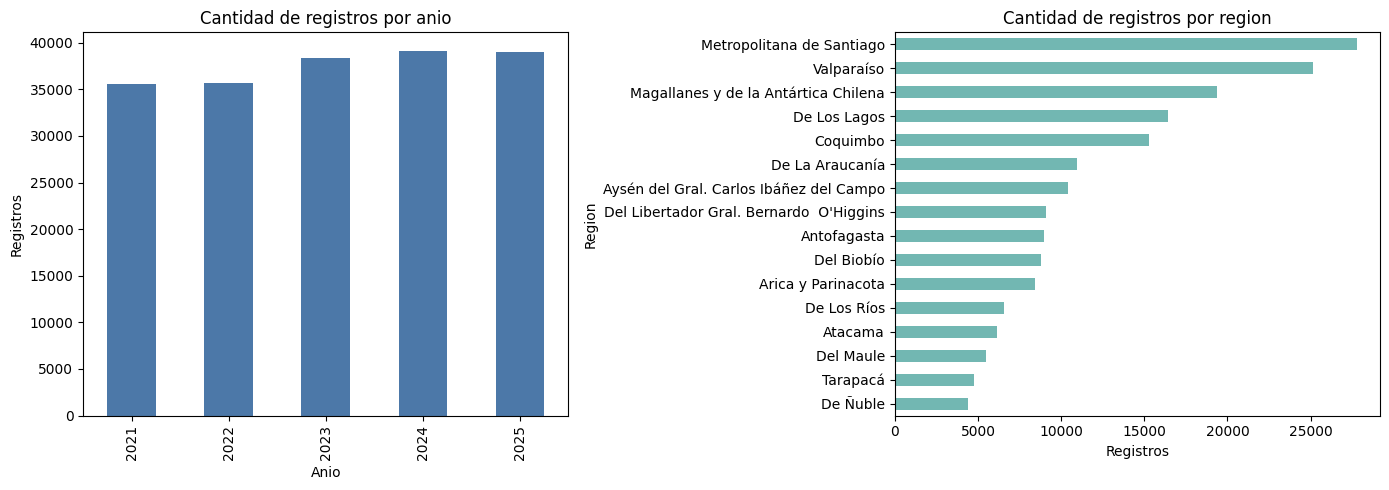

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['anio'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Cantidad de registros por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Registros')

registros_region = df.groupby('nombre_region')['codigo_estacion'].size().sort_values()
registros_region.plot(kind='barh', ax=axes[1], color='#72b7b2')
axes[1].set_title('Cantidad de registros por region')
axes[1].set_xlabel('Registros')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis de cobertura:**

El dataset cubre varios anios y todas las regiones del pais, lo que permite comparar comportamientos territoriales y temporales. Sin embargo, la cantidad de registros no es igual para todas las regiones ni estaciones, por lo que en analisis posteriores conviene usar promedios, porcentajes o tasas cuando se comparen territorios con distinta cantidad de observaciones.


## 2.2 Identificar Nulos

La deteccion de nulos es clave porque un nulo puede ser **ausencia de medicion, falla de estacion o dia sin dato**. **Principio del proyecto:** un nulo en precipitacion NO se asume como 0 (eso inventaria dias secos y sesgaria el analisis).

Los nulos se concentran en `agua_caida` (~9%) y en las temperaturas (`temp_max`, `temp_min`, `temp_media`, ~11-12%); las variables territoriales quedan completas tras la carga controlada. Aqui se **cuantifican**; su **tratamiento** se define en 2.4.2 (imputacion por mediana de la estacion) y, para el target de regresion, excluyendo filas sin medicion.

In [13]:
nulos = df.isna().sum().to_frame('nulos')
nulos['porcentaje'] = (nulos['nulos'] / len(df) * 100).round(2)
nulos = nulos.sort_values('porcentaje', ascending=False)

display(nulos)


,nulos,porcentaje
temp_media,22713,12.09
temp_min,21965,11.69
temp_max,21047,11.20
agua_caida,17063,9.08
codigo_estacion,0,0.00
region,0,0.00
altura,0,0.00
latitud,0,0.00
dia,0,0.00
mes,0,0.00


**Analisis de nulos por variable:**

Los nulos se concentran en variables climaticas, especialmente temperaturas y precipitacion. Por eso el tratamiento posterior debe conservar trazabilidad y evitar imputaciones automaticas sin criterio territorial o estadistico.

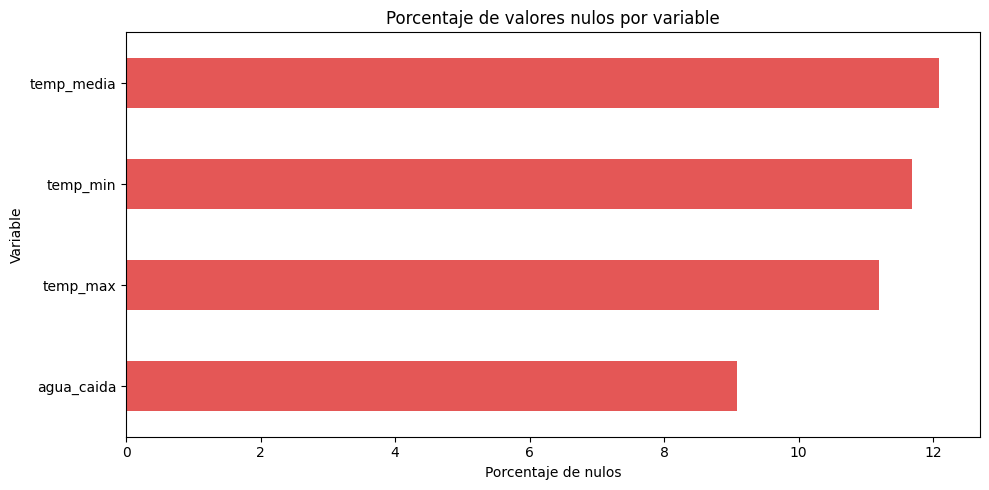

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
nulos[nulos['porcentaje'] > 0]['porcentaje'].sort_values().plot(kind='barh', ax=ax, color='#e45756')
ax.set_title('Porcentaje de valores nulos por variable')
ax.set_xlabel('Porcentaje de nulos')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()


**Analisis del grafico de nulos:**

El grafico permite priorizar las variables con mayor ausencia de datos. Al mostrar porcentajes, no solo cantidades absolutas, se facilita comparar columnas con el mismo universo de registros.

In [15]:
columnas_revision_nulos = ['agua_caida', 'temp_max', 'temp_min', 'temp_media']

nulos_climaticos_anio = df.groupby('anio')[columnas_revision_nulos].apply(
    lambda datos: datos.isna().mean() * 100
).T
nulos_climaticos_anio.columns = nulos_climaticos_anio.columns.astype(int)

display(nulos_climaticos_anio.round(2))


anio,2021,2022,2023,2024,2025
agua_caida,11.84,9.55,12.52,7.54,4.31
temp_max,14.95,13.11,14.36,8.98,5.17
temp_min,16.01,14.28,14.95,8.81,5.08
temp_media,16.56,15.05,15.30,9.00,5.26


**Analisis de nulos climaticos por anio:**

La tabla permite ver que la ausencia de datos no es uniforme en el tiempo. Esta revision justifica complementar el porcentaje general de nulos con una lectura temporal antes de decidir tratamientos.

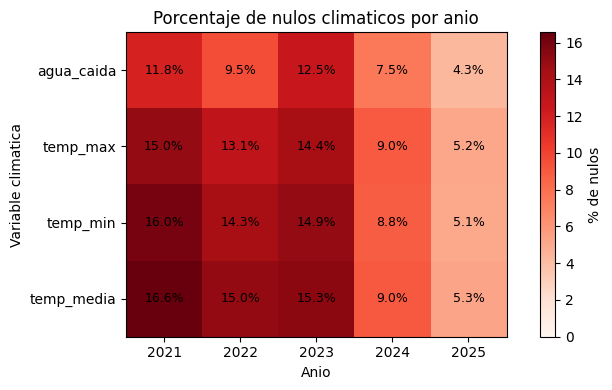

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(nulos_climaticos_anio, cmap='Reds', vmin=0)

ax.set_title('Porcentaje de nulos climaticos por anio')
ax.set_xlabel('Anio')
ax.set_ylabel('Variable climatica')
ax.set_xticks(range(len(nulos_climaticos_anio.columns)))
ax.set_xticklabels(nulos_climaticos_anio.columns)
ax.set_yticks(range(len(nulos_climaticos_anio.index)))
ax.set_yticklabels(nulos_climaticos_anio.index)

for fila in range(len(nulos_climaticos_anio.index)):
    for columna in range(len(nulos_climaticos_anio.columns)):
        valor = nulos_climaticos_anio.iloc[fila, columna]
        color_texto = 'white' if valor >= 20 else 'black'
        ax.text(columna, fila, f'{valor:.1f}%', ha='center', va='center', color=color_texto, fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='% de nulos')
plt.tight_layout()
plt.show()


**Analisis de nulos:**

Los nulos se concentran principalmente en variables climaticas: `agua_caida`, `temp_max`, `temp_min` y `temp_media`. El heatmap por anio permite revisar si la ausencia de datos se concentra en periodos especificos o si se mantiene relativamente estable. Esto confirma que el tratamiento de nulos debe ser diferenciado por variable. Para la fase de entendimiento se mantienen los nulos visibles; para modelamiento se evaluara imputacion o eliminacion controlada segun el objetivo del modelo.


## 2.3 Identificar Outliers

Los outliers se detectan con el metodo **IQR**: se marcan los valores fuera del rango `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`, apoyado en percentiles y boxplots. En datos meteorologicos un extremo puede ser un **evento real** (lluvia intensa del sur) o un **error de medicion** (p. ej. 3574 mm en un solo dia).

Por eso **no se eliminan automaticamente**: primero se detectan, se marcan con banderas y se contextualizan; su tratamiento se decide en 2.4.3.

In [17]:
variables_outliers = ['agua_caida', 'temp_max', 'temp_min', 'temp_media', 'altura']

def calcular_resumen_iqr(datos, columna):
    serie = datos[columna].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    outliers = ((serie < limite_inf) | (serie > limite_sup)).sum()

    return {
        'variable': columna,
        'q1': q1,
        'q3': q3,
        'iqr': iqr,
        'limite_inferior': limite_inf,
        'limite_superior': limite_sup,
        'outliers_iqr': outliers,
        'porcentaje_outliers': round(outliers / len(serie) * 100, 2)
    }


In [18]:
resumen_outliers = pd.DataFrame([
    calcular_resumen_iqr(df, columna)
    for columna in variables_outliers
])

display(resumen_outliers)


,variable,q1,q3,iqr,limite_inferior,limite_superior,outliers_iqr,porcentaje_outliers
0,agua_caida,0.0,0.100000,0.100000,-0.150000,0.250000,32994,19.32
1,temp_max,14.0,24.100000,10.100000,-1.150001,39.250001,740,0.44
2,temp_min,4.1,11.400000,7.300000,-6.850000,22.349999,1370,0.83
3,temp_media,9.2,16.700001,7.500001,-2.050002,27.950002,1373,0.83
4,altura,53.0,474.000000,421.000000,-578.500000,1105.500000,15523,8.26


**Analisis de tabla de outliers:**

El resumen cuantifica outliers por variable y permite separar el comportamiento de precipitacion del de temperatura. Esta diferencia es clave porque lluvia requiere un tratamiento especifico por su asimetria.

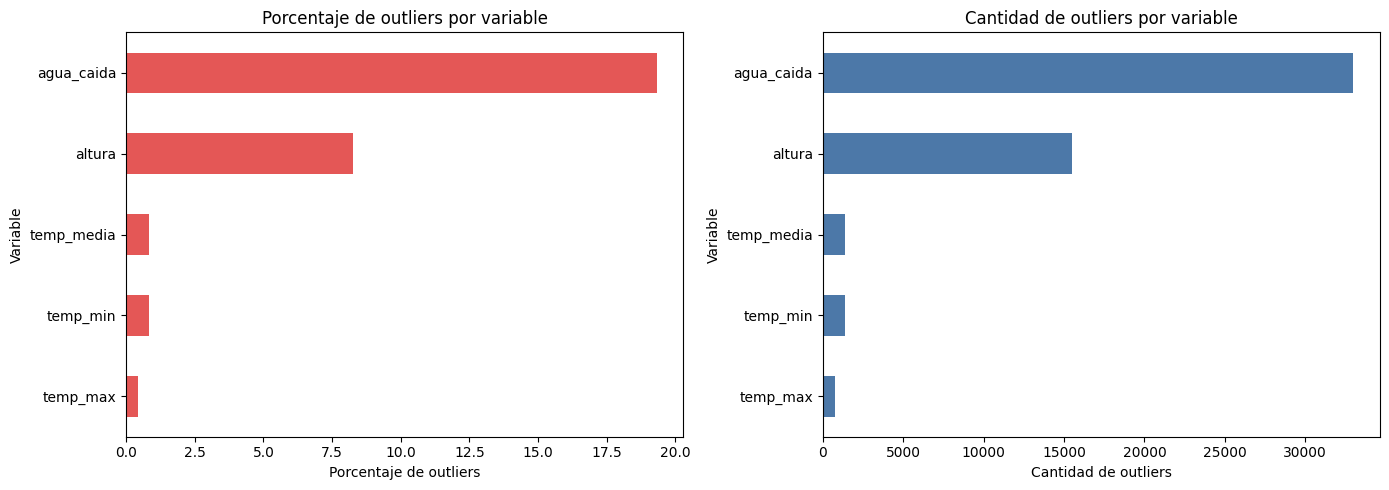

In [19]:
resumen_outliers_ordenado = resumen_outliers.sort_values('porcentaje_outliers')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='porcentaje_outliers',
    ax=axes[0], color='#e45756', legend=False
)
axes[0].set_title('Porcentaje de outliers por variable')
axes[0].set_xlabel('Porcentaje de outliers')
axes[0].set_ylabel('Variable')

resumen_outliers_ordenado.plot(
    kind='barh', x='variable', y='outliers_iqr',
    ax=axes[1], color='#4c78a8', legend=False
)
axes[1].set_title('Cantidad de outliers por variable')
axes[1].set_xlabel('Cantidad de outliers')
axes[1].set_ylabel('Variable')

plt.tight_layout()
plt.show()


**Analisis general de outliers:**

La precipitacion concentra la mayor cantidad de valores extremos, lo que es esperable por su distribucion asimetrica. Esto justifica tratar lluvia con percentil 99 y no con la misma regla usada para temperaturas.

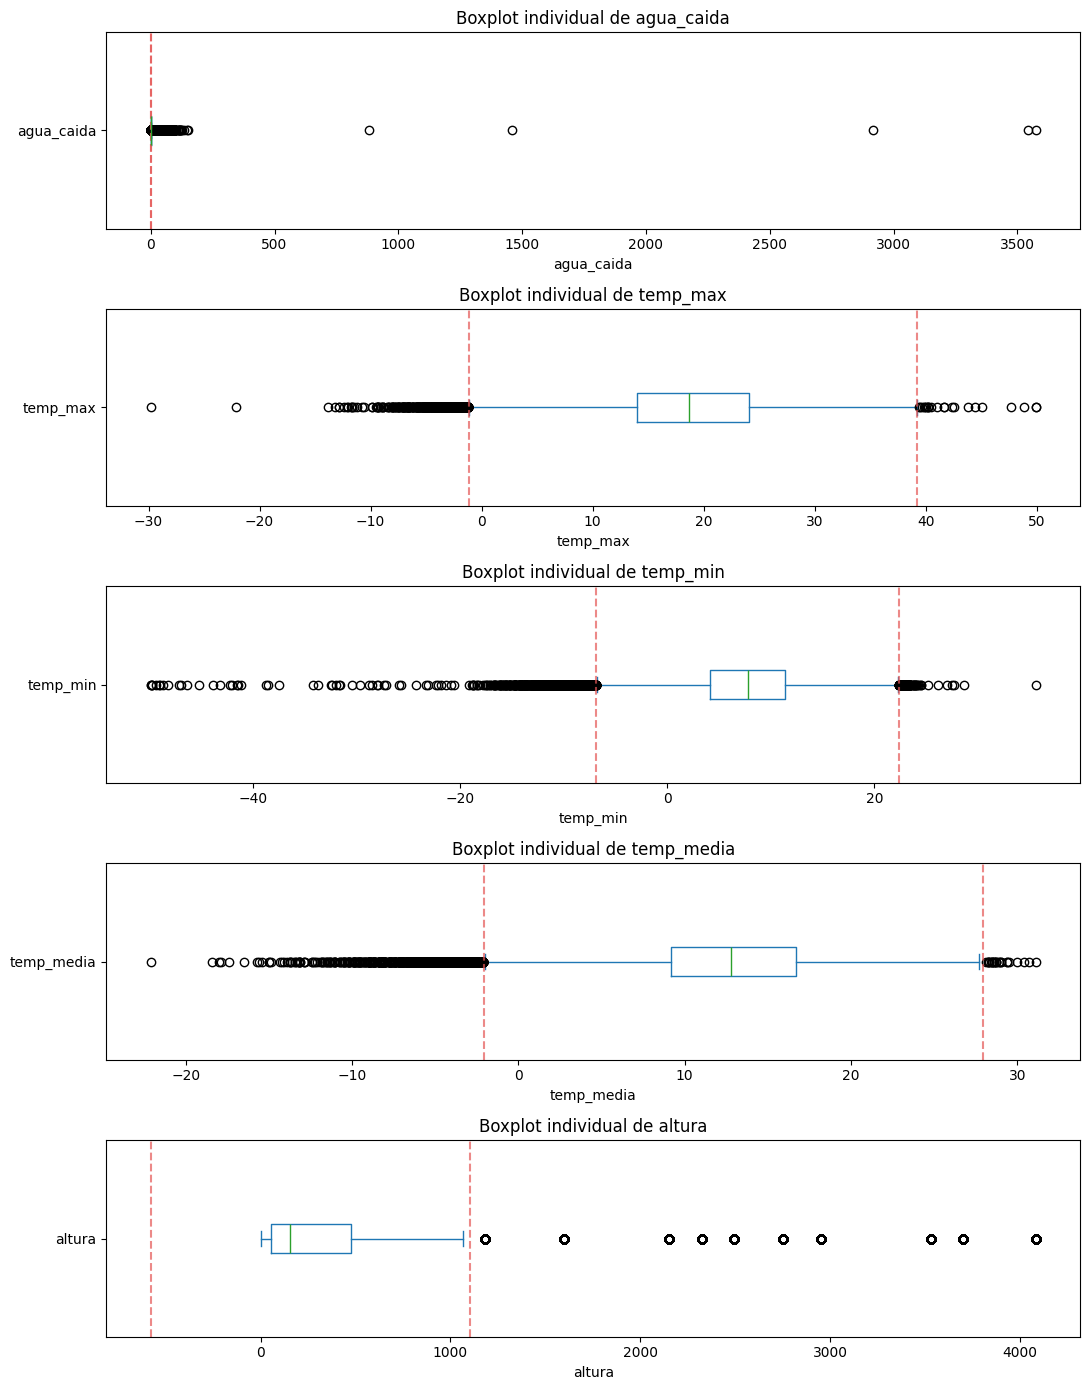

In [20]:
fig, axes = plt.subplots(len(variables_outliers), 1, figsize=(11, 14))

for ax, columna in zip(axes, variables_outliers):
    df[columna].dropna().plot(kind='box', vert=False, ax=ax)
    limites = resumen_outliers.set_index('variable').loc[columna]
    ax.axvline(limites['limite_inferior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.axvline(limites['limite_superior'], color='#e45756', linestyle='--', alpha=0.7)
    ax.set_title(f'Boxplot individual de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis grafico de outliers:**

El grafico general permite comparar rapidamente que variables concentran mas outliers bajo el criterio IQR. Los boxplots individuales complementan esa lectura, porque muestran la forma de la distribucion y la distancia de los valores extremos respecto del rango central. En particular, `agua_caida` requiere cautela: el metodo IQR detecta muchos valores porque la serie tiene muchos ceros y una cola derecha larga. Por eso, para tratamiento se usara un criterio mas conservador basado en extremos altos, no todos los puntos IQR.


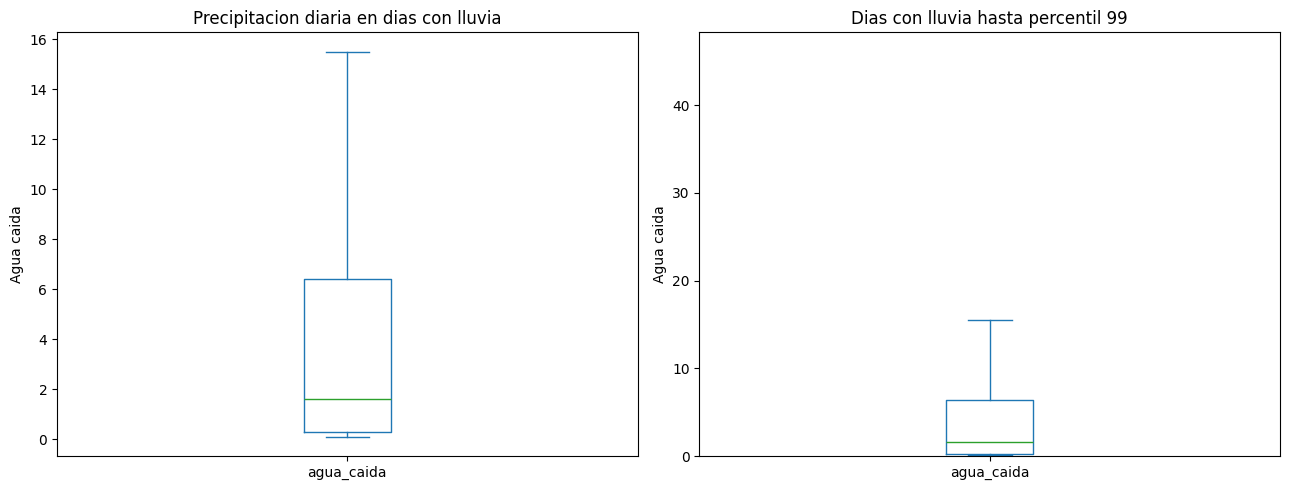

In [21]:
serie_agua = df['agua_caida'].dropna()
serie_agua_lluvia = serie_agua[serie_agua > 0]
limite_visual_agua = serie_agua_lluvia.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

serie_agua_lluvia.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Precipitacion diaria en dias con lluvia')
axes[0].set_ylabel('Agua caida')

serie_agua_lluvia.plot(kind='box', ax=axes[1], showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_ylabel('Agua caida')
axes[1].set_ylim(0, limite_visual_agua)

plt.tight_layout()
plt.show()


**Analisis de precipitacion en dias con lluvia:**

Al excluir dias con 0 mm, el boxplot muestra mejor la dispersion real de los eventos de lluvia. La vista acotada al percentil 99 mantiene escala normal y evita que pocos extremos oculten el comportamiento central.

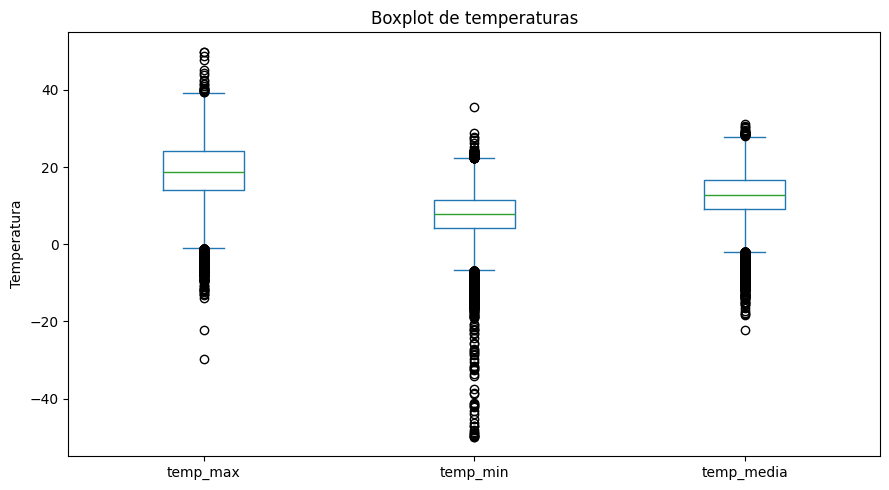

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
df[['temp_max', 'temp_min', 'temp_media']].plot(kind='box', ax=ax)
ax.set_title('Boxplot de temperaturas')
ax.set_ylabel('Temperatura')
plt.tight_layout()
plt.show()


**Analisis de temperaturas:**

Los boxplots de temperatura muestran dispersion mas estable que la precipitacion, aunque existen valores extremos. Estos extremos deben revisarse con cuidado porque pueden representar condiciones reales o errores de registro.

In [23]:
top_precipitaciones = df.sort_values('agua_caida', ascending=False).head(10)[[
    'fecha', 'codigo_estacion', 'nombre_estacion', 'nombre_region',
    'zona_geografica', 'agua_caida', 'temp_media', 'altura'
]]

display(top_precipitaciones)


,fecha,codigo_estacion,nombre_estacion,nombre_region,zona_geografica,agua_caida,temp_media,altura
75680,2025-12-08,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,3574.300049,21.400000,876
133239,2025-12-07,380082,Isla Mocha Ad.,Del Biobío,Litoral,3541.500000,16.500000,6
75679,2025-12-07,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,2917.399902,19.000000,876
133240,2025-12-09,380082,Isla Mocha Ad.,Del Biobío,Litoral,1459.900024,16.400000,6
75681,2025-12-09,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,880.099976,21.299999,876
97400,2023-08-21,340031,"General Freire, Curicó Ad.",Del Maule,Valle,150.199997,13.400000,229
74780,2023-06-22,330075,Río Clarillo,Metropolitana de Santiago,PreCordillera,145.199997,11.000000,876
123155,2022-04-28,380018,Lonquimay,De La Araucanía,PreCordillera,136.399994,NaN,912
138886,2021-05-31,390043,Corral ESSAL,De Los Ríos,Litoral,126.800003,13.900000,24
102878,2023-08-21,340066,Nilahue - La Quebrada,Del Libertador Gral. Bernardo O'Higgins,Secano Interior,121.300003,NaN,81


**Analisis de outliers:**

La variable `agua_caida` es altamente asimetrica: muchos dias tienen precipitacion cero o baja, mientras que pocos registros concentran valores muy altos. Por eso se revisa la distribucion en escala normal con una vista completa y una vista acotada al percentil 99. Los valores mas altos deben ser tratados con especial cuidado, ya que pueden representar eventos climaticos excepcionales o posibles errores de registro.


## 2.4 Transformaciones

En esta fase se realizan transformaciones iniciales orientadas al entendimiento de datos. No se aplicara aun escalamiento ni preparacion definitiva para modelos, porque eso corresponde a la Fase 3. Aqui se verifica la limpieza inicial de textos, se preparan codificaciones simples para analisis y se definen criterios de tratamiento para nulos y outliers.


### 2.4.1 Codificacion inicial a numericos

Las variables **categoricas** no entran directamente en modelos matematicos, por lo que se **codifican a numero**. En esta etapa exploratoria se crean codigos para `region`, `zona_geografica` y `macrozona` (con `.cat.codes`), utiles para la matriz de correlacion.

La **macrozona** agrupa las regiones en grandes areas climaticas (Norte Grande, Norte Chico, Zona Central, Zona Sur, Zona Austral), mas interpretable que la region individual. **Nota:** el encoding definitivo para modelar es **one-hot** (Fase 3.4), que evita imponer un orden artificial entre categorias.

In [24]:
df_eda = df.copy()

macrozonas_orden = ['Norte Grande', 'Norte Chico', 'Zona Central', 'Zona Sur', 'Zona Austral']

def asignar_macrozona(region):
    if region in [15, 1, 2]:
        return 'Norte Grande'
    if region in [3, 4]:
        return 'Norte Chico'
    if region in [5, 13, 6, 7, 16, 8]:
        return 'Zona Central'
    if region in [9, 14, 10]:
        return 'Zona Sur'
    if region in [11, 12]:
        return 'Zona Austral'
    return 'Sin clasificar'

df_eda['macrozona'] = df_eda['region'].apply(asignar_macrozona)
df_eda['macrozona'] = pd.Categorical(df_eda['macrozona'], categories=macrozonas_orden, ordered=True)


In [25]:
df_eda['region_cod'] = df_eda['nombre_region'].astype('category').cat.codes
df_eda['zona_geografica_cod'] = df_eda['zona_geografica'].astype('category').cat.codes
df_eda['macrozona_cod'] = df_eda['macrozona'].cat.codes

columnas_codificacion = [
    'region', 'nombre_region', 'macrozona', 'region_cod',
    'zona_geografica', 'zona_geografica_cod', 'macrozona_cod'
]
codificacion = df_eda[columnas_codificacion].drop_duplicates()

display(codificacion.sort_values(['macrozona', 'region', 'zona_geografica']).head(15))


,region,nombre_region,macrozona,region_cod,zona_geografica,zona_geografica_cod,macrozona_cod
8400,1,Tarapacá,Norte Grande,14,Cordillera,0,0
9496,1,Tarapacá,Norte Grande,14,Litoral,1,0
16796,2,Antofagasta,Norte Grande,0,Cordillera,0,0
14974,2,Antofagasta,Norte Grande,0,Litoral,1,0
13148,2,Antofagasta,Norte Grande,0,PreCordillera,2,0
0,15,Arica y Parinacota,Norte Grande,1,Cordillera,0,0
1096,15,Arica y Parinacota,Norte Grande,1,Litoral,1,0
2922,15,Arica y Parinacota,Norte Grande,1,PreCordillera,2,0
25053,3,Atacama,Norte Chico,2,Secano Costero,3,1
22131,3,Atacama,Norte Chico,2,Valle,5,1


**Analisis de codificacion categorica:**

La codificacion transforma regiones, zonas y macrozonas en variables numericas sin perder la categoria original. Esto permite usar las variables territoriales en correlaciones y modelos posteriores.

### 2.4.2 Tratamiento de Nulos

El tratamiento definitivo de nulos se aplica segun el objetivo del modelo. Estrategia por variable:

| Variable | Estrategia |
|---|---|
| `agua_caida` | Si falta la medicion del dia, la fila se excluye del set supervisado (no se inventa el target con 0). |
| `temp_max`, `temp_min`, `temp_media` | Imputacion con la mediana de la propia estacion; respaldo con la mediana global. |
| Categoricas | Moda solo si aparecen nulos; las territoriales quedan completas tras corregir la carga. |

In [26]:
# Imputacion de temperatura por mediana de cada estacion (respeta el regimen climatico local)
columnas_temp = ['temp_max', 'temp_min', 'temp_media']
for col in columnas_temp:
    df_eda[col] = df_eda.groupby('codigo_estacion')[col].transform(lambda s: s.fillna(s.median()))
    df_eda[col] = df_eda[col].fillna(df_eda[col].median())

print('Nulos restantes tras imputar temperatura:')
print(df_eda[columnas_temp].isna().sum())

Nulos restantes tras imputar temperatura:
temp_max      0
temp_min      0
temp_media    0
dtype: int64


**Analisis de estrategia de nulos:**

La estrategia separa variables climaticas, territoriales y temporales. Esta distincion es importante porque no todos los nulos tienen el mismo significado ni deben recibir el mismo tratamiento.

### 2.4.3 Tratamiento de Outliers

Se aplican **dos niveles**:

1. **Banderas IQR** para variables climaticas: marcan los extremos **sin eliminarlos**, conservando trazabilidad.
2. **Umbral fisico para `agua_caida`**: lluvias diarias sobre **150 mm** se consideran errores de medicion (valores como 3574 mm son imposibles) y se reemplazan por la **mediana de los dias con lluvia** -no por la mediana global, que es 0 y borraria el evento-, generando `agua_caida_tratada`.

La variable **original se conserva** para auditoria. A diferencia de un recorte por percentil, el umbral fisico **preserva los eventos intensos reales** (50-150 mm) del sur de Chile.

In [27]:
def marcar_outliers_iqr(datos, columna):
    serie = datos[columna]
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    return (serie < limite_inf) | (serie > limite_sup)


In [28]:
df_eda['outlier_agua_caida_iqr'] = marcar_outliers_iqr(df_eda, 'agua_caida')
df_eda['outlier_temp_media_iqr'] = marcar_outliers_iqr(df_eda, 'temp_media')

resumen_banderas_outliers = df_eda[
    ['outlier_agua_caida_iqr', 'outlier_temp_media_iqr']
].sum().to_frame('cantidad')
resumen_banderas_outliers['porcentaje'] = (
    resumen_banderas_outliers['cantidad'] / len(df_eda) * 100
).round(2)

display(resumen_banderas_outliers)


,cantidad,porcentaje
outlier_agua_caida_iqr,32994,17.56
outlier_temp_media_iqr,1993,1.06


**Analisis de banderas de outliers:**

Las banderas permiten marcar registros extremos sin eliminarlos. Esta estrategia conserva trazabilidad y facilita comparar el dato original con variables tratadas.

In [29]:
# Umbral fisico: lluvias diarias sobre 150mm en este dataset corresponden a errores de medicion
# (valores como 3574mm son imposibles). Solo afecta a 6 registros.
umbral_extremo_lluvia = 150
mediana_lluvia_no_extrema = df_eda.loc[df_eda['agua_caida'] > 0, 'agua_caida'].median()

In [30]:
df_eda['outlier_extremo_agua_caida'] = df_eda['agua_caida'] > umbral_extremo_lluvia

# Se imputa el extremo por la mediana de los dias con lluvia (no por la mediana global,
# que es 0 y convertiria una lluvia en un dia seco). Conserva la variable original para auditoria.
df_eda['agua_caida_tratada'] = df_eda['agua_caida'].where(
    df_eda['agua_caida'] <= umbral_extremo_lluvia,
    mediana_lluvia_no_extrema
)

**Analisis del tratamiento de extremos de lluvia:**

El resumen documenta el umbral usado, el valor de reemplazo y cuantas observaciones fueron tratadas. Esto hace auditable la creacion de `agua_caida_tratada` y evita modificar la variable original.

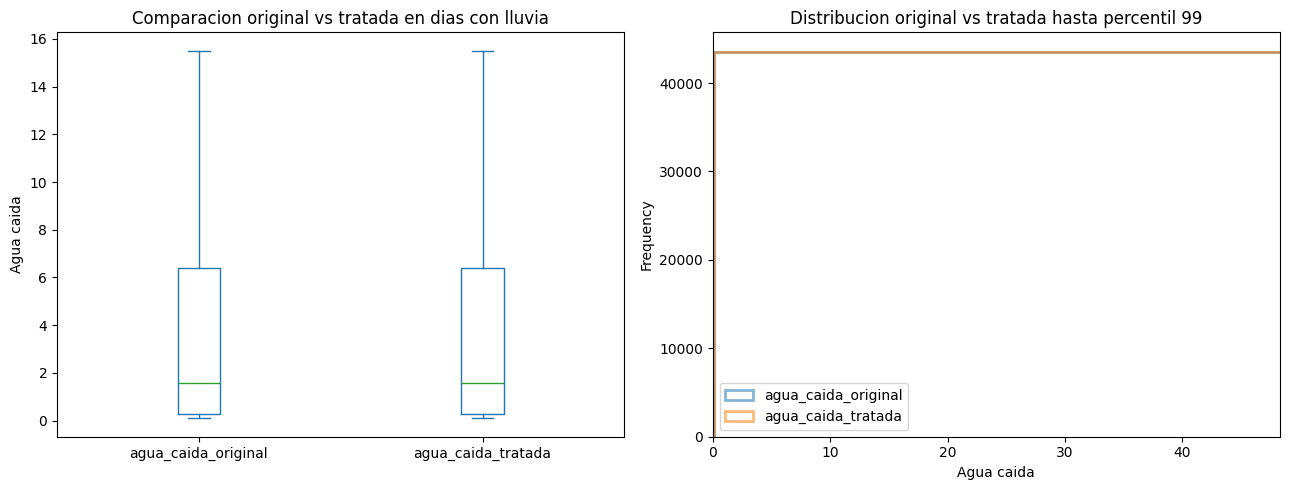

In [31]:
comparacion_lluvia = pd.DataFrame({
    'agua_caida_original': df_eda['agua_caida'],
    'agua_caida_tratada': df_eda['agua_caida_tratada']
})

comparacion_lluvia_positiva = comparacion_lluvia[comparacion_lluvia['agua_caida_original'] > 0]
limite_visual_comparacion = comparacion_lluvia_positiva.quantile(0.99).max()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

comparacion_lluvia_positiva.plot(kind='box', ax=axes[0], showfliers=False)
axes[0].set_title('Comparacion original vs tratada en dias con lluvia')
axes[0].set_ylabel('Agua caida')

comparacion_lluvia_positiva.plot(kind='hist', bins=50, alpha=0.55, histtype='step', linewidth=2, ax=axes[1])
axes[1].set_title('Distribucion original vs tratada hasta percentil 99')
axes[1].set_xlabel('Agua caida')
axes[1].set_xlim(0, limite_visual_comparacion)

plt.tight_layout()
plt.show()


**Analisis del tratamiento de lluvia:**

El tratamiento reemplaza unicamente los valores superiores a 150mm de `agua_caida` (solo 6 registros, con valores como 3574mm que son errores de medicion), usando la mediana de los dias con lluvia. Se conserva la variable original `agua_caida` para auditoria. No se usa la mediana general porque en lluvia diaria suele ser 0, lo que convertiria un evento de lluvia en un dia seco. A diferencia de un recorte por percentil, este umbral fisico preserva los eventos de lluvia intensa reales (50-150mm) del sur de Chile.

**Analisis de transformaciones iniciales:**

Las transformaciones realizadas permiten continuar el analisis sin perder trazabilidad. La correccion de texto mejora la interpretacion de regiones y estaciones en graficos, y la macrozona permite resumir regiones en grupos territoriales mas interpretables. Los codigos numericos permiten estudiar correlaciones exploratorias, pero no reemplazan una preparacion formal para modelamiento. Los outliers quedan marcados y, para lluvia extrema, se crea una variable tratada que reduce distorsion sin perder el registro original.


## 2.5 Analisis estadisticos basicos

Se calculan estadisticos descriptivos para comprender rangos, dispersion y comportamiento general de las variables numericas. Desde esta seccion, los resumenes de precipitacion usan `agua_caida_tratada` para evitar que pocos extremos altos dominen las medidas. Luego se agregan resultados por region, macrozona y zona geografica para obtener una lectura territorial en distintos niveles de detalle.


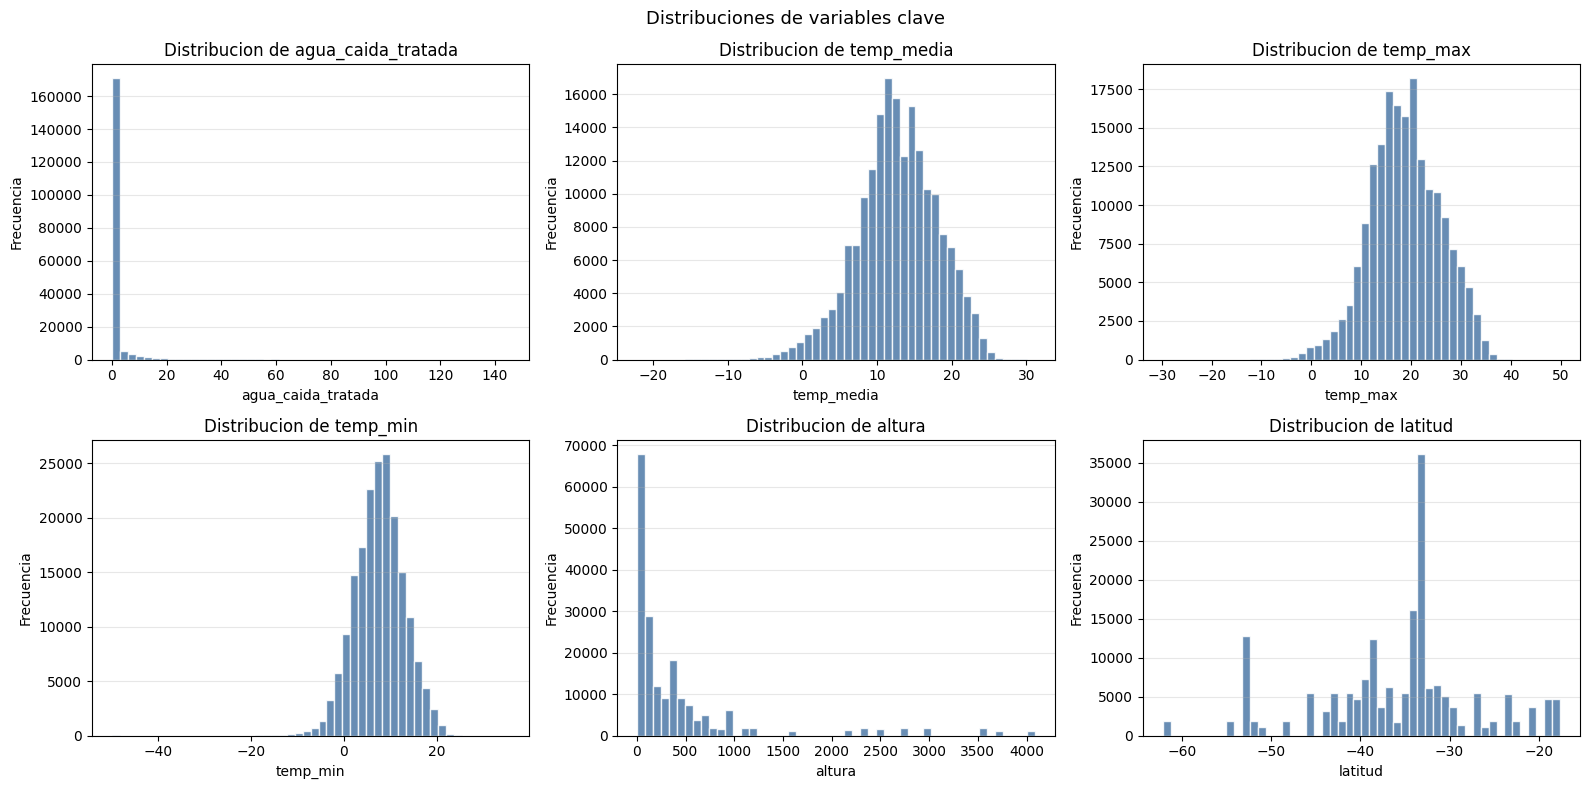

In [32]:
variables_dist = ['agua_caida_tratada', 'temp_media', 'temp_max', 'temp_min', 'altura', 'latitud']
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, var in zip(axes.ravel(), variables_dist):
    datos = df_eda[var].dropna()
    ax.hist(datos, bins=50, color='#4e79a7', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribucion de {var}')
    ax.set_xlabel(var); ax.set_ylabel('Frecuencia')
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribuciones de variables clave', fontsize=13)
plt.tight_layout()
plt.show()

**Analisis de distribuciones:**

La precipitacion tratada es fuertemente asimetrica con masa en cero (mayoria de dias secos), lo que justifica tratarla aparte de las temperaturas, que son aproximadamente simetricas. La isoterma cero y la altura muestran distribuciones multimodales que reflejan la diversidad geografica de las estaciones.

In [33]:
variables_numericas_base = ['altura', 'latitud', 'longitud', 'agua_caida', 'agua_caida_tratada', 'temp_max', 'temp_min', 'temp_media']
estadisticos_base = df_eda[variables_numericas_base].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]).T

display(estadisticos_base)


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
altura,187876.0,441.945948,741.219754,5.000000,6.00000,11.00000,53.00000,156.000000,474.000000,2326.000000,3700.000000,4084.000000
latitud,187876.0,-35.850940,8.856507,-62.191940,-54.93167,-53.13000,-40.08361,-33.728330,-32.222500,-19.276940,-18.200000,-17.595000
longitud,187876.0,-71.691117,4.176134,-109.432500,-78.83305,-73.73528,-72.34389,-71.186670,-70.682780,-69.294720,-67.615560,-58.979720
agua_caida,170813.0,1.494435,15.673269,0.000000,0.00000,0.00000,0.00000,0.000000,0.100000,8.600000,27.799999,3574.300049
agua_caida_tratada,187876.0,1.437416,5.281025,0.000000,0.00000,0.00000,0.00000,0.000000,0.400000,7.800000,26.600000,145.199997
temp_max,187876.0,18.862424,7.045586,-29.799999,1.10000,7.40000,14.20000,18.799999,23.799999,30.700001,33.799999,49.900002
temp_min,187876.0,7.645924,5.308648,-49.900002,-5.40000,-1.10000,4.30000,7.800000,11.100000,16.400000,19.500000,35.599998
temp_media,187876.0,12.711392,5.364868,-22.100000,-1.30000,3.50000,9.40000,12.700000,16.400000,21.400000,23.700001,31.100000


**Analisis estadistico base:**

Los estadisticos muestran que la precipitacion tiene alta dispersion y muchos valores bajos, mientras que las temperaturas presentan un comportamiento mas continuo. Esto anticipa que los modelos de lluvia seran mas dificiles que los de temperatura.

In [34]:
# Helper reutilizable: resumen territorial de lluvia y temperatura sobre el df principal (df_eda),
# sin crear copias intermedias. Se usa para region, zona geografica y macrozona.
def resumen_territorial(grupo, observed=False):
    return df_eda.groupby(grupo, observed=observed).agg(
        registros=('codigo_estacion', 'size'),
        estaciones=('codigo_estacion', 'nunique'),
        agua_promedio=('agua_caida_tratada', 'mean'),
        agua_total=('agua_caida_tratada', 'sum'),
        temp_media_promedio=('temp_media', 'mean')).round(3)

estadisticos_region = resumen_territorial('nombre_region').sort_values('agua_promedio', ascending=False)
display(estadisticos_region)

,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
nombre_region,,,,,
De Los Ríos,6569,4,3.766,24739.2,11.302
Aysén del Gral. Carlos Ibáñez del Campo,10437,6,3.462,36135.1,8.881
De Los Lagos,16434,9,3.386,55650.0,10.555
De La Araucanía,10956,6,2.374,26004.2,11.260
Del Biobío,8764,5,2.341,20515.3,12.854
De Ñuble,4383,3,2.235,9796.0,13.013
Del Maule,5456,3,1.521,8300.6,14.216
Magallanes y de la Antártica Chilena,19347,11,1.228,23749.1,5.793
Valparaíso,25116,15,0.958,24060.0,13.842


**Analisis por region:**

El resumen regional evidencia diferencias climaticas importantes entre territorios. Estas diferencias respaldan el uso de variables geograficas como predictoras y la necesidad de analizar resultados por zona.

In [35]:
estadisticos_zona = resumen_territorial('zona_geografica').sort_values('agua_promedio', ascending=False)
display(estadisticos_zona)

,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
zona_geografica,,,,,
Litoral,64838,36,1.768,114639.4,12.228
Valle,86617,51,1.486,128715.9,12.944
Secano Interior,2557,2,1.116,2853.2,12.979
PreCordillera,19060,11,0.939,17899.7,14.084
Cordillera,7527,5,0.493,3712.2,9.370
Secano Costero,7277,4,0.307,2235.5,14.017


**Analisis por zona geografica:**

La agrupacion por zona reduce ruido respecto de la region individual y permite observar patrones climaticos mas interpretables. Esto ayuda a conectar el analisis con decisiones territoriales.

In [36]:
estadisticos_macrozona = resumen_territorial('macrozona', observed=True)
display(estadisticos_macrozona)

,registros,estaciones,agua_promedio,agua_total,temp_media_promedio
macrozona,,,,,
Norte Grande,22131,13,0.221,4901.4,16.185
Norte Chico,21410,13,0.340,7284.9,15.468
Zona Central,80592,47,1.136,91592.0,13.934
Zona Sur,33959,19,3.133,106393.4,10.927
Zona Austral,29784,17,2.011,59884.2,6.875


**Analisis por macrozona:**

La macrozona resume el comportamiento territorial en categorias amplias. Esta variable es util para graficos, correlaciones, modelos y para explicar resultados de forma clara frente a la rubrica.

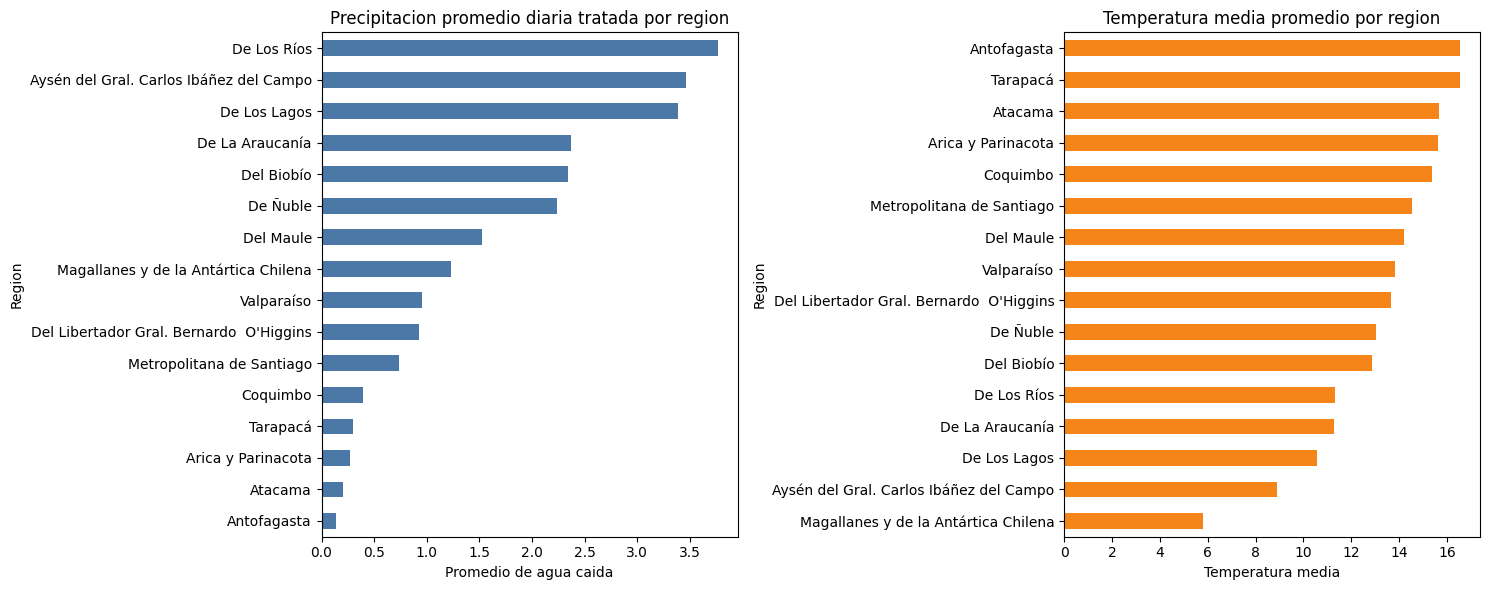

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

estadisticos_region['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por region')
axes[0].set_xlabel('Promedio de agua caida')
axes[0].set_ylabel('Region')

estadisticos_region['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por region')
axes[1].set_xlabel('Temperatura media')
axes[1].set_ylabel('Region')

plt.tight_layout()
plt.show()


**Analisis grafico por region:**

La comparacion visual confirma que precipitacion y temperatura no se distribuyen igual entre regiones. Esto indica que la ubicacion geografica tiene valor explicativo para el modelamiento.

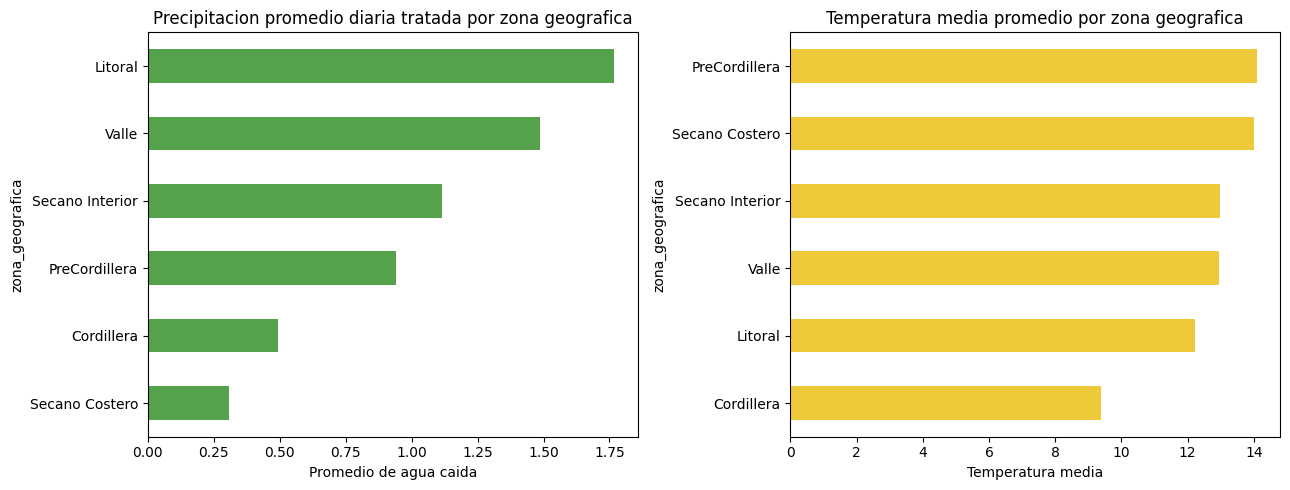

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_zona['agua_promedio'].sort_values().plot(kind='barh', ax=axes[0], color='#54a24b')
axes[0].set_title('Precipitacion promedio diaria tratada por zona geografica')
axes[0].set_xlabel('Promedio de agua caida')

estadisticos_zona['temp_media_promedio'].sort_values().plot(kind='barh', ax=axes[1], color='#eeca3b')
axes[1].set_title('Temperatura media promedio por zona geografica')
axes[1].set_xlabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis grafico por zona:**

Las zonas permiten distinguir gradientes climaticos sin saturar el grafico con demasiadas categorias. Esta lectura territorial fortalece las hipotesis sobre macrozonas y estacionalidad.

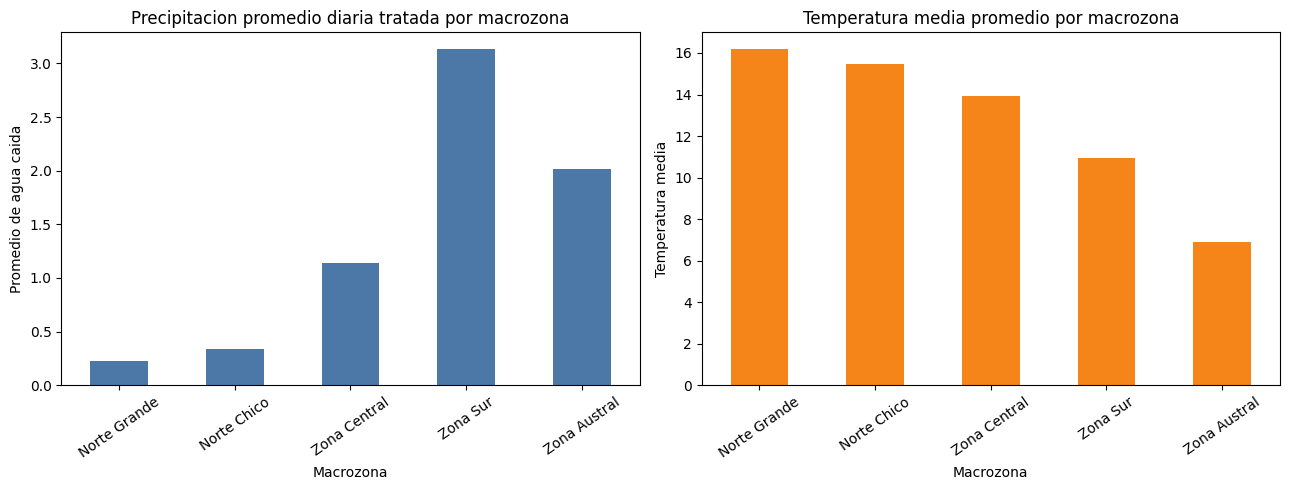

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

estadisticos_macrozona['agua_promedio'].plot(kind='bar', ax=axes[0], color='#4c78a8')
axes[0].set_title('Precipitacion promedio diaria tratada por macrozona')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Promedio de agua caida')
axes[0].tick_params(axis='x', rotation=35)

estadisticos_macrozona['temp_media_promedio'].plot(kind='bar', ax=axes[1], color='#f58518')
axes[1].set_title('Temperatura media promedio por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')
axes[1].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis grafico por macrozona:**

La macrozona muestra diferencias claras en precipitacion y temperatura promedio. Esta evidencia justifica incluir `macrozona_cod` en los modelos como variable predictora codificada.

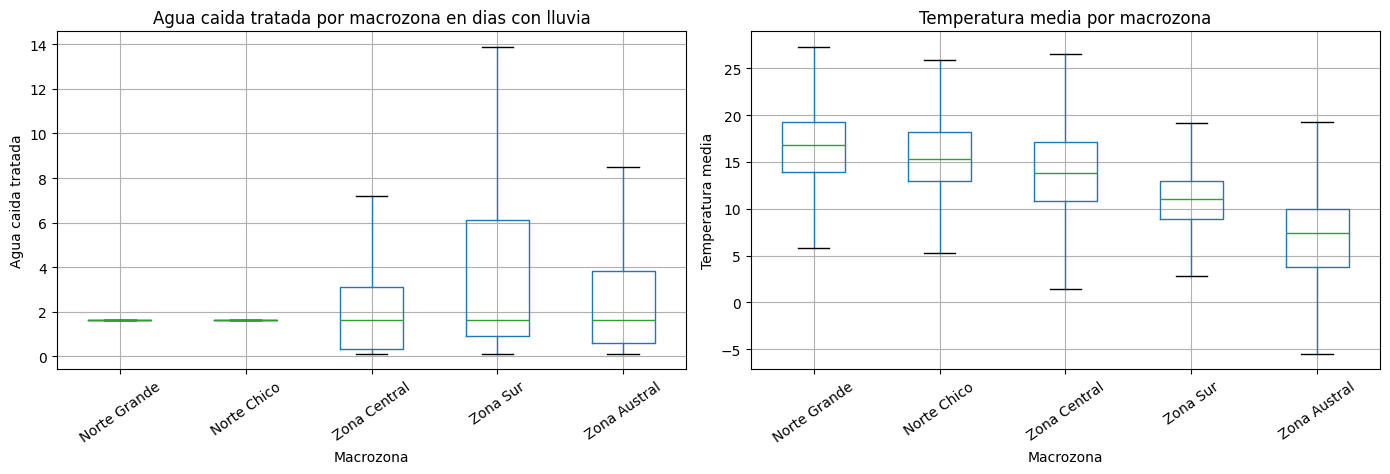

In [40]:
macrozona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

macrozona_lluvia.boxplot(column='agua_caida_tratada', by='macrozona', ax=axes[0], rot=35, showfliers=False)
axes[0].set_title('Agua caida tratada por macrozona en dias con lluvia')
axes[0].set_xlabel('Macrozona')
axes[0].set_ylabel('Agua caida tratada')

df_eda.boxplot(column='temp_media', by='macrozona', ax=axes[1], rot=35, showfliers=False)
axes[1].set_title('Temperatura media por macrozona')
axes[1].set_xlabel('Macrozona')
axes[1].set_ylabel('Temperatura media')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por macrozona:**

La macrozona permite leer los datos de manera mas clara que una comparacion con muchas regiones. Esta agrupacion ayuda a distinguir patrones climaticos amplios entre norte, centro, sur y extremo austral, manteniendo una interpretacion territorial comprensible para el analisis de negocio.


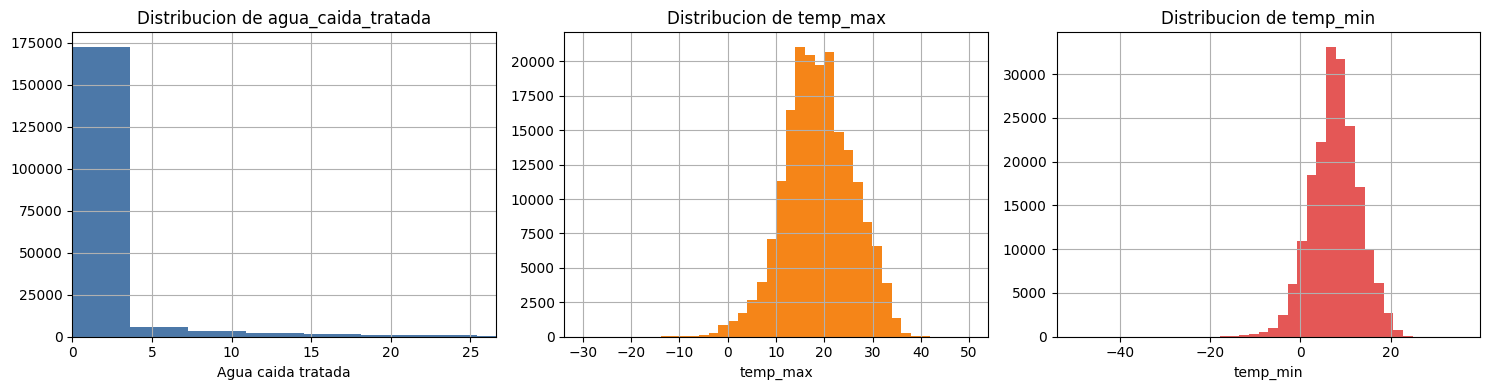

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

serie_lluvia_tratada = df_eda['agua_caida_tratada'].dropna()
serie_lluvia_tratada.hist(bins=40, ax=axes[0], color='#4c78a8')
axes[0].set_title('Distribucion de agua_caida_tratada')
axes[0].set_xlabel('Agua caida tratada')
axes[0].set_xlim(0, serie_lluvia_tratada.quantile(0.99))

for columna, ax, color in zip(['temp_max', 'temp_min'], axes[1:], ['#f58518', '#e45756']):
    df_eda[columna].dropna().hist(bins=40, ax=ax, color=color)
    ax.set_title(f'Distribucion de {columna}')
    ax.set_xlabel(columna)

plt.tight_layout()
plt.show()


**Analisis estadistico:**

Los estadisticos y graficos muestran que la precipitacion, incluso tratada, no se distribuye de forma normal: predominan valores bajos y pocos eventos concentran montos altos. Las temperaturas presentan una distribucion mas continua y son mas adecuadas para analisis de correlacion directa. Las comparaciones por region, macrozona y zona permiten comenzar a validar hipotesis territoriales en distintos niveles de detalle.


## 2.6 Matriz de Correlacion

La matriz de correlacion permite analizar relaciones lineales entre variables numericas. No implica causalidad, pero ayuda a identificar variables que podrian aportar informacion en modelos predictivos.


In [42]:
def graficar_matriz_correlacion(correlacion, titulo, figsize=(8, 6), rotacion=45):
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)

    ax.set_xticks(range(len(correlacion.columns)))
    ax.set_yticks(range(len(correlacion.index)))
    ax.set_xticklabels(correlacion.columns, rotation=rotacion, ha='right')
    ax.set_yticklabels(correlacion.index)
    ax.set_title(titulo)

    for fila in range(len(correlacion.index)):
        for columna in range(len(correlacion.columns)):
            valor = correlacion.iloc[fila, columna]
            color_texto = 'white' if abs(valor) >= 0.60 else 'black'
            ax.text(columna, fila, f'{valor:.2f}', ha='center', va='center', fontsize=8, color=color_texto)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


In [43]:
columnas_correlacion_inicial = [
    'altura', 'latitud', 'longitud', 'mes', 'agua_caida_tratada',
    'temp_max', 'temp_min', 'temp_media'
]

corr_inicial = df_eda[columnas_correlacion_inicial].corr(numeric_only=True)
display(corr_inicial.round(3))


,altura,latitud,longitud,mes,agua_caida_tratada,temp_max,temp_min,temp_media
altura,1.000,0.393,0.182,-0.002,-0.070,0.073,-0.178,-0.040
latitud,0.393,1.000,-0.062,-0.002,-0.121,0.524,0.480,0.562
longitud,0.182,-0.062,1.000,-0.001,-0.071,-0.081,-0.226,-0.171
mes,-0.002,-0.002,-0.001,1.000,0.003,-0.124,-0.133,-0.140
agua_caida_tratada,-0.070,-0.121,-0.071,0.003,1.000,-0.198,-0.028,-0.132
temp_max,0.073,0.524,-0.081,-0.124,-0.198,1.000,0.569,0.895
temp_min,-0.178,0.480,-0.226,-0.133,-0.028,0.569,1.000,0.856
temp_media,-0.040,0.562,-0.171,-0.140,-0.132,0.895,0.856,1.000


**Analisis de matriz inicial:**

La matriz inicial muestra relaciones entre variables base antes de incorporar nuevas variables derivadas. Esta comparacion sirve como linea base para evaluar si las transformaciones agregan informacion.

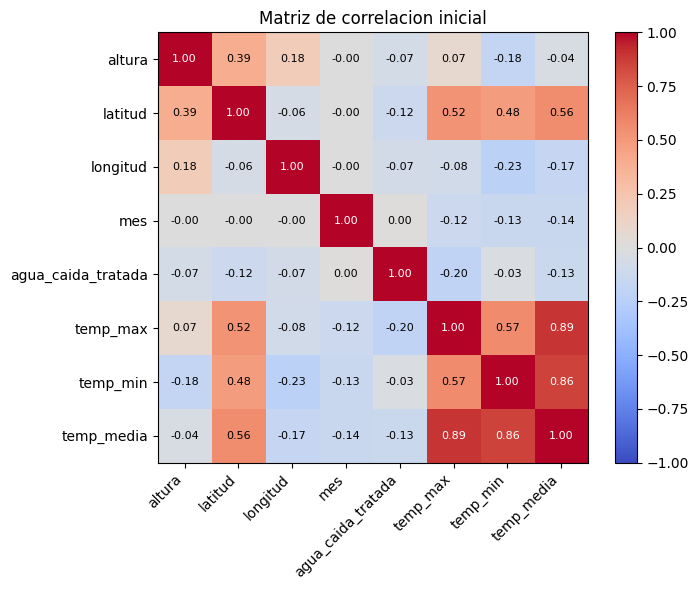

In [44]:
graficar_matriz_correlacion(
    corr_inicial,
    'Matriz de correlacion inicial',
    figsize=(8, 6),
    rotacion=45
)


**Analisis de correlacion inicial:**

Se espera observar una relacion fuerte entre las variables de temperatura, especialmente entre `temp_media`, `temp_max` y `temp_min`. Las variables geograficas como `latitud` y `altura` pueden mostrar relacion con temperatura, lo que es consistente con el comportamiento climatico esperado. La variable `agua_caida_tratada` puede presentar correlaciones mas debiles porque la lluvia diaria suele depender de patrones no lineales y eventos puntuales.


## 2.7 Patrones/comportamientos detectados

En esta seccion se revisan patrones temporales, geograficos y climaticos mediante graficos. Cada grafico responde a una pregunta concreta: como cambia la lluvia por mes, como cambia la temperatura, que zonas concentran mas precipitacion y como se relacionan ubicacion y clima.


In [45]:
mensual = df_eda.assign(
    periodo=df_eda['fecha'].dt.to_period('M').dt.to_timestamp()
).groupby(['anio', 'mes', 'periodo']).agg(
    agua_total=('agua_caida_tratada', 'sum'),
    agua_promedio=('agua_caida_tratada', 'mean'),
    temp_media=('temp_media', 'mean')
).reset_index()

anios_disponibles = sorted(mensual['anio'].unique())
meses = range(1, 13)

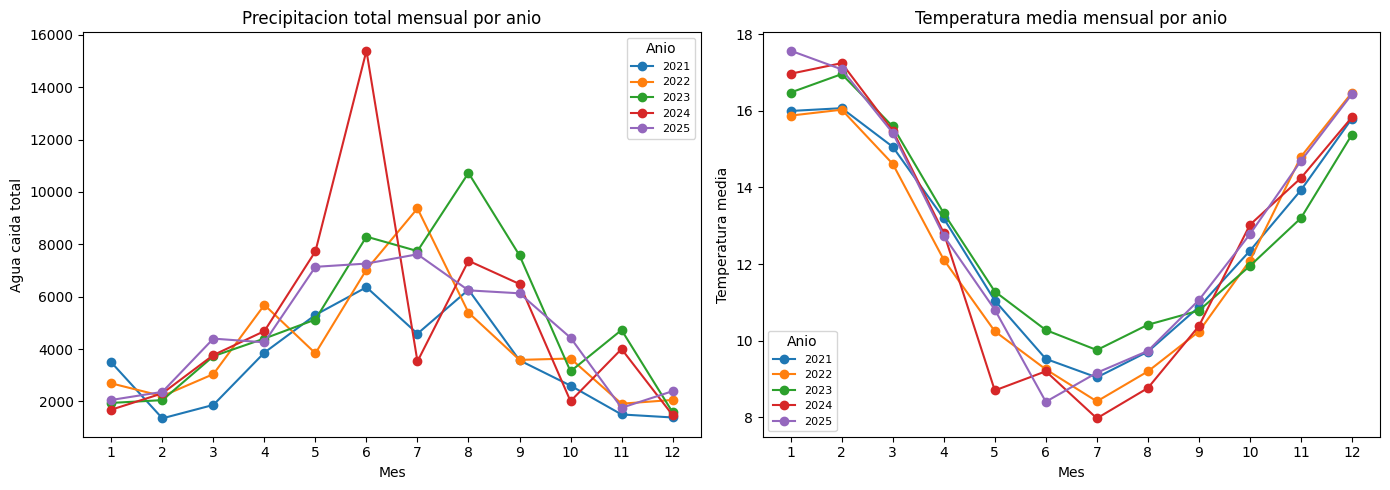

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

for anio in anios_disponibles:
    datos_anio = mensual[mensual['anio'] == anio]
    axes[0].plot(datos_anio['mes'], datos_anio['agua_total'], marker='o', label=str(anio))
    axes[1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', label=str(anio))

axes[0].set_title('Precipitacion total mensual por anio')
axes[0].set_xlabel('Mes')
axes[0].set_ylabel('Agua caida total')

axes[1].set_title('Temperatura media mensual por anio')
axes[1].set_xlabel('Mes')
axes[1].set_ylabel('Temperatura media')

for ax in axes:
    ax.set_xticks(meses)
    ax.legend(title='Anio', fontsize=8)

plt.tight_layout()
plt.show()

**Analisis mensual por anio:**

Separar las lineas por anio permite comparar si la estacionalidad se repite o cambia entre 2021, 2022, 2023, 2024 y 2025. Esta vista es mas trazable que un promedio general por mes, porque muestra diferencias interanuales y evita ocultar anios con comportamientos particulares.

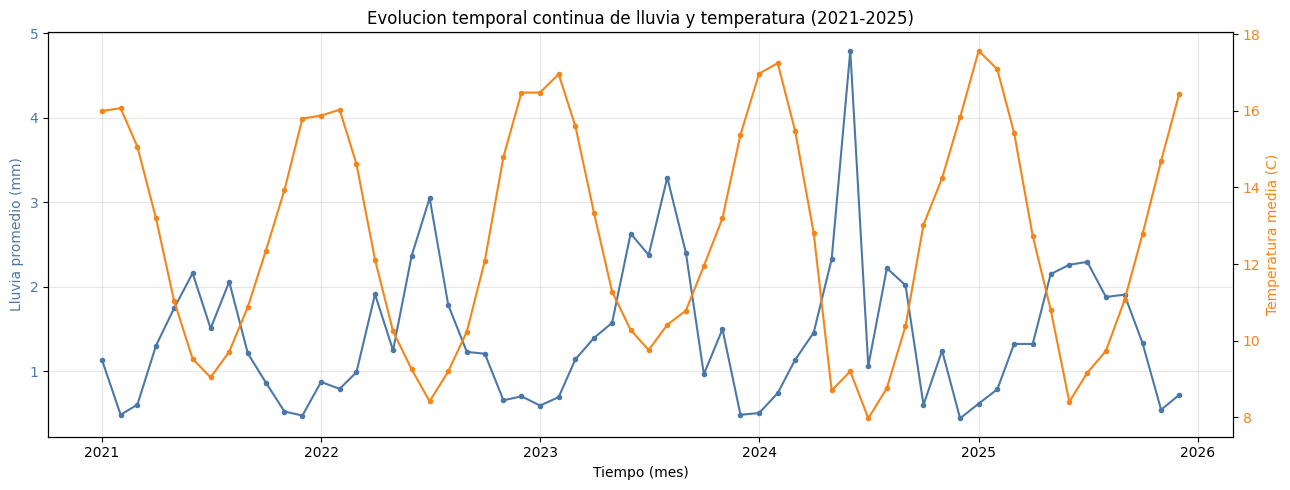

In [47]:
# Serie temporal CONTINUA 2021-2025: evolucion mes a mes de lluvia y temperatura en toda la red.
serie = mensual.sort_values('periodo')
fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(serie['periodo'], serie['agua_promedio'], color='#4c78a8', marker='o', ms=3, label='Lluvia promedio')
ax1.set_xlabel('Tiempo (mes)'); ax1.set_ylabel('Lluvia promedio (mm)', color='#4c78a8')
ax1.tick_params(axis='y', labelcolor='#4c78a8'); ax1.grid(alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(serie['periodo'], serie['temp_media'], color='#f58518', marker='o', ms=3, label='Temp. media')
ax2.set_ylabel('Temperatura media (C)', color='#f58518'); ax2.tick_params(axis='y', labelcolor='#f58518')
ax1.set_title('Evolucion temporal continua de lluvia y temperatura (2021-2025)')
plt.tight_layout(); plt.show()

**Analisis de la serie temporal continua:**

A diferencia del grafico anterior -que superpone los anios mes a mes para ver la estacionalidad-, esta vista despliega el periodo completo 2021-2025 en un eje de tiempo continuo. Se aprecia el ciclo estacional repitiendose cada 12 meses: la lluvia se concentra en invierno y la temperatura va en oposicion de fase (sube en verano). La regularidad de la curva de temperatura frente a la mayor irregularidad de la lluvia refuerza, ya desde el EDA, por que la temperatura se modela con regresion (predecible) y la lluvia como clasificacion.

In [48]:
por_anio_mes = mensual[[
    'anio', 'mes', 'agua_promedio', 'agua_total', 'temp_media'
]].copy()

display(por_anio_mes.head(12))

,anio,mes,agua_promedio,agua_total,temp_media
0,2021,1,1.136755,3488.700008,15.997605
1,2021,2,0.487807,1352.200013,16.070437
2,2021,3,0.607690,1865.000009,15.061290
3,2021,4,1.305815,3862.600017,13.189892
4,2021,5,1.745359,5302.400018,11.045425
5,2021,6,2.163299,6360.100009,9.521667
6,2021,7,1.508986,4584.300021,9.038381
7,2021,8,2.061949,6264.200012,9.709875
8,2021,9,1.213673,3568.200012,10.879048
9,2021,10,0.868938,2601.600013,12.344840


**Analisis de tabla anio-mes:**

La tabla deja trazable la agregacion usada para los graficos siguientes. Al conservar `anio` y `mes` por separado, se evita mezclar todos los a?os en un promedio unico y se puede comparar la estacionalidad de cada periodo.

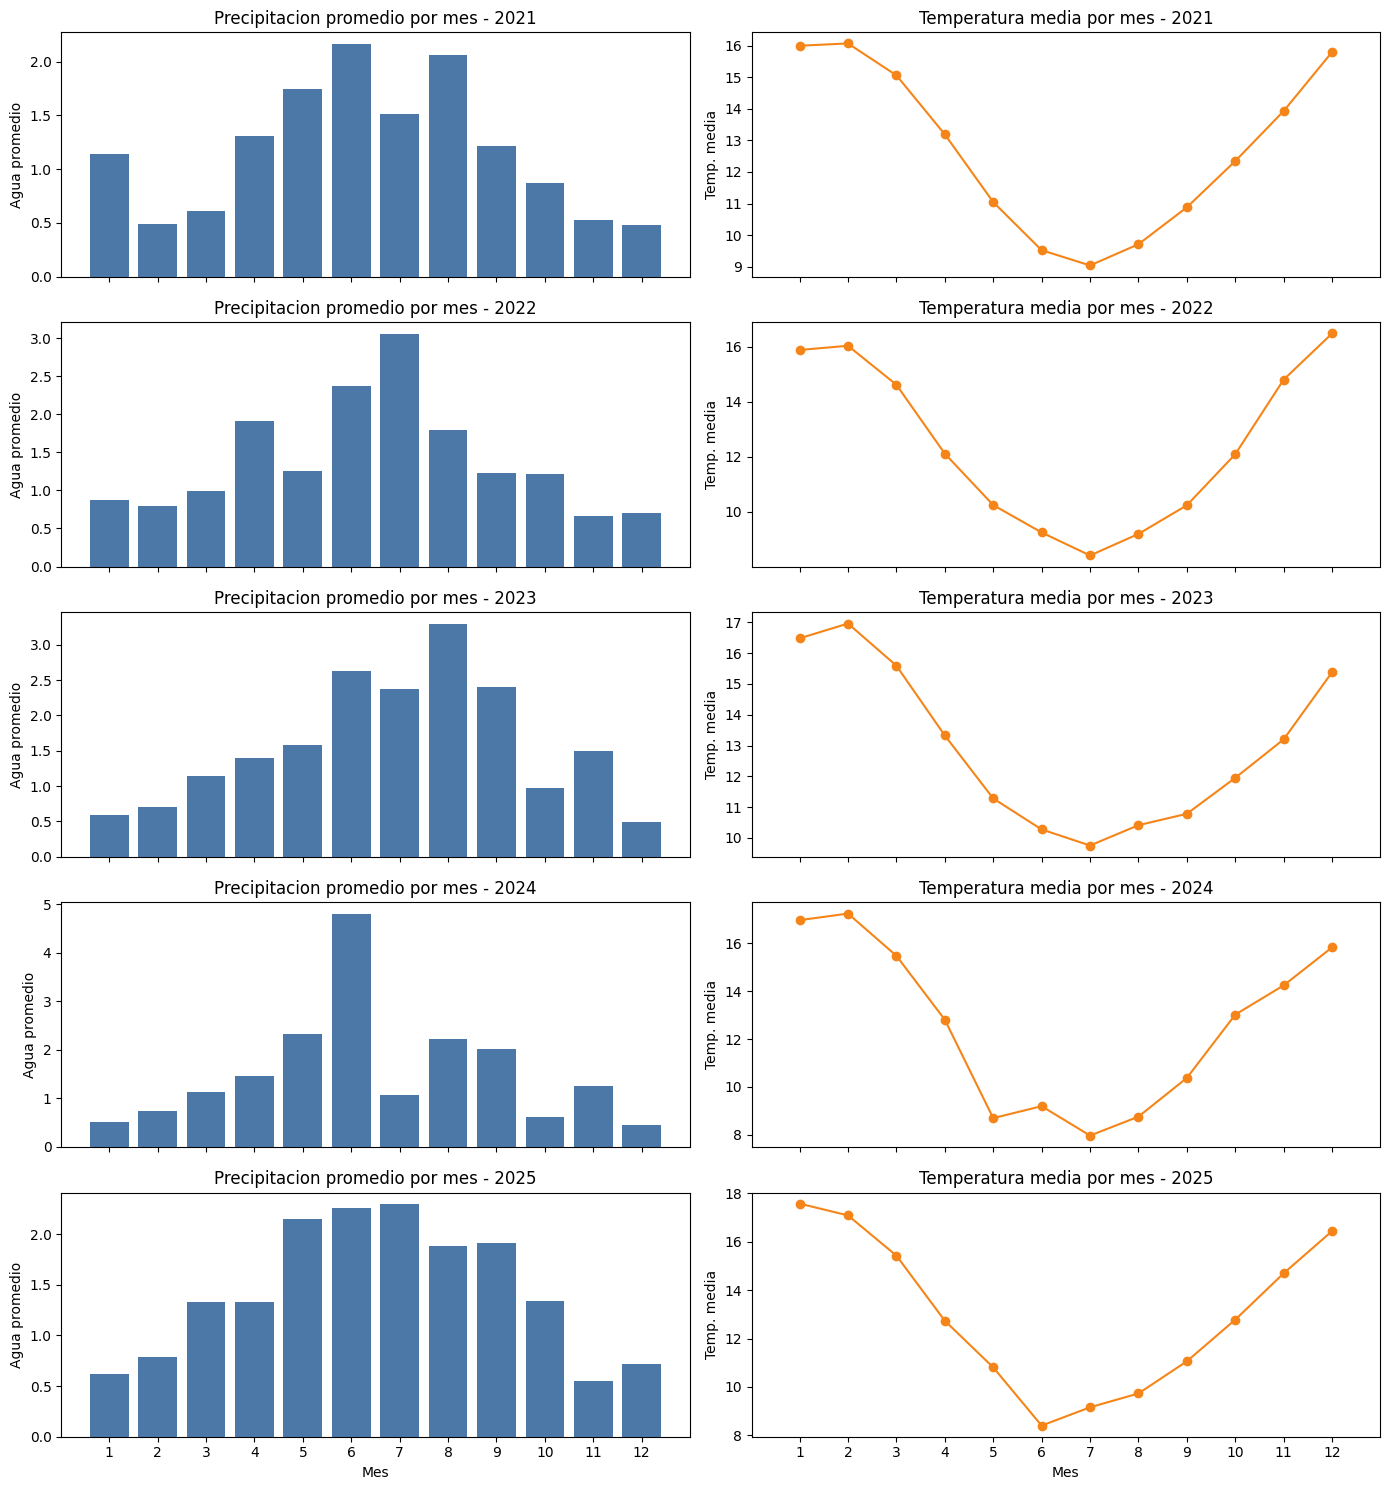

In [49]:
fig, axes = plt.subplots(len(anios_disponibles), 2, figsize=(14, 3 * len(anios_disponibles)), sharex=True)

for fila, anio in enumerate(anios_disponibles):
    datos_anio = por_anio_mes[por_anio_mes['anio'] == anio]
    axes[fila, 0].bar(datos_anio['mes'], datos_anio['agua_promedio'], color='#4c78a8')
    axes[fila, 0].set_title(f'Precipitacion promedio por mes - {anio}')
    axes[fila, 0].set_ylabel('Agua promedio')

    axes[fila, 1].plot(datos_anio['mes'], datos_anio['temp_media'], marker='o', color='#f58518')
    axes[fila, 1].set_title(f'Temperatura media por mes - {anio}')
    axes[fila, 1].set_ylabel('Temp. media')

for ax in axes[-1, :]:
    ax.set_xlabel('Mes')
for ax in axes.ravel():
    ax.set_xticks(meses)

plt.tight_layout()
plt.show()

**Analisis por mes y anio:**

Los paneles muestran la estacionalidad mensual dentro de cada anio. Esto permite observar si los meses lluviosos y los meses mas calidos se mantienen consistentes entre anios o si existen variaciones relevantes que puedan influir en los modelos predictivos.

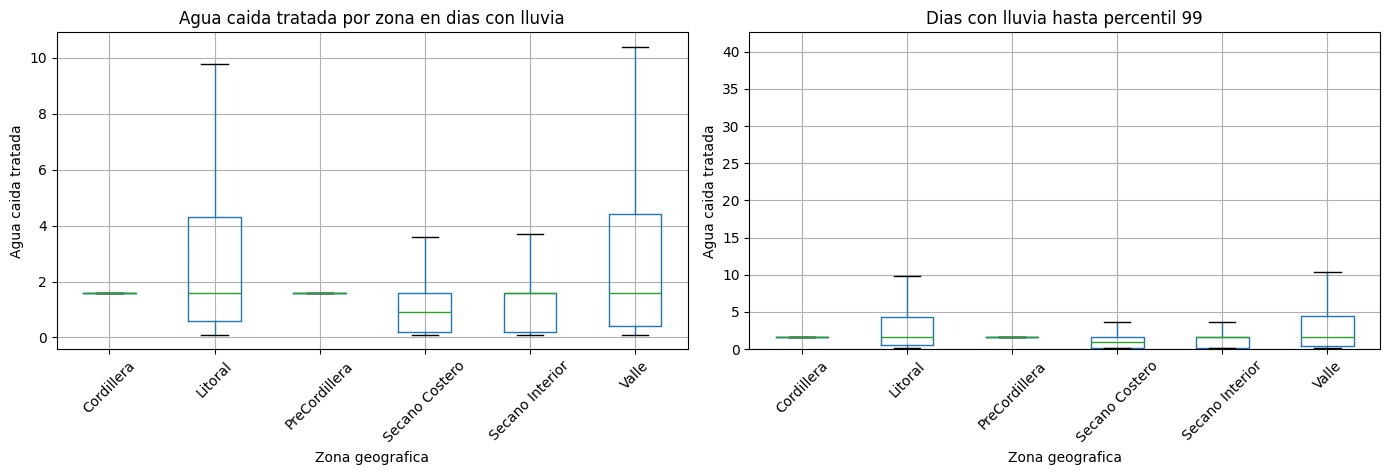

In [50]:
df_zona_lluvia = df_eda[df_eda['agua_caida_tratada'] > 0]
limite_visual_zona = df_zona_lluvia['agua_caida_tratada'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[0], rot=45, showfliers=False)
axes[0].set_title('Agua caida tratada por zona en dias con lluvia')
axes[0].set_xlabel('Zona geografica')
axes[0].set_ylabel('Agua caida tratada')

df_zona_lluvia.boxplot(column='agua_caida_tratada', by='zona_geografica', ax=axes[1], rot=45, showfliers=False)
axes[1].set_title('Dias con lluvia hasta percentil 99')
axes[1].set_xlabel('Zona geografica')
axes[1].set_ylabel('Agua caida tratada')
axes[1].set_ylim(0, limite_visual_zona)

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis por zona en dias con lluvia:**

Al graficar solo dias con lluvia, la dispersion entre zonas se vuelve mas interpretable. La vista al percentil 99 mantiene escala normal y evita depender de transformaciones de escala.

In [51]:
columnas_scatter = ['latitud', 'altura', 'temp_media', 'agua_caida_tratada']
muestra_scatter = df_eda[columnas_scatter].dropna().sample(
    n=min(6000, df_eda[columnas_scatter].dropna().shape[0]),
    random_state=42
)


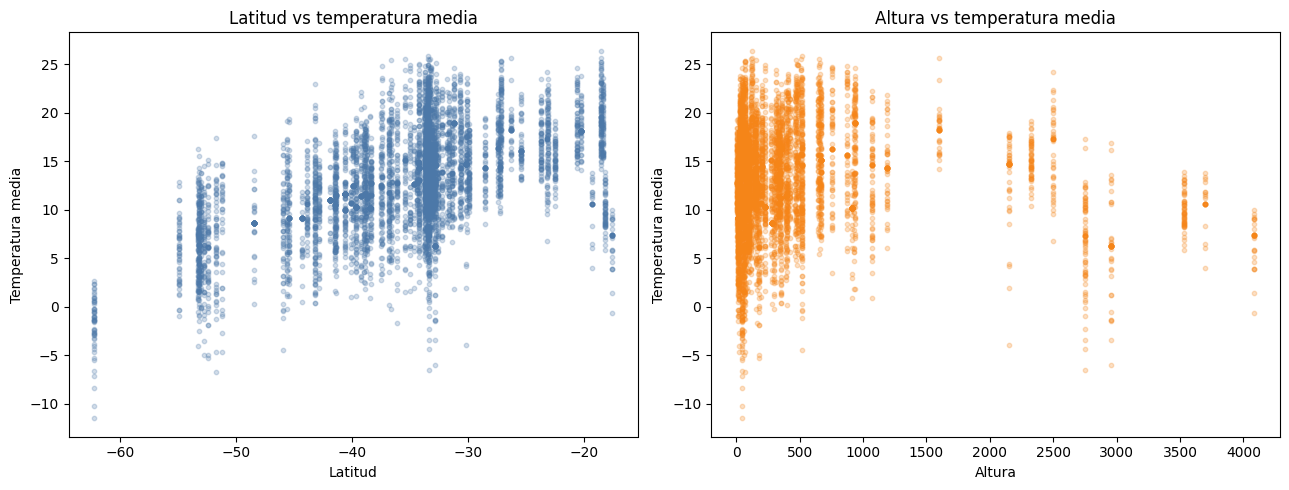

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(muestra_scatter['latitud'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#4c78a8')
axes[0].set_title('Latitud vs temperatura media')
axes[0].set_xlabel('Latitud')
axes[0].set_ylabel('Temperatura media')

axes[1].scatter(muestra_scatter['altura'], muestra_scatter['temp_media'], alpha=0.25, s=10, color='#f58518')
axes[1].set_title('Altura vs temperatura media')
axes[1].set_xlabel('Altura')
axes[1].set_ylabel('Temperatura media')

plt.tight_layout()
plt.show()


**Analisis geografico y temperatura:**

Los scatter plots muestran relacion entre ubicacion, altura y temperatura media. Estos patrones apoyan el uso de variables geograficas en modelos predictivos.

In [53]:
estaciones_geo = df_eda.groupby(['codigo_estacion', 'nombre_estacion']).agg(
    latitud=('latitud', 'mean'),
    longitud=('longitud', 'mean'),
    agua_total=('agua_caida_tratada', 'sum'),
    temp_media=('temp_media', 'mean')
).reset_index()


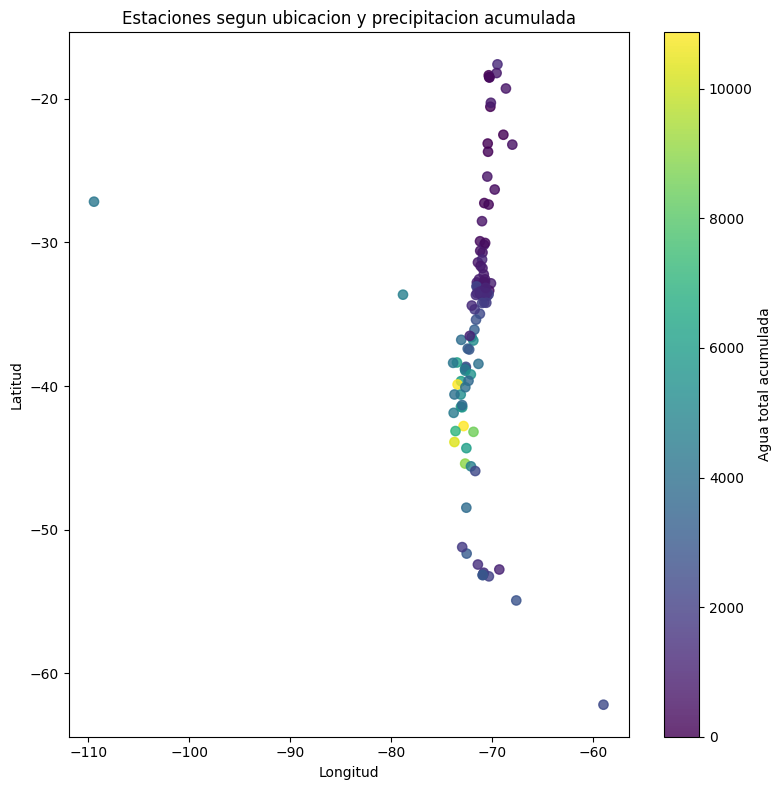

In [54]:
fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    estaciones_geo['longitud'],
    estaciones_geo['latitud'],
    c=estaciones_geo['agua_total'],
    s=45,
    cmap='viridis',
    alpha=0.8
)
ax.set_title('Estaciones segun ubicacion y precipitacion acumulada')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.colorbar(scatter, ax=ax, label='Agua total acumulada')
plt.tight_layout()
plt.show()


**Analisis de estaciones:**

El grafico geografico permite ubicar estaciones y observar donde se acumula mayor precipitacion. Esta vista ayuda a interpretar diferencias territoriales y posibles sesgos de cobertura.

**Patrones detectados inicialmente:**

Los graficos temporales permiten observar estacionalidad: las precipitaciones y temperaturas cambian segun el mes. Los boxplots por zona muestran diferencias territoriales y tambien confirman la presencia de eventos extremos en precipitacion. Los graficos de latitud y altura ayudan a evaluar la hipotesis de que la ubicacion geografica influye en la temperatura. El grafico geografico de estaciones permite visualizar si la lluvia acumulada se concentra en ciertas areas del pais.


## 2.8 Nuevas variables a partir de analisis

A partir del entendimiento inicial se crean variables que facilitan el analisis y el futuro modelamiento. Estas variables traducen informacion climatica y temporal a formatos mas utiles para regresion, clasificacion y clustering.

| Nueva variable | Descripcion | Uso esperado |
|---|---|---|
| `llueve` | 1 si `agua_caida_tratada > 0`, 0 si no | Clasificacion binaria |
| `lluvia_intensa` | 1 si `agua_caida_tratada` supera el umbral de Tukey (Q3 + 1.5*IQR) de los dias con lluvia | Deteccion/clasificacion de lluvia alta no extrema |
| `rango_termico` | `temp_max - temp_min` | Analisis de variabilidad termica |
| `estacion_anio` | Verano, otono, invierno, primavera | Analisis estacional |
| `mes_sin`, `mes_cos` | Representacion ciclica del mes | Modelos con comportamiento anual |


In [55]:
# Umbral de lluvia intensa por la regla de Tukey (Q3 + 1.5*IQR) sobre los dias con lluvia:
# define 'intensa' de forma estadistica (estadisticamente por encima de lo normal), no arbitraria.
_lluvia = df_eda.loc[df_eda['agua_caida_tratada'] > 0, 'agua_caida_tratada']
_q1, _q3 = _lluvia.quantile(0.25), _lluvia.quantile(0.75)
umbral_lluvia_intensa = _q3 + 1.5 * (_q3 - _q1)

def obtener_estacion_anio(mes):
    if mes in [12, 1, 2]:
        return 'Verano'
    if mes in [3, 4, 5]:
        return 'Otono'
    if mes in [6, 7, 8]:
        return 'Invierno'
    return 'Primavera'


In [56]:
df_eda['rango_termico'] = df_eda['temp_max'] - df_eda['temp_min']
df_eda['estacion_anio'] = df_eda['mes'].apply(obtener_estacion_anio)
df_eda['mes_sin'] = np.sin(2 * np.pi * df_eda['mes'] / 12)
df_eda['mes_cos'] = np.cos(2 * np.pi * df_eda['mes'] / 12)

# Isoterma cero: altitud (m) a la que el aire llega a 0 C, via gradiente termico estandar 6.5 C/km.
# isoterma_cero = altura + (temp_media / 6.5) * 1000. Variable fisica ligada al regimen de lluvia/nieve.
# Variable fisica que correlaciona mejor con la lluvia que cualquier variable termica individual.
df_eda['isoterma_cero'] = df_eda['altura'] + (df_eda['temp_media'] / 6.5) * 1000

# Lags temporales de lluvia: capturan la memoria del fenomeno (si llovio ayer, hoy es mas probable).
# Se ordena por estacion y fecha; solo usan dias PASADOS (shift), por lo que no generan fuga.
df_eda = df_eda.sort_values(['codigo_estacion', 'fecha']).reset_index(drop=True)
serie_lluvia = df_eda.groupby('codigo_estacion')['agua_caida_tratada']
df_eda['lluvia_ayer'] = serie_lluvia.shift(1)
df_eda['lluvia_prom_7d'] = serie_lluvia.shift(1).rolling(7, min_periods=1).mean().reset_index(0, drop=True)
df_eda['lluvia_acum_3d'] = serie_lluvia.shift(1).rolling(3, min_periods=1).sum().reset_index(0, drop=True)

df_eda['llueve'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] > 0).astype(int)
)
df_eda['lluvia_intensa'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    (df_eda['agua_caida_tratada'] >= umbral_lluvia_intensa).astype(int)
)

# Lluvia intensa SOSTENIDA: dia intenso que ademas persiste (llovio fuerte ayer o acumulado alto
# en 3 dias). Distingue un temporal de varios dias (sistema frontal) de un pico aislado (chubasco).
df_eda['lluvia_intensa_sostenida'] = np.where(
    df_eda['agua_caida_tratada'].isna(),
    np.nan,
    ((df_eda['agua_caida_tratada'] >= umbral_lluvia_intensa) &
     ((df_eda['lluvia_ayer'] >= umbral_lluvia_intensa / 2) | (df_eda['lluvia_acum_3d'] >= umbral_lluvia_intensa))
    ).astype(int)
)

**Analisis de nuevas variables:**

Ademas de `llueve`, `lluvia_intensa` y `rango_termico`, se crean dos grupos de variables de alto valor predictivo: `isoterma_cero` (altura del nivel de congelamiento, estimada con el gradiente termico 6.5C/km) y los lags de lluvia (`lluvia_ayer`, `lluvia_prom_7d`, `lluvia_acum_3d`), que capturan la memoria temporal del fenomeno. Al inicio de la serie de cada estacion no existe dia previo, por lo que esos lags se imputan con `0` ("sin lluvia previa conocida") en lugar de la mediana global: imputar con mediana inyectaria lluvia donde no hay informacion y degradaria la regresion. `mes_cos` representa la estacionalidad; `mes_sin` se calcula pero se excluye del modelado por su correlacion casi nula con la lluvia.

**Construccion de la isoterma cero (detalle):**

La **isoterma cero** es la **altitud (en metros) a la que la temperatura del aire llega a 0 C**. Se construye combinando la altura de la estacion con su temperatura media, usando el **gradiente termico estandar de la atmosfera: la temperatura baja ~6.5 C por cada 1.000 m de ascenso**. Despejando la altura a la que se alcanzan los 0 C:

`isoterma_cero = altura + (temp_media / 6.5) * 1000`   (en metros)

Interpretacion: una estacion calida o de baja altura tiene su isoterma cero mas arriba; una fria o de gran altura, mas abajo. Es una variable fisica que resume el estado termico de la columna de aire y se asocia con el regimen de lluvia/nieve. La tabla aplica la formula a estaciones de altura y temperatura contrastantes.

In [57]:
# Isoterma cero aplicada a estaciones de altura/temperatura contrastantes (evidencia del calculo)
detalle_isoterma = (df_eda.groupby('codigo_estacion')
    .agg(altura=('altura', 'median'), temp_media=('temp_media', 'mean'), isoterma_cero=('isoterma_cero', 'mean'))
    .round(1))
detalle_isoterma = detalle_isoterma.sort_values('altura').iloc[[0, 1, -2, -1]]
print('Formula:  isoterma_cero = altura + (temp_media / 6.5) * 1000   [m]')
display(detalle_isoterma)

Formula:  isoterma_cero = altura + (temp_media / 6.5) * 1000   [m]


,altura,temp_media,isoterma_cero
codigo_estacion,,,
320056,5.0,13.1,2027.8
380082,6.0,12.8,1976.1
190010,3700.0,10.1,5252.4
170001,4084.0,7.1,5173.2


**Analisis de la isoterma cero:**

La tabla contrasta estaciones de baja y alta altitud: la isoterma cero -altura a la que el aire alcanza 0 C, estimada con el gradiente termico estandar (6.5 C/km)- sube en estaciones mas calidas y de mayor cota. Es una variable fisica derivada, util para entender nieve y heladas, y se usa solo como feature; queda excluida del pronostico de lluvia por ser informacion del mismo dia (evita fuga).

**Incorporacion de un segundo dataset (variables atmosfericas):**

Ademas de las variables derivadas, se incorpora un **segundo dataset de reanalisis (NASA POWER)** con el estado atmosferico diario por estacion: humedad relativa, velocidad y direccion del viento (codificada de forma ciclica en seno/coseno por ser angular), radiacion solar y presion. Estas variables -que la red EMA de la DMC mide pero solo publica en tiempo real, no en su historico- gobiernan si un dia concreto llueve y cuanto, por lo que son candidatas de alto valor para la regresion diaria. La lluvia objetivo sigue siendo la **medida** por la DMC; el reanalisis solo aporta predictores. Por tratarse de un producto con control de calidad, no presenta los errores groseros del CSV principal y no requiere tratamiento de outliers: solo se revisan nulos. A continuacion se ven sus estadisticos, nulos y su correlacion con la precipitacion (su finalidad eficaz).

In [58]:
# Segundo dataset atmosferico (reanalisis NASA POWER): carga y union a df_eda por estacion y fecha.
# Raw del dataset atmosferico en el repo de datos:
ATMOS_URL = 'https://raw.githubusercontent.com/4mnesia/DataMining_Datos/refs/heads/main/atmosfera_diario.csv'
df_atmosfera = pd.read_csv(ATMOS_URL, parse_dates=['fecha'])
df_atmosfera['codigo_estacion'] = df_atmosfera['codigo_estacion'].astype(int)

# Variables atmosfericas del dia. 'nasa_precip' (precipitacion modelada del reanalisis) se trata
# aparte como predictor de apoyo (es una estimacion independiente, no la lluvia medida que es el target).
columnas_atmosfericas = ['humedad', 'viento_vel', 'viento_dir_sin', 'viento_dir_cos', 'radiacion',
                         'radiacion_lw', 'indice_claridad', 'presion', 'nubosidad', 'rocio', 'hum_especifica']
columnas_atmos_union = columnas_atmosfericas + ['nasa_precip', 'nasa_temp']

df_eda['codigo_estacion'] = df_eda['codigo_estacion'].astype(int)
df_eda = df_eda.merge(
    df_atmosfera[['codigo_estacion', 'fecha'] + columnas_atmos_union],
    on=['codigo_estacion', 'fecha'], how='left'
).sort_values(['codigo_estacion', 'fecha']).reset_index(drop=True)

# Lags atmosfericos: estado del dia anterior por estacion (solo pasado, sin fuga)
for _c in ['humedad', 'nubosidad', 'presion', 'radiacion']:
    df_eda[_c + '_ayer'] = df_eda.groupby('codigo_estacion')[_c].shift(1)
columnas_atmosfericas_lag = ['humedad_ayer', 'nubosidad_ayer', 'presion_ayer', 'radiacion_ayer']

# Estadisticos y nulos
resumen_atmosfera = df_eda[columnas_atmosfericas].describe().T[['mean', 'std', 'min', 'max']].round(2)
resumen_atmosfera['nulos'] = df_eda[columnas_atmosfericas].isna().sum().values
display(resumen_atmosfera)

# Finalidad eficaz: correlacion absoluta de cada variable atmosferica con la lluvia diaria
correlacion_atmosfera = (
    df_eda[columnas_atmosfericas + ['nasa_precip', 'agua_caida_tratada']].corr()['agua_caida_tratada']
    .drop('agua_caida_tratada').abs().sort_values(ascending=False)
    .to_frame('correlacion_abs_con_lluvia').round(3)
)
display(correlacion_atmosfera)

,mean,std,min,max,nulos
humedad,62.51,23.17,1.52,100.00,0
viento_vel,3.57,2.05,0.45,20.43,0
viento_dir_sin,-0.45,0.56,-1.00,1.00,0
viento_dir_cos,-0.12,0.69,-1.00,1.00,0
radiacion,17.84,9.43,0.22,36.68,0
radiacion_lw,26.36,3.19,14.80,36.61,0
indice_claridad,0.58,0.18,0.05,0.87,106
presion,93.32,8.75,60.78,103.52,0
nubosidad,54.71,30.16,0.07,100.00,106
rocio,3.41,7.24,-33.22,22.85,0


,correlacion_abs_con_lluvia
nasa_precip,0.438
indice_claridad,0.382
viento_dir_cos,0.280
nubosidad,0.276
radiacion,0.274
humedad,0.245
viento_vel,0.105
radiacion_lw,0.089
rocio,0.088
presion,0.078


**Analisis del dataset atmosferico:**

Las variables atmosfericas quedan unidas a cada registro diario por estacion y fecha. La tabla muestra su asociacion con la lluvia (util para la **clasificacion** de `llueve`/`lluvia_intensa`): `nasa_precip`, `indice_claridad`, `nubosidad`, `radiacion` y `humedad` son las mas correlacionadas. Estas mismas variables -mas la temperatura del reanalisis (`nasa_temp`)- alimentan la **regresion de temperatura diaria** (Fase 4.1), que junto con la ubicacion y la estacionalidad permite estimar la temperatura con `R2` alto. La lluvia se mantiene en el proyecto como problema de clasificacion.

## 2.9 Matriz de Correlacion general (con las nuevas variables)

Tras crear las nuevas variables (derivadas y el dataset atmosferico), se calcula una **matriz de correlacion general con todas las variables implementadas**: geograficas y temporales, climaticas medidas (DMC), atmosfericas del reanalisis (NASA POWER) y derivadas (lags, isoterma, ciclicas). Da una vista unica de como se relacionan entre si y con los objetivos, y orienta su uso en el modelamiento.

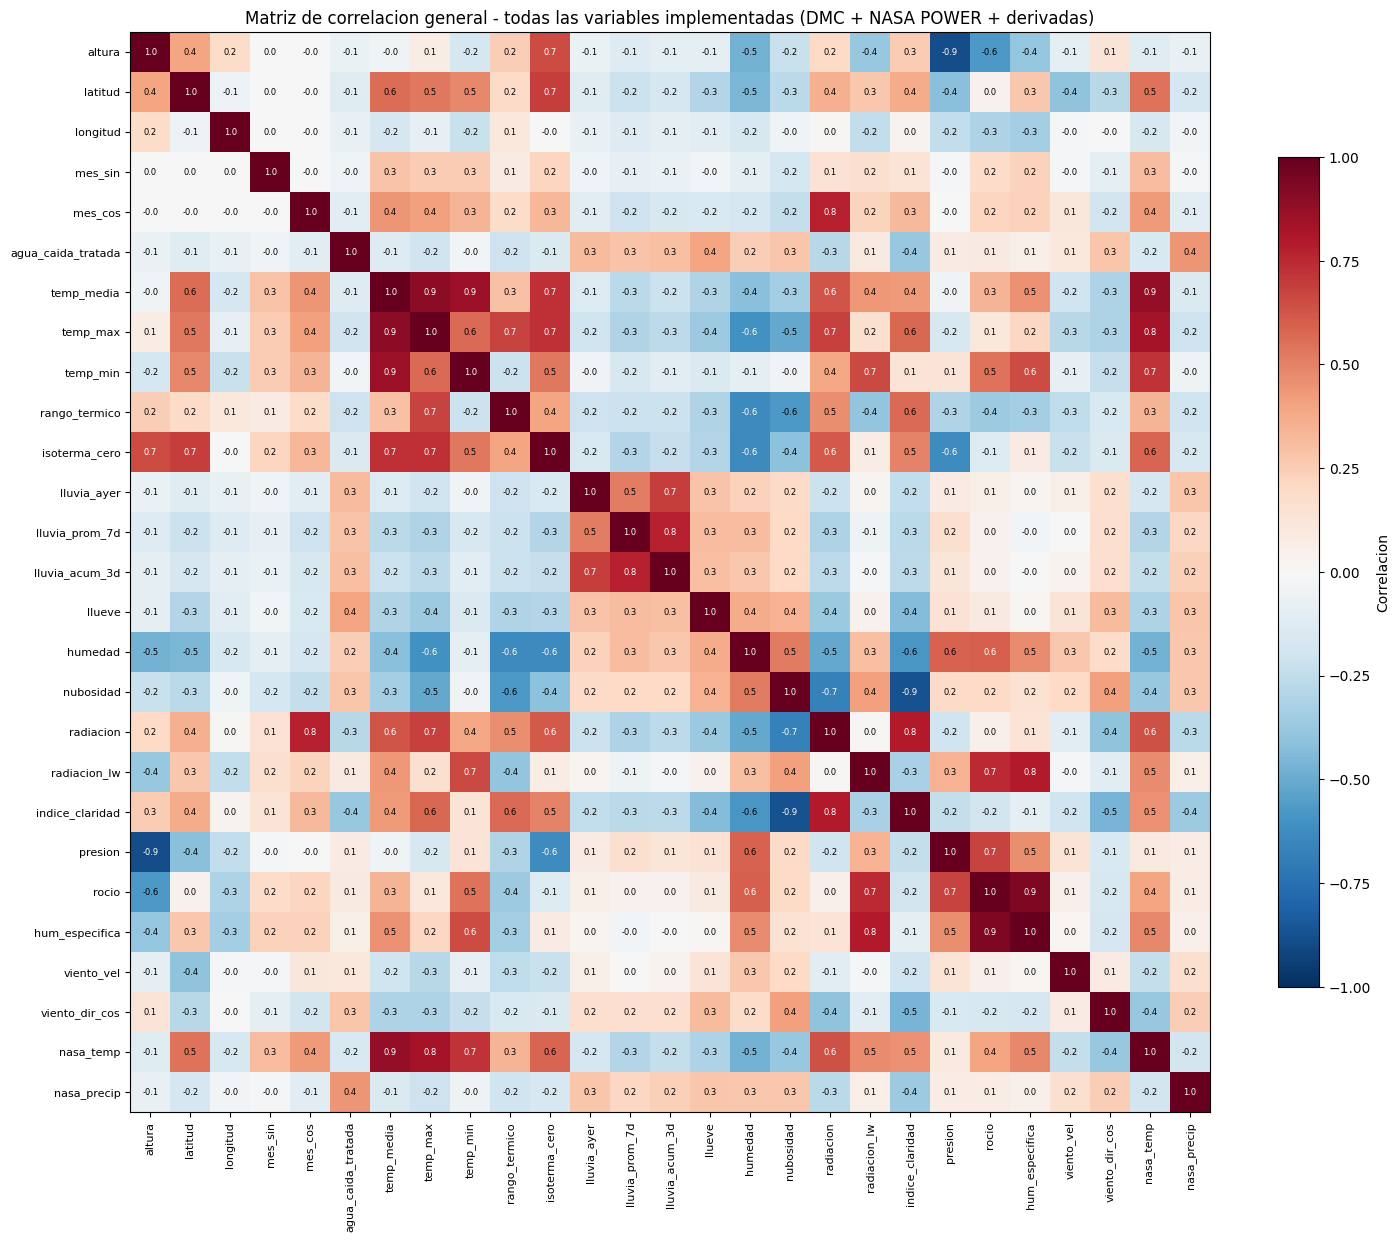

In [59]:
# Matriz de correlacion general: todas las variables numericas implementadas
columnas_correlacion_general = [
    # geograficas / temporales
    'altura', 'latitud', 'longitud', 'mes_sin', 'mes_cos',
    # climaticas medidas (DMC)
    'agua_caida_tratada', 'temp_media', 'temp_max', 'temp_min', 'rango_termico', 'isoterma_cero',
    # derivadas de lluvia
    'lluvia_ayer', 'lluvia_prom_7d', 'lluvia_acum_3d', 'llueve',
    # atmosfericas (NASA POWER)
    'humedad', 'nubosidad', 'radiacion', 'radiacion_lw', 'indice_claridad', 'presion',
    'rocio', 'hum_especifica', 'viento_vel', 'viento_dir_cos', 'nasa_temp', 'nasa_precip',
]
columnas_correlacion_general = [c for c in columnas_correlacion_general if c in df_eda.columns]
corr_general = df_eda[columnas_correlacion_general].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(corr_general.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_general.columns))); ax.set_xticklabels(corr_general.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr_general.index))); ax.set_yticklabels(corr_general.index, fontsize=8)
for (i, j), val in np.ndenumerate(corr_general.values):
    ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=6,
            color='white' if abs(val) > 0.6 else 'black')
ax.set_title('Matriz de correlacion general - todas las variables implementadas (DMC + NASA POWER + derivadas)')
plt.colorbar(im, ax=ax, shrink=0.7, label='Correlacion')
plt.tight_layout(); plt.show()

**Analisis de la matriz general:**

La vista consolidada confirma los bloques esperados: las temperaturas medidas estan muy correlacionadas entre si y con `nasa_temp` (consistencia entre el dato DMC y el reanalisis) y se asocian con la latitud y la altura, lo que respalda **HR1** (la temperatura media depende de la ubicacion y la epoca del anio). La humedad, la nubosidad y el rocio se asocian positivamente con la lluvia, mientras que la radiacion y el indice de claridad lo hacen de forma negativa (cielo despejado = sin lluvia); los lags de lluvia muestran la persistencia temporal del fenomeno. Las correlaciones lineales individuales son moderadas, pero combinadas en modelos no lineales explican bien el comportamiento climatico, y orientan el uso de cada variable en la **regresion de temperatura** y la **clasificacion de lluvia** (Fase 4).

## 2.10 Patrones/comportamientos detectados con nuevas variables

Con las nuevas variables se analizan patrones mas cercanos al futuro modelamiento: dias con lluvia, lluvia intensa, estacionalidad y relaciones entre variables climaticas. Tambien se incluye una visualizacion tipo pairplot para observar relaciones combinadas entre variables.


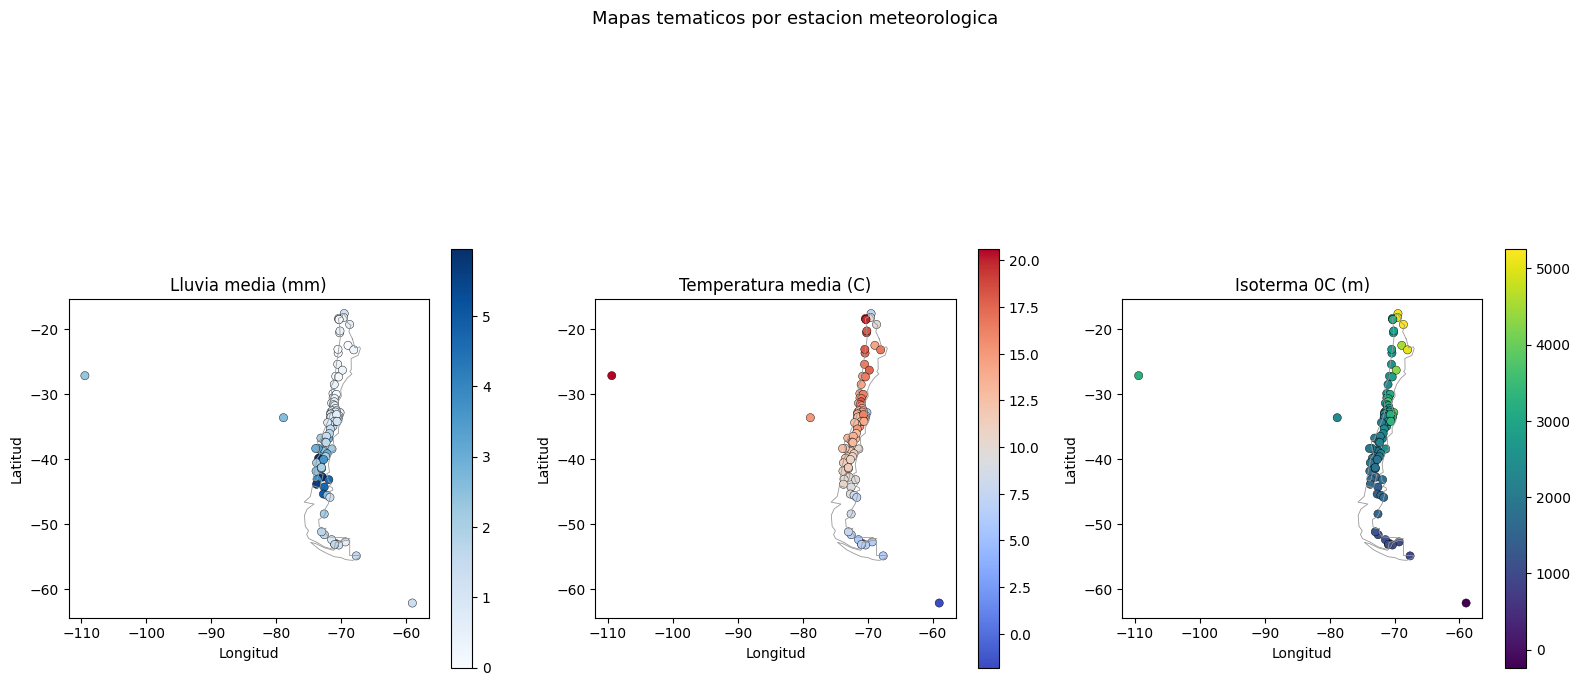

In [60]:
estaciones_mapa = df_eda.groupby('codigo_estacion').agg(
    latitud=('latitud', 'mean'), longitud=('longitud', 'mean'),
    agua=('agua_caida_tratada', 'mean'), temp=('temp_media', 'mean'),
    isoterma=('isoterma_cero', 'mean')
).dropna()
_geo_mapa = json.loads(descargar_texto(CHILE_GEOJSON))["features"][0]["geometry"]
poligonos_mapa = [_geo_mapa["coordinates"]] if _geo_mapa["type"] == "Polygon" else _geo_mapa["coordinates"]

fig, axes = plt.subplots(1, 3, figsize=(16, 9))
capas = [('agua', 'Lluvia media (mm)', 'Blues'), ('temp', 'Temperatura media (C)', 'coolwarm'), ('isoterma', 'Isoterma 0C (m)', 'viridis')]
for ax, (columna, titulo, cmap) in zip(axes, capas):
    for poligono in poligonos_mapa:
        for anillo in poligono:
            coords = np.array(anillo)
            ax.plot(coords[:, 0], coords[:, 1], color='0.6', linewidth=0.6)
    puntos = ax.scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'],
                        c=estaciones_mapa[columna], cmap=cmap, s=35, edgecolor='black', linewidth=0.3)
    ax.set_title(titulo); ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
    ax.set_aspect('equal', adjustable='box')
    plt.colorbar(puntos, ax=ax, shrink=0.5)
fig.suptitle('Mapas tematicos por estacion meteorologica', fontsize=13)
plt.tight_layout()
plt.show()

**Analisis de los mapas tematicos:**

Los mapas muestran el gradiente norte-sur de Chile: la lluvia media aumenta hacia el sur, la temperatura disminuye, y la isoterma cero baja con la latitud. La coherencia espacial de las tres variables confirma que la ubicacion geografica y el estado termico son predictores legitimos de la precipitacion.

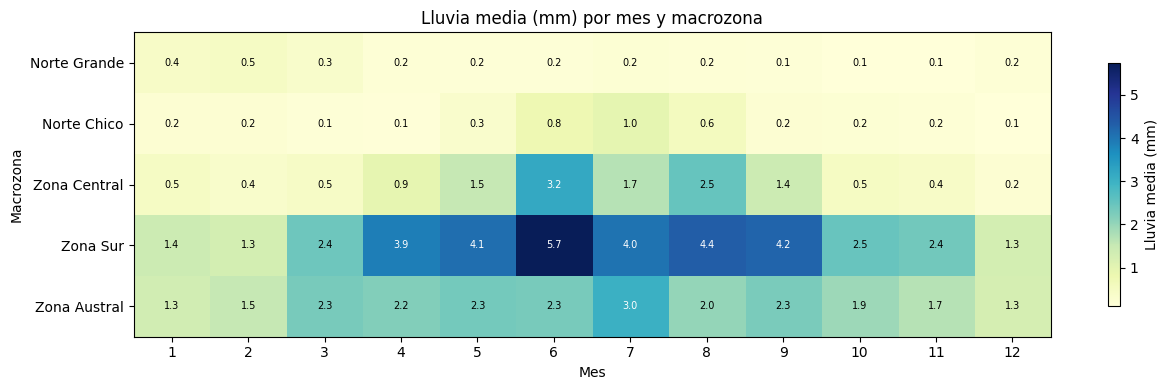

In [61]:
pivote_mes_macro = df_eda.pivot_table(
    values='agua_caida_tratada', index='macrozona', columns='mes', aggfunc='mean', observed=True
)
fig, ax = plt.subplots(figsize=(13, 4))
imagen = ax.imshow(pivote_mes_macro.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(12)); ax.set_xticklabels(range(1, 13))
ax.set_yticks(range(len(pivote_mes_macro.index))); ax.set_yticklabels(list(pivote_mes_macro.index))
for (fila, columna), valor in np.ndenumerate(pivote_mes_macro.values):
    ax.text(columna, fila, f'{valor:.1f}', ha='center', va='center', fontsize=7,
            color='black' if valor < np.nanmax(pivote_mes_macro.values)/2 else 'white')
ax.set_title('Lluvia media (mm) por mes y macrozona')
ax.set_xlabel('Mes'); ax.set_ylabel('Macrozona')
plt.colorbar(imagen, ax=ax, shrink=0.8, label='Lluvia media (mm)')
plt.tight_layout()
plt.show()

**Analisis de estacionalidad por macrozona:**

El heatmap confirma el patron climatico de Chile: la Zona Sur y Austral concentran lluvia durante todo el ano con maximos invernales (meses 5-8), la Zona Central tiene un regimen marcadamente invernal, y el Norte Grande/Chico se mantiene seco casi todo el ano. Esto respalda las hipotesis H1 (variacion territorial) y H2 (estacionalidad).

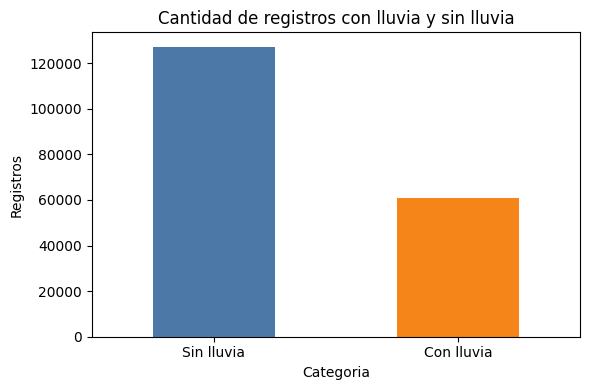

In [62]:
conteo_lluvia = df_eda['llueve'].map({0: 'Sin lluvia', 1: 'Con lluvia'}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
conteo_lluvia.plot(kind='bar', ax=ax, color=['#4c78a8', '#f58518'])
ax.set_title('Cantidad de registros con lluvia y sin lluvia')
ax.set_xlabel('Categoria')
ax.set_ylabel('Registros')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Analisis de balance de lluvia (cero-inflacion y predictibilidad):**

La clase `Sin lluvia` es mayoritaria (~2/3 de los registros). Consecuencias:

- **Clasificacion:** la accuracy engaña por el desbalance; se usan precision, recall y F1.
- **Regresion:** estimar el milimetraje diario es dificil con solo ubicacion y temperatura porque depende del **estado atmosferico del dia** (humedad, viento, presion, radiacion), que el dataset original de la DMC no trae en su historico. Por eso se incorpora un **segundo dataset atmosferico** (reanalisis NASA POWER, Fase 3) con esas variables por estacion y dia. Esto aproximadamente duplica el `R2` diario (ver Fase 5), confirmando que buena parte del "ruido" diario era senal atmosferica faltante.

In [63]:
lluvia_intensa_region = df_eda[df_eda['lluvia_intensa'] == 1].groupby('nombre_region').size().sort_values()
lluvia_intensa_zona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('zona_geografica').size().sort_values()
lluvia_intensa_macrozona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('macrozona', observed=True).size()


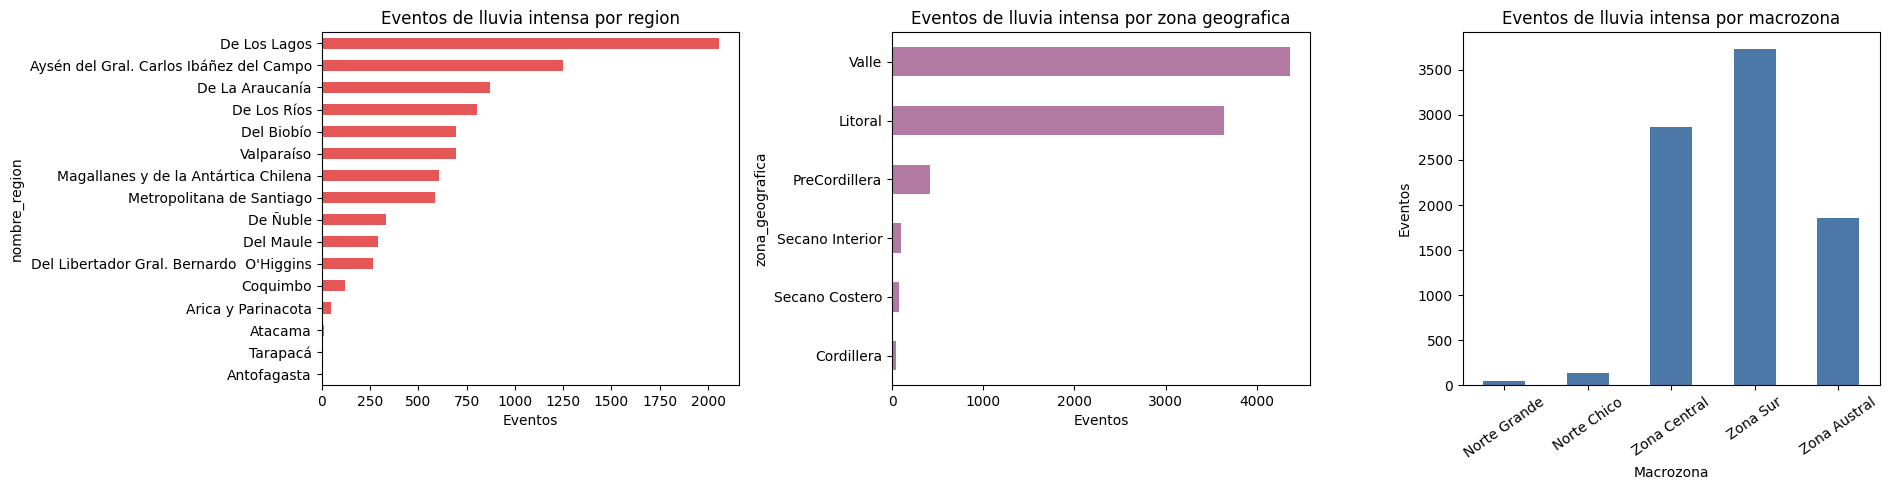

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

lluvia_intensa_region.plot(kind='barh', ax=axes[0], color='#e45756')
axes[0].set_title('Eventos de lluvia intensa por region')
axes[0].set_xlabel('Eventos')

lluvia_intensa_zona.plot(kind='barh', ax=axes[1], color='#b279a2')
axes[1].set_title('Eventos de lluvia intensa por zona geografica')
axes[1].set_xlabel('Eventos')

lluvia_intensa_macrozona.plot(kind='bar', ax=axes[2], color='#4c78a8')
axes[2].set_title('Eventos de lluvia intensa por macrozona')
axes[2].set_xlabel('Macrozona')
axes[2].set_ylabel('Eventos')
axes[2].tick_params(axis='x', rotation=35)

plt.tight_layout()
plt.show()


**Analisis de lluvia intensa:**

Los eventos intensos son menos frecuentes y se concentran territorialmente. Esto anticipa un problema de clasificacion desbalanceado, donde recall y F1 son mas informativos que accuracy sola.

,tipo,dias,pct
0,Intensa (cualquier dia),8631,4.59
1,Intensa sostenida (persiste),4857,2.59


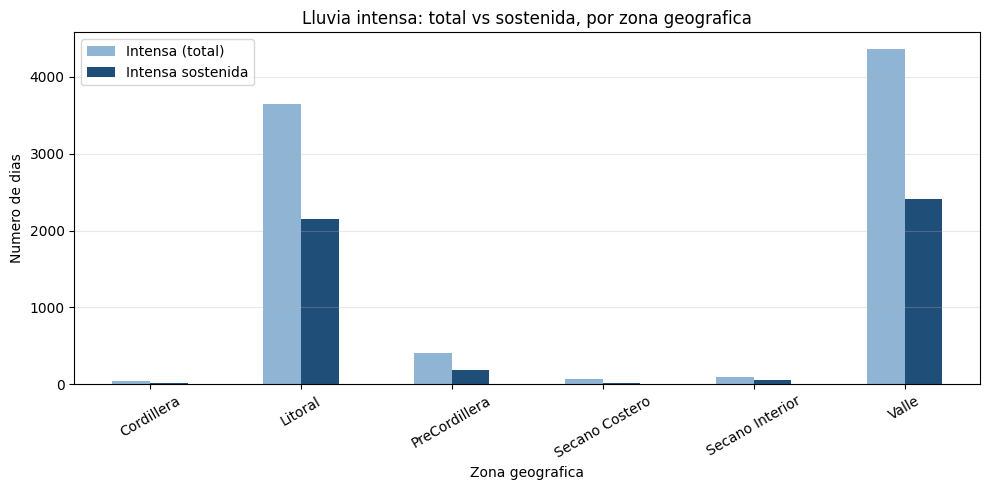

In [65]:
# Comparacion: lluvia intensa total (pico) vs sostenida (temporal de varios dias)
resumen_intensa = pd.DataFrame([
    {'tipo': 'Intensa (cualquier dia)', 'dias': int(df_eda['lluvia_intensa'].sum()),
     'pct': round(100 * df_eda['lluvia_intensa'].mean(), 2)},
    {'tipo': 'Intensa sostenida (persiste)', 'dias': int(df_eda['lluvia_intensa_sostenida'].sum()),
     'pct': round(100 * df_eda['lluvia_intensa_sostenida'].mean(), 2)},
])
display(resumen_intensa)

# Distribucion territorial de cada tipo
sostenida_zona = df_eda[df_eda['lluvia_intensa_sostenida'] == 1].groupby('zona_geografica').size()
pico_zona = df_eda[df_eda['lluvia_intensa'] == 1].groupby('zona_geografica').size()
comp = pd.DataFrame({'Intensa (total)': pico_zona, 'Intensa sostenida': sostenida_zona}).fillna(0)

fig, ax = plt.subplots(figsize=(10, 5))
comp.plot(kind='bar', ax=ax, color=['#90b4d4', '#1f4e79'])
ax.set_title('Lluvia intensa: total vs sostenida, por zona geografica')
ax.set_xlabel('Zona geografica'); ax.set_ylabel('Numero de dias'); ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de lluvia intensa sostenida:**

No toda lluvia intensa es igual: se distingue la **intensa total** (cualquier dia que supera el umbral de Tukey) de la **intensa sostenida** (un dia intenso que ademas persiste, porque tambien llovio fuerte el dia anterior o el acumulado de 3 dias es alto). Aproximadamente la mitad de los dias intensos son sostenidos -temporales de varios dias asociados a sistemas frontales- y la otra mitad son **picos aislados** (chubascos de un dia). Ambos tipos se concentran en el **sur** (Valle y Litoral), pero la version sostenida es la mas relevante para riesgo hidrologico, porque la lluvia acumulada en dias consecutivos es la que satura suelos y genera crecidas. Esta distincion enriquece el entendimiento del fenomeno aunque, por su rareza, la lluvia intensa no se modele como objetivo predictivo.

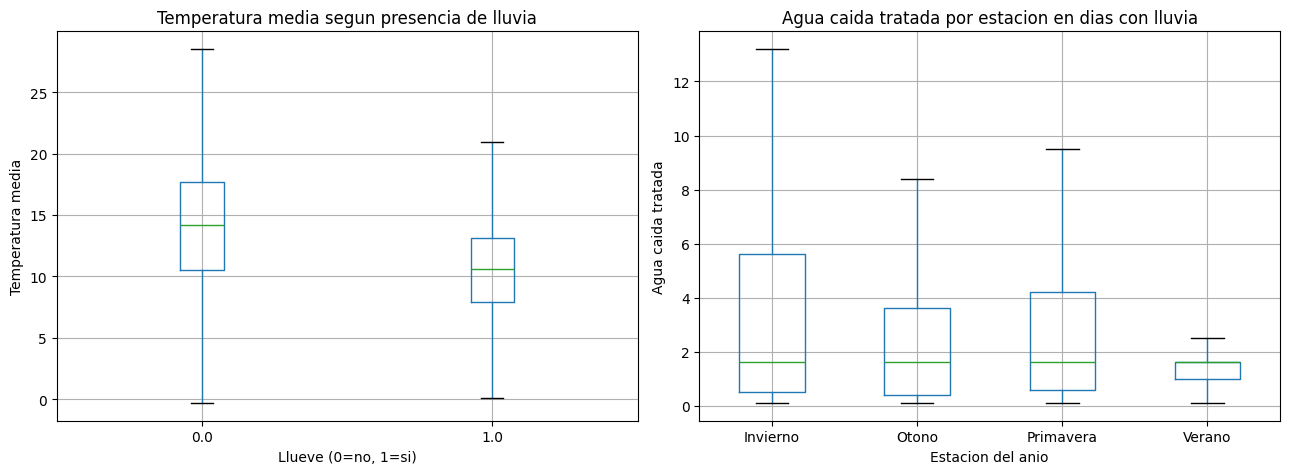

In [66]:
df_lluvia_positiva = df_eda[df_eda['agua_caida_tratada'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df_eda.boxplot(column='temp_media', by='llueve', ax=axes[0], showfliers=False)
axes[0].set_title('Temperatura media segun presencia de lluvia')
axes[0].set_xlabel('Llueve (0=no, 1=si)')
axes[0].set_ylabel('Temperatura media')

df_lluvia_positiva.boxplot(column='agua_caida_tratada', by='estacion_anio', ax=axes[1], showfliers=False)
axes[1].set_title('Agua caida tratada por estacion en dias con lluvia')
axes[1].set_xlabel('Estacion del anio')
axes[1].set_ylabel('Agua caida tratada')

plt.suptitle('')
plt.tight_layout()
plt.show()


**Analisis comparativo de clases:**

La lluvia se asocia a diferencias de temperatura y estacionalidad. Estos patrones justifican usar variables climaticas y temporales para clasificar presencia de lluvia o lluvia intensa.

In [67]:
variables_pairplot = ['isoterma_cero', 'lluvia_prom_7d', 'temp_max', 'latitud', 'rango_termico']
muestra_pairplot = df_eda[variables_pairplot + ['llueve']].dropna().sample(
    n=min(3000, df_eda[variables_pairplot + ['llueve']].dropna().shape[0]),
    random_state=42
).copy()
muestra_pairplot['llueve'] = muestra_pairplot['llueve'].map({0: 'No llueve', 1: 'Llueve'})

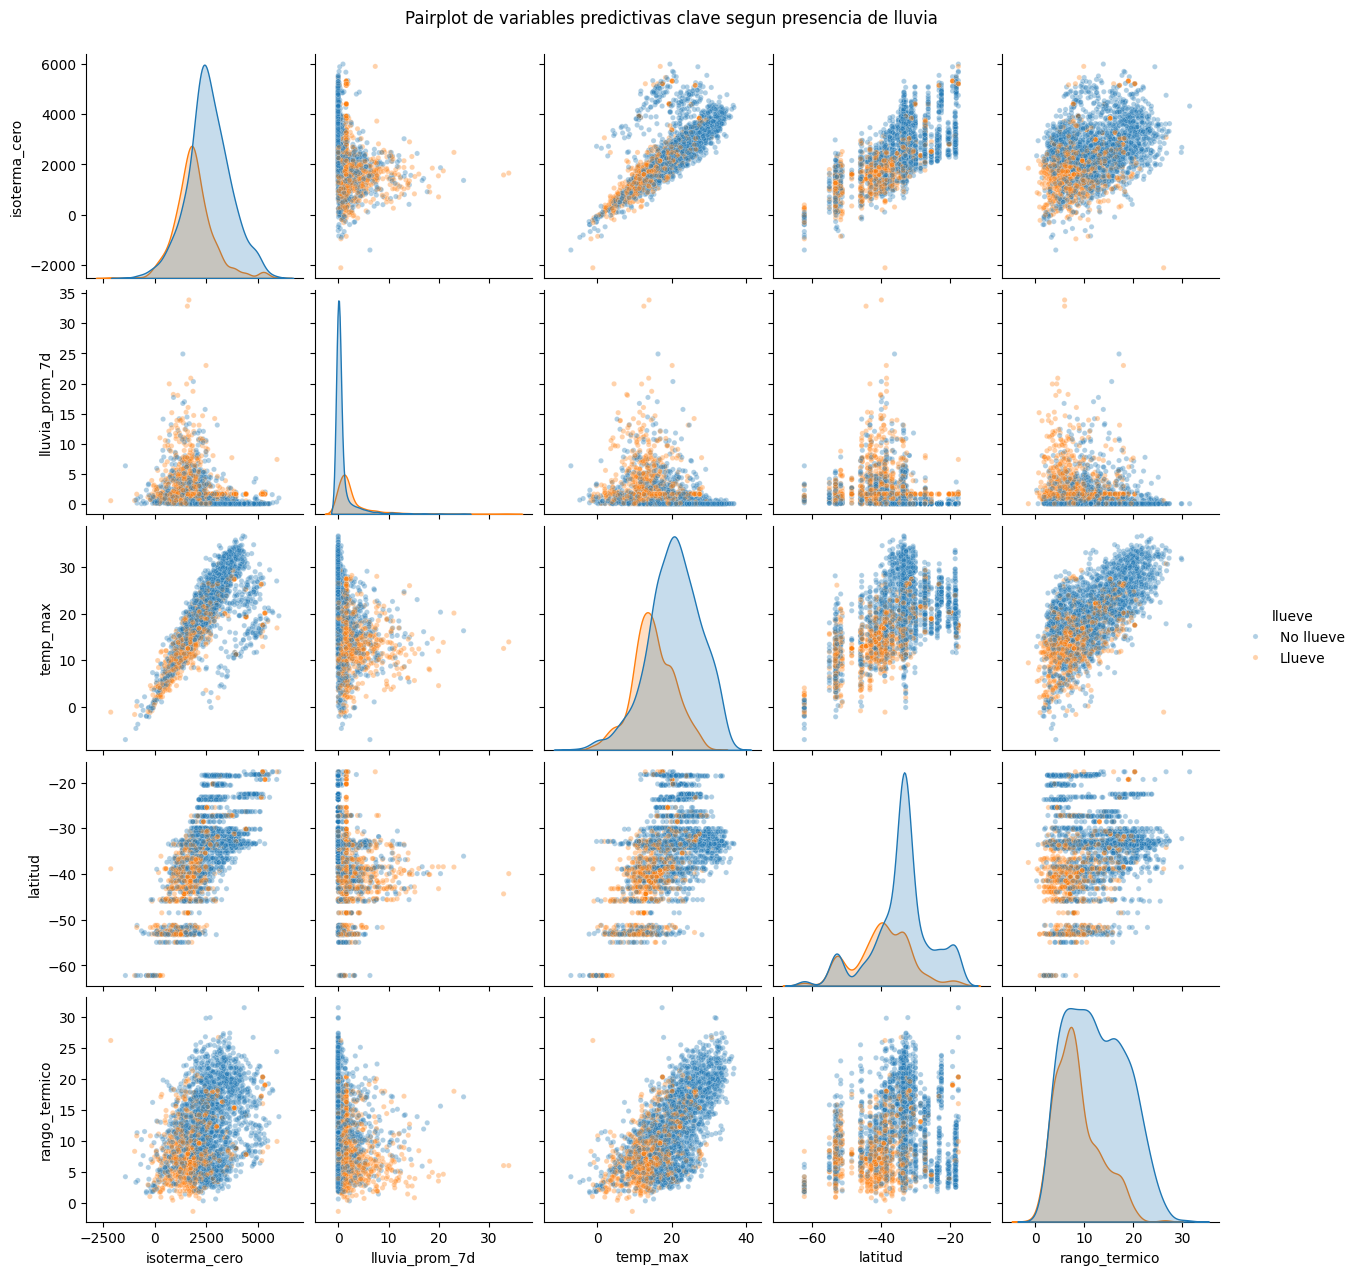

In [68]:
if SEABORN_DISPONIBLE:
    grafico_pairplot = sns.pairplot(
        muestra_pairplot,
        vars=variables_pairplot,
        hue='llueve',
        diag_kind='kde',
        plot_kws={'alpha': 0.35, 's': 14}
    )
    grafico_pairplot.fig.suptitle('Pairplot de variables predictivas clave segun presencia de lluvia', y=1.02)
    plt.show()
else:
    colores = np.where(muestra_pairplot['llueve'] == 'Llueve', '#f58518', '#4c78a8')
    scatter_matrix(
        muestra_pairplot[variables_pairplot],
        figsize=(12, 12), diagonal='kde', color=colores, alpha=0.35
    )
    plt.suptitle('Scatter matrix de variables predictivas clave', y=0.92)
    plt.show()

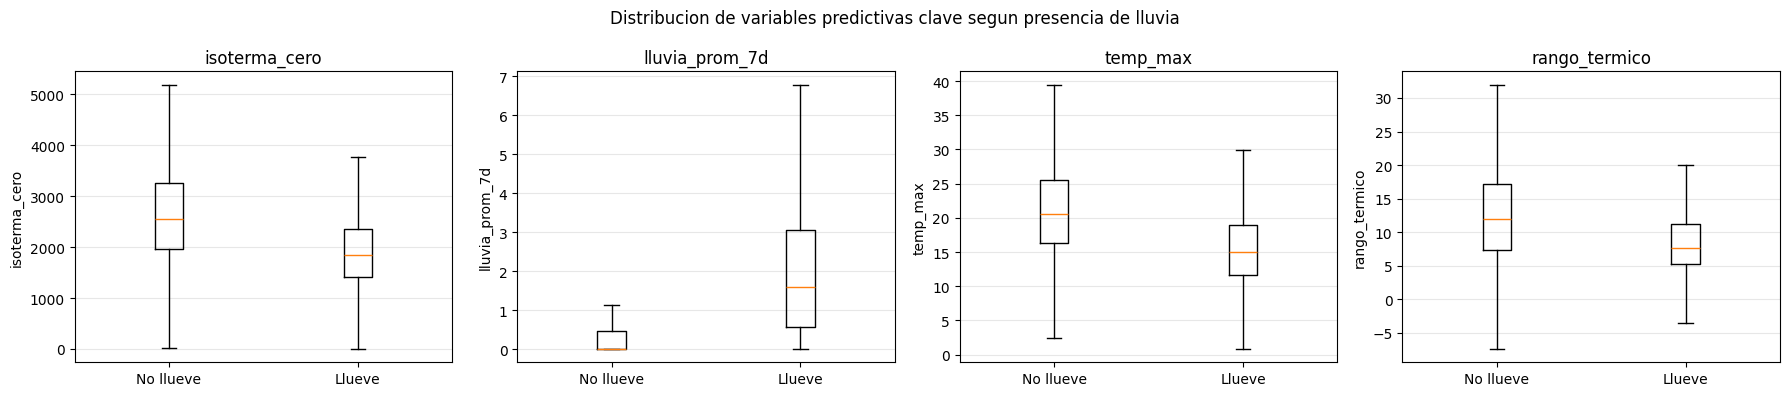

In [69]:
variables_box = ['isoterma_cero', 'lluvia_prom_7d', 'temp_max', 'rango_termico']
fig, axes = plt.subplots(1, len(variables_box), figsize=(18, 4))
for ax, var in zip(axes, variables_box):
    datos_box = [
        df_eda.loc[df_eda['llueve'] == 0, var].dropna(),
        df_eda.loc[df_eda['llueve'] == 1, var].dropna()
    ]
    ax.boxplot(datos_box, showfliers=False)
    ax.set_xticks([1, 2])
    ax.set_xticklabels(['No llueve', 'Llueve'])
    ax.set_title(var)
    ax.set_ylabel(var)
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('Distribucion de variables predictivas clave segun presencia de lluvia')
plt.tight_layout()
plt.show()

**Analisis de los boxplots por presencia de lluvia:**

Los boxplots confirman que las variables predictivas separan los dias con y sin lluvia: en dias lluviosos la isoterma cero es mas baja (aire mas frio), el rango termico se reduce (cielo nublado) y la lluvia de los dias previos es mayor. Esto respalda que estas variables aporten senal real a los modelos de clasificacion.

**Analisis de patrones con nuevas variables:**

Las variables derivadas permiten observar el problema desde una perspectiva mas util para mineria de datos. La variable `llueve` separa el dataset en dos clases, mientras que `lluvia_intensa` permite estudiar eventos poco frecuentes. Los boxplots comparan condiciones termicas y estacionales. La visualizacion tipo pairplot ayuda a detectar relaciones no evidentes entre lluvia, temperatura, rango termico, altura y latitud.


## 2.11 Zonas climaticas Koppen-Geiger oficiales

La clasificacion **Koppen-Geiger** resume el clima de un lugar en un codigo corto (por ejemplo `Csb` = templado con verano seco y calido) a partir de su regimen de temperatura y precipitacion. Aqui se asigna a cada estacion su zona climatica **oficial**, leyendo un raster global de 1 km (periodo 1991-2020) en las coordenadas exactas de la estacion.

Se usa el raster oficial -en vez de una regla manual por macrozona- porque cada estacion recibe el codigo que corresponde a su ubicacion real. Esta variable aporta **contexto climatico** para interpretar los patrones y como insumo del clustering.

In [70]:
# Funciones para asignar la zona climatica Koppen-Geiger a cada estacion desde el raster (.tif)
def leer_leyenda_koppen(url_leyenda):
    leyenda = {}
    patron = re.compile(r'\s*(\d+):\s+([A-Z][A-Za-z]{1,2})\s+(.+?)\s+\[')
    for linea in descargar_texto(url_leyenda, encoding='utf-8', errores='replace').splitlines():
        m = patron.match(linea)
        if m:
            leyenda[int(m.group(1))] = {'codigo': m.group(2), 'descripcion': m.group(3).strip()}
    return leyenda


def extraer_koppen_por_coordenada(raster, leyenda, longitud, latitud, radio_maximo=5):
    escala = raster.tag_v2.get(33550); referencia = raster.tag_v2.get(33922)
    origen_x, origen_y = referencia[3], referencia[4]
    pixel_x, pixel_y = escala[0], escala[1]
    ancho, alto = raster.size
    columna = int((longitud - origen_x) / pixel_x); fila = int((origen_y - latitud) / pixel_y)
    if not (0 <= columna < ancho and 0 <= fila < alto):
        return {'zona_koppen_codigo': 'Sin dato', 'zona_koppen_descripcion': 'Fuera del raster', 'zona_koppen_radio_px': np.nan}
    valor = int(raster.getpixel((columna, fila))); radio_usado = 0
    # Si el pixel no tiene dato (0), se busca el pixel valido mas cercano (casos costeros)
    radio = 1
    while valor == 0 and radio <= radio_maximo:
        for dy in range(-radio, radio + 1):
            for dx in range(-radio, radio + 1):
                if max(abs(dx), abs(dy)) != radio:
                    continue
                cx, fy = columna + dx, fila + dy
                if 0 <= cx < ancho and 0 <= fy < alto and int(raster.getpixel((cx, fy))) != 0:
                    valor = int(raster.getpixel((cx, fy))); radio_usado = radio
                    break
            if valor != 0:
                break
        radio += 1
    clase = leyenda.get(valor, {'codigo': 'Sin dato', 'descripcion': 'Sin clasificacion disponible'})
    return {'zona_koppen_codigo': clase['codigo'], 'zona_koppen_descripcion': clase['descripcion'],
            'zona_koppen_radio_px': radio_usado if valor != 0 else np.nan}

In [71]:
# Asignacion de la zona Koppen a cada estacion y union a df_eda
Image.MAX_IMAGE_PIXELS = None
leyenda_koppen = leer_leyenda_koppen(KOPPEN_LEGEND)
raster_koppen = Image.open(io.BytesIO(descargar_bytes(KOPPEN_TIF)))

estaciones_koppen = df_eda[['codigo_estacion', 'latitud', 'longitud']].drop_duplicates('codigo_estacion').copy()
asignaciones = estaciones_koppen.apply(
    lambda f: pd.Series(extraer_koppen_por_coordenada(raster_koppen, leyenda_koppen, f['longitud'], f['latitud'])),
    axis=1)
estaciones_koppen = pd.concat([estaciones_koppen.reset_index(drop=True), asignaciones.reset_index(drop=True)], axis=1)
estaciones_koppen['zona_koppen'] = estaciones_koppen['zona_koppen_codigo'] + ' - ' + estaciones_koppen['zona_koppen_descripcion']

cols_koppen = ['zona_koppen_codigo', 'zona_koppen_descripcion', 'zona_koppen_radio_px', 'zona_koppen']
df_eda = df_eda.drop(columns=[c for c in cols_koppen + ['zona_koppen_cod'] if c in df_eda.columns])
df_eda = df_eda.merge(estaciones_koppen[['codigo_estacion'] + cols_koppen], on='codigo_estacion', how='left')
df_eda['zona_koppen_cod'] = df_eda['zona_koppen_codigo'].astype('category').cat.codes

display(df_eda['zona_koppen'].value_counts().rename_axis('zona_koppen').to_frame('registros'))
clasificadas = estaciones_koppen['zona_koppen_codigo'].ne('Sin dato').sum()
cercano = int(estaciones_koppen['zona_koppen_radio_px'].fillna(0).gt(0).sum())
print(f'Estaciones clasificadas: {clasificadas}/{len(estaciones_koppen)} | zonas Koppen presentes: {estaciones_koppen["zona_koppen_codigo"].nunique()}')
print(f'Asignadas por pixel cercano (costa/sin dato exacto): {cercano}')

,registros
zona_koppen,
"Csb - Temperate, dry summer, warm summer",53002
"BSk - Arid, steppe, cold",37823
"Cfb - Temperate, no dry season, warm summer",29788
"BWk - Arid, desert, cold",19851
"Csa - Temperate, dry summer, hot summer",17106
"BWh - Arid, desert, hot",14602
"Cfc - Temperate, no dry season, cold summer",6574
"ET - Polar, tundra",3652
"Af - Tropical, rainforest",1826


Estaciones clasificadas: 109/109 | zonas Koppen presentes: 11
Asignadas por pixel cercano (costa/sin dato exacto): 2


**Analisis de zonas Koppen-Geiger oficiales:**

La clasificacion queda asignada desde un raster climatologico 1991-2020 de 1 km, usando coordenadas de estaciones. Esta version es mas defendible que una regla por macrozona, porque cada estacion recibe el codigo Koppen-Geiger correspondiente a su ubicacion espacial. Se conserva el codigo oficial, la descripcion, el valor numerico del raster y el radio de busqueda usado para auditar casos costeros o sin dato. Si aparece radio mayor que 0, significa que la coordenada cayo en un pixel sin dato y se uso el pixel climatico valido mas cercano, dejando el caso visible en la tabla de auditoria.

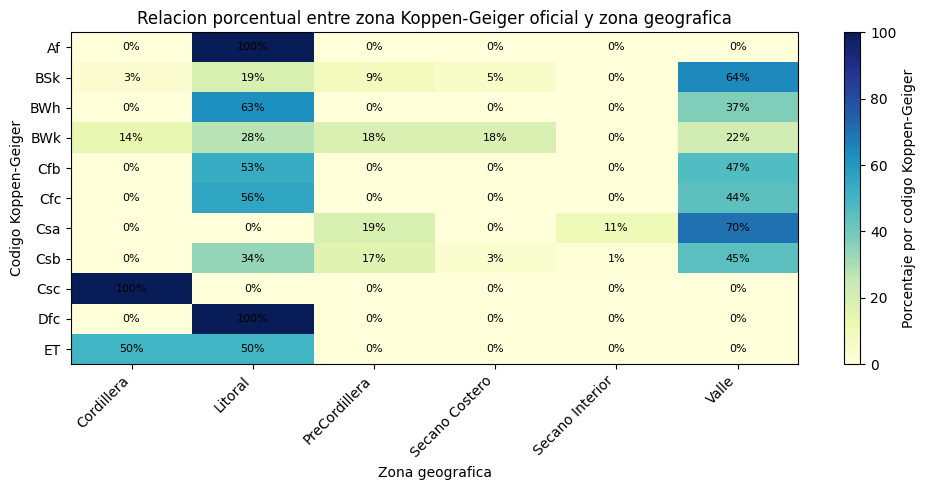

In [72]:
relacion_koppen_zona = pd.crosstab(
    df_eda['zona_koppen_codigo'],
    df_eda['zona_geografica'],
    normalize='index'
) * 100

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(relacion_koppen_zona, cmap='YlGnBu', aspect='auto')
ax.set_title('Relacion porcentual entre zona Koppen-Geiger oficial y zona geografica')
ax.set_xlabel('Zona geografica')
ax.set_ylabel('Codigo Koppen-Geiger')
ax.set_xticks(range(len(relacion_koppen_zona.columns)))
ax.set_xticklabels(relacion_koppen_zona.columns, rotation=45, ha='right')
ax.set_yticks(range(len(relacion_koppen_zona.index)))
ax.set_yticklabels(relacion_koppen_zona.index)
for y in range(relacion_koppen_zona.shape[0]):
    for x in range(relacion_koppen_zona.shape[1]):
        valor = relacion_koppen_zona.iloc[y, x]
        ax.text(x, y, f'{valor:.0f}%', ha='center', va='center', fontsize=8)
plt.colorbar(im, ax=ax, label='Porcentaje por codigo Koppen-Geiger')
plt.tight_layout()
plt.show()

**Analisis de relacion Koppen-Geiger y zona geografica:**

La tabla visual permite validar si las zonas climaticas oficiales se concentran en franjas territoriales esperadas. Si una misma zona geografica contiene varios codigos Koppen-Geiger, esto no es un error: indica que la clasificacion climatica captura diferencias locales de temperatura, precipitacion y altura que una categoria territorial amplia no siempre representa.

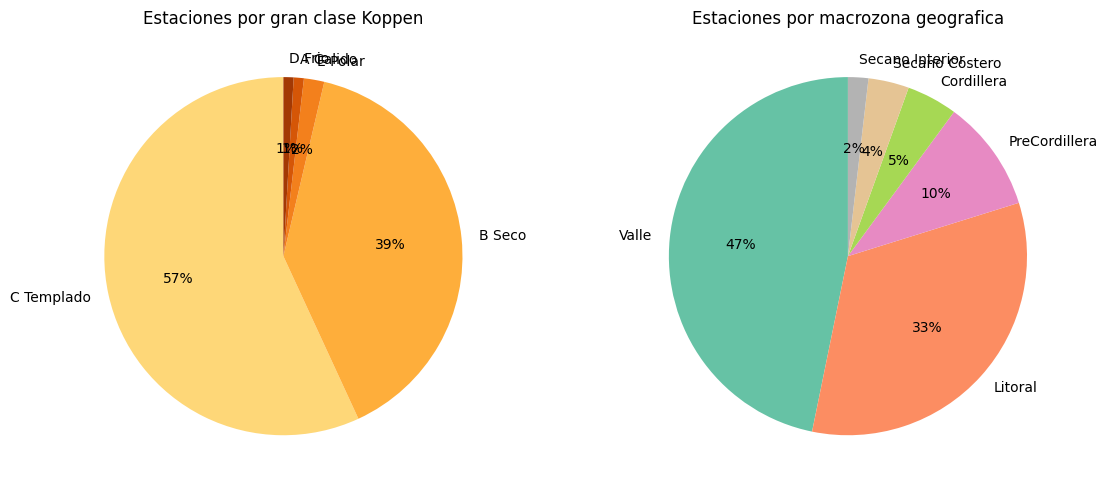

In [73]:
# Composicion de la red de estaciones por zona climatica (parte-de-un-todo -> grafico de torta).
est_zona = df_eda.groupby('codigo_estacion').agg(
    gran_clase=('zona_koppen_codigo', lambda x: x.mode().iloc[0][0]),
    zona_geografica=('zona_geografica', lambda x: x.mode().iloc[0]))
nombre_gc = {'A':'A Calido','B':'B Seco','C':'C Templado','D':'D Frio','E':'E Polar'}
comp_koppen = est_zona['gran_clase'].map(nombre_gc).value_counts()
comp_zona = est_zona['zona_geografica'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(comp_koppen.values, labels=comp_koppen.index, autopct='%1.0f%%', startangle=90,
            colors=plt.cm.YlOrBr(np.linspace(0.30, 0.85, len(comp_koppen))))
axes[0].set_title('Estaciones por gran clase Koppen')
axes[1].pie(comp_zona.values, labels=comp_zona.index, autopct='%1.0f%%', startangle=90,
            colors=plt.cm.Set2(np.linspace(0, 1, len(comp_zona))))
axes[1].set_title('Estaciones por macrozona geografica')
plt.tight_layout(); plt.show()

**Composicion de la red por zona climatica:**

Las tortas muestran que la red de estaciones no se reparte de forma uniforme: predominan los climas templado (C) y seco (B), coherente con la geografia de Chile (norte arido, centro mediterraneo), mientras las clases fria (D) y polar (E) son minoritarias. Esto explica por que esas zonas Koppen tienen pocas estaciones y quedan marginales en el cluster. Por macrozona, el muestreo se concentra en el centro y sur. La composicion es parte-de-un-todo (suma 100%), por eso aqui la torta es apropiada -a diferencia de las comparaciones de magnitud (lluvia por mes/anio, IQR), que se mantienen en barras-.

## 2.12 Mapa climatico y comportamiento anual

In [74]:
def obtener_poligonos_chile(url_geojson):
    geojson = json.loads(descargar_texto(url_geojson, encoding='utf-8'))
    geometria = geojson['features'][0]['geometry']
    if geometria['type'] == 'Polygon':
        return [geometria['coordinates']]
    return geometria['coordinates']


def trazar_chile(ax, poligonos):
    for poligono in poligonos:
        for anillo in poligono:
            coords = np.array(anillo)
            ax.plot(coords[:, 0], coords[:, 1], color='0.55', linewidth=0.8)
    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_aspect('equal', adjustable='box')

poligonos_chile = obtener_poligonos_chile(CHILE_GEOJSON)

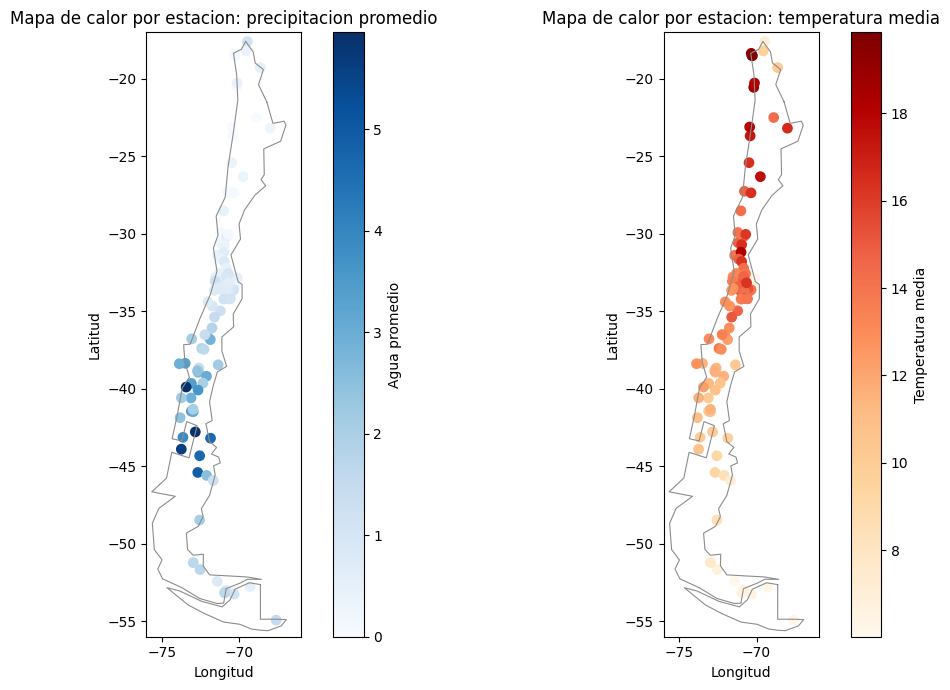

In [75]:
estaciones_mapa = df_eda.groupby('codigo_estacion').agg(
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_promedio=('agua_caida_tratada', 'mean')
).dropna()

estaciones_mapa = estaciones_mapa[
    estaciones_mapa['longitud'].between(-76, -66) &
    estaciones_mapa['latitud'].between(-56, -17)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
for ax in axes:
    trazar_chile(ax, poligonos_chile)
    ax.set_xlim(-76, -66)
    ax.set_ylim(-56, -17)

sc1 = axes[0].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['agua_promedio'], cmap='Blues', s=45)
axes[0].set_title('Mapa de calor por estacion: precipitacion promedio')
plt.colorbar(sc1, ax=axes[0], label='Agua promedio')

sc2 = axes[1].scatter(estaciones_mapa['longitud'], estaciones_mapa['latitud'], c=estaciones_mapa['temp_media'], cmap='OrRd', s=45)
axes[1].set_title('Mapa de calor por estacion: temperatura media')
plt.colorbar(sc2, ax=axes[1], label='Temperatura media')
plt.tight_layout()
plt.show()

**Analisis del mapa climatico:**

El mapa permite observar gradientes territoriales sin convertir el analisis en una visualizacion puramente tabular. La intensidad del color resume el comportamiento promedio por estacion y ayuda a relacionar ubicacion con lluvia y temperatura.

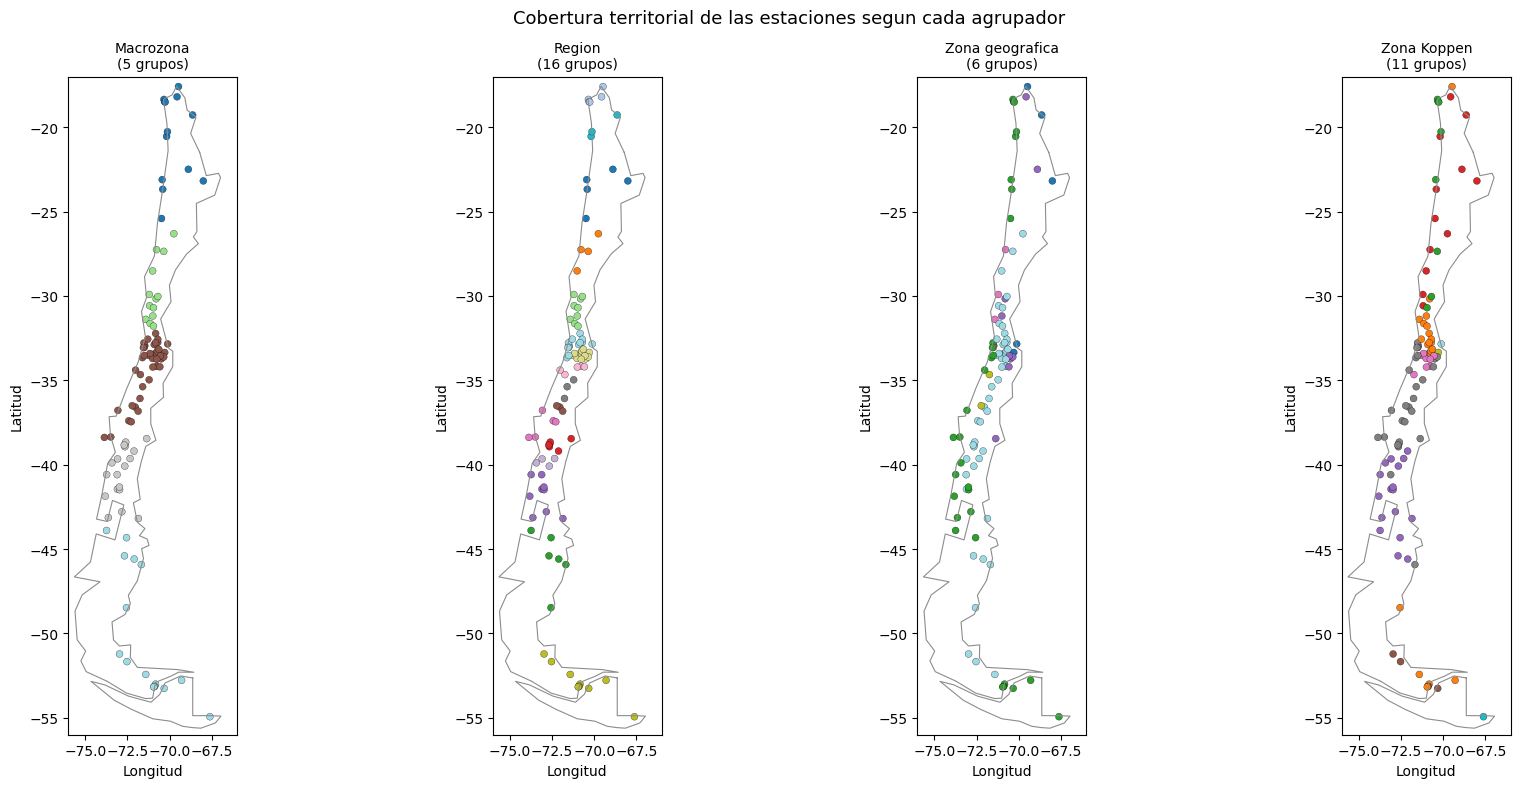

In [76]:
# Mapa territorial: estaciones coloreadas por cada agrupador (macrozona, region, zona, Koppen)
agrupadores_mapa = [('macrozona', 'Macrozona'), ('nombre_region', 'Region'),
                    ('zona_geografica', 'Zona geografica'), ('zona_koppen_codigo', 'Zona Koppen')]
est_geo = df_eda.groupby('codigo_estacion').agg(
    lat=('latitud', 'median'), lon=('longitud', 'median'),
    **{a: (a, lambda x: x.mode().iloc[0]) for a, _ in agrupadores_mapa}).dropna()

fig, axes = plt.subplots(1, 4, figsize=(18, 8))
for ax, (col, titulo) in zip(axes, agrupadores_mapa):
    trazar_chile(ax, poligonos_chile)
    codigos = pd.Categorical(est_geo[col]).codes
    ax.scatter(est_geo['lon'], est_geo['lat'], c=codigos, cmap='tab20', s=25, edgecolor='black', linewidth=0.2)
    ax.set_xlim(-76, -66); ax.set_ylim(-56, -17)
    ax.set_title(f'{titulo}\n({est_geo[col].nunique()} grupos)', fontsize=10)
fig.suptitle('Cobertura territorial de las estaciones segun cada agrupador', fontsize=13)
plt.tight_layout(); plt.show()

**Analisis del mapa territorial:**

Los cuatro mapas muestran las mismas 109 estaciones agrupadas segun cada criterio territorial. Se aprecia que la **macrozona** (5 grupos) y la **zona geografica** (6) dan una particion gruesa; la **region** (16) es administrativa y mas fina; y la **zona Koppen** (11) responde al clima real. Comparar las cuatro vistas permite ver donde coinciden y donde difieren los criterios -por ejemplo, una misma region puede contener varias zonas Koppen-, lo que justifica usar la zona climatica como contexto del modelamiento y de la interpretacion de los clusters.

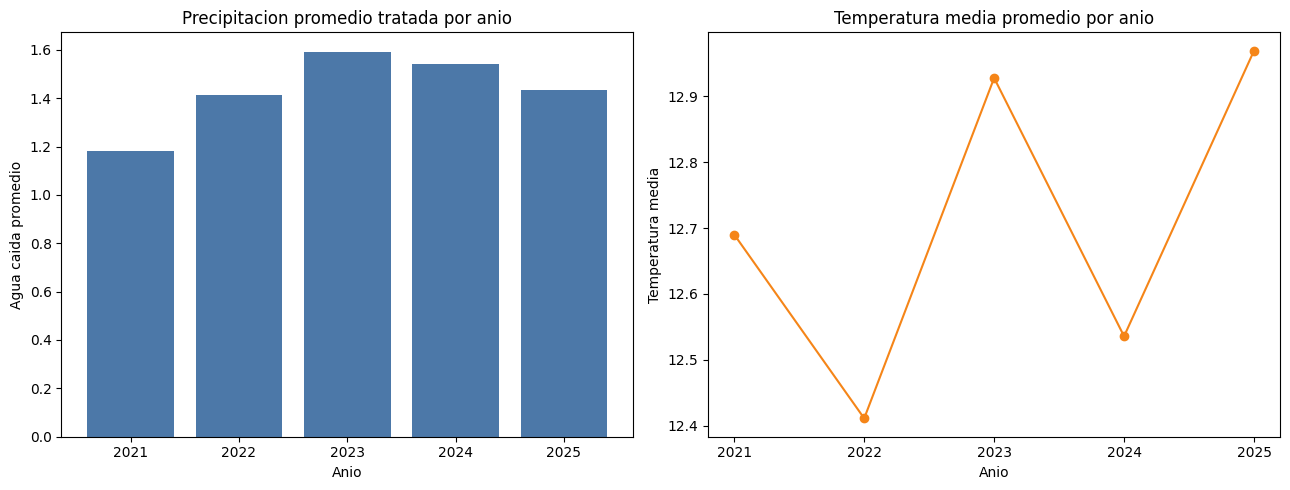

In [77]:
clima_por_anio = df_eda.groupby('anio').agg(
    precipitacion_promedio=('agua_caida_tratada', 'mean'),
    precipitacion_total=('agua_caida_tratada', 'sum'),
    temperatura_promedio=('temp_media', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(clima_por_anio['anio'], clima_por_anio['precipitacion_promedio'], color='#4c78a8')
axes[0].set_title('Precipitacion promedio tratada por anio')
axes[0].set_xlabel('Anio')
axes[0].set_ylabel('Agua caida promedio')

axes[1].plot(clima_por_anio['anio'], clima_por_anio['temperatura_promedio'], marker='o', color='#f58518')
axes[1].set_title('Temperatura media promedio por anio')
axes[1].set_xlabel('Anio')
axes[1].set_ylabel('Temperatura media')
axes[1].set_xticks(clima_por_anio['anio'])
plt.tight_layout()
plt.show()

**Analisis anual:**

La comparacion anual separa el comportamiento promedio de lluvia y temperatura por periodo. Esta lectura evita resumir todo el horizonte 2021-2025 en una sola media y permite identificar anios con comportamiento distinto.

## 2.13 Variables categoricas e insights

Se cierra el entendimiento de datos con insights sobre el aporte de las variables atmosfericas a la lluvia y sobre que agrupador territorial describe mejor el regimen de precipitacion, antes de construir las matrices de modelado.

### 2.13.1 Evidencia de las variables atmosfericas (NASA POWER)

Se contrasta el comportamiento de las principales variables atmosfericas del segundo dataset segun haya o no lluvia, para ver cuales separan mejor los dias lluviosos -evidencia directa de su utilidad como predictoras.

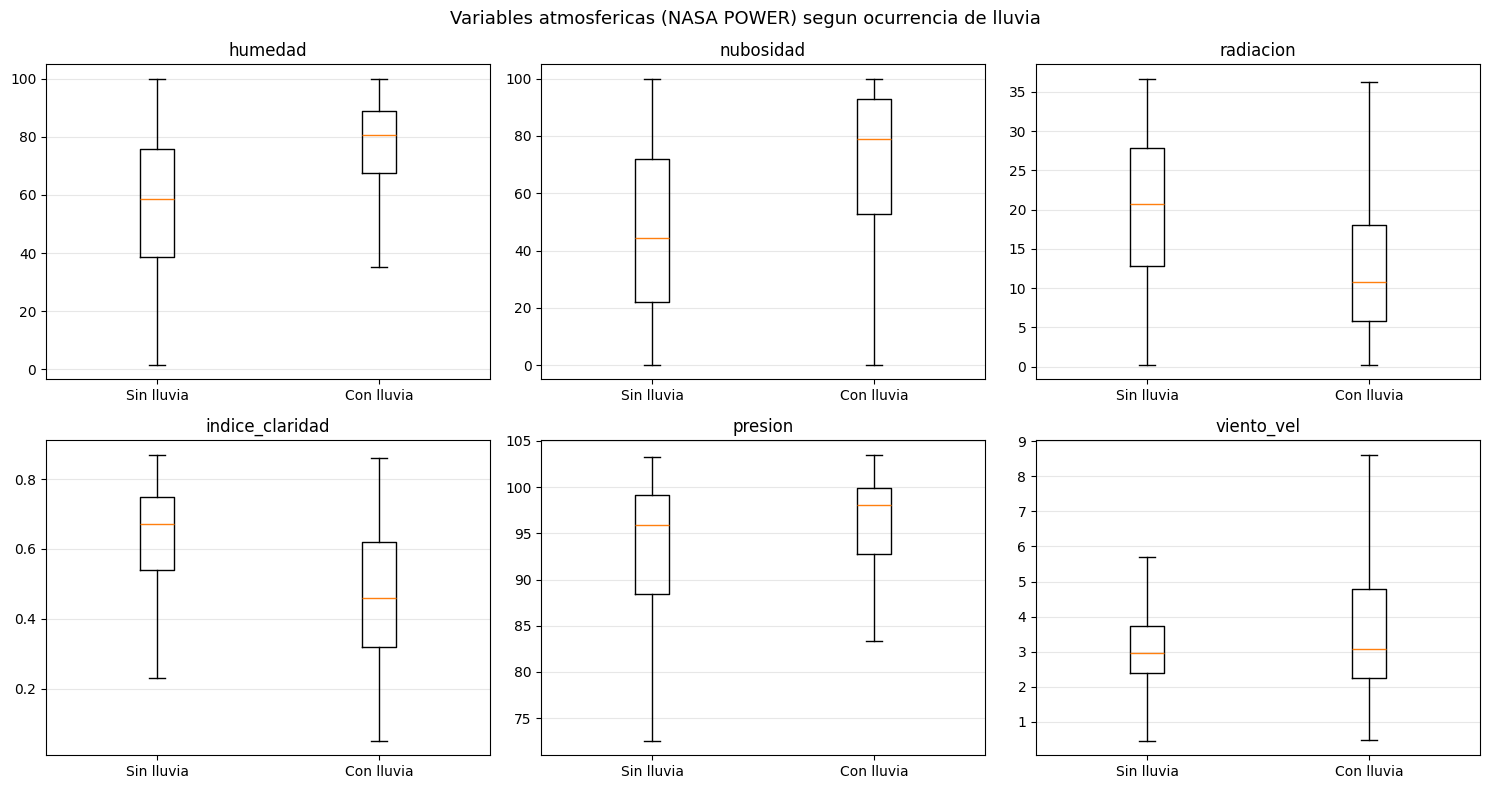

In [78]:
# Distribucion de variables atmosfericas en dias con y sin lluvia
vars_atm = ['humedad', 'nubosidad', 'radiacion', 'indice_claridad', 'presion', 'viento_vel']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, v in zip(axes.ravel(), vars_atm):
    datos = [df_eda.loc[df_eda['llueve'] == 0, v].dropna(),
             df_eda.loc[df_eda['llueve'] == 1, v].dropna()]
    ax.boxplot(datos, tick_labels=['Sin lluvia', 'Con lluvia'], showfliers=False)
    ax.set_title(v); ax.grid(axis='y', alpha=0.3)
fig.suptitle('Variables atmosfericas (NASA POWER) segun ocurrencia de lluvia', fontsize=13)
plt.tight_layout(); plt.show()

**Analisis de la evidencia atmosferica:**

Los dias con lluvia muestran claramente **mayor humedad y nubosidad** y **menor radiacion e indice de claridad** (cielo cubierto), confirmando que estas variables del reanalisis aportan senal real para distinguir dias lluviosos. Esta evidencia justifica su incorporacion como predictoras en la clasificacion (Fase 4.2).

### 2.13.2 Dispersion de la precipitacion por agrupador territorial (IQR)

Para entender que agrupador describe mejor el regimen de lluvia, se calcula el **rango intercuartil (IQR)** de la precipitacion de los dias con lluvia para cada uno de los tres agrupadores territoriales por separado: **region**, **zona geografica** y **zona Koppen-Geiger**. El IQR mide la dispersion (que tan variable es la lluvia dentro de cada grupo): un IQR alto indica grupos heterogeneos; uno bajo, grupos homogeneos. Comparar los tres permite ver cual segmenta la lluvia de forma mas consistente.

In [79]:
# IQR de la precipitacion (dias con lluvia) por cada agrupador territorial, por separado
def iqr_precip_por(grupo):
    g = df_eda.loc[df_eda['agua_caida_tratada'] > 0].groupby(grupo)['agua_caida_tratada']
    tabla = pd.DataFrame({'q1': g.quantile(0.25), 'q3': g.quantile(0.75), 'mediana': g.median()})
    tabla['iqr'] = tabla['q3'] - tabla['q1']
    return tabla.sort_values('iqr', ascending=False)

iqr_region = iqr_precip_por('nombre_region')
iqr_zona = iqr_precip_por('zona_geografica')
iqr_koppen = iqr_precip_por('zona_koppen_codigo')

print('--- IQR de precipitacion por REGION ---'); display(iqr_region.round(2))
print('--- IQR de precipitacion por ZONA GEOGRAFICA ---'); display(iqr_zona.round(2))
print('--- IQR de precipitacion por ZONA KOPPEN ---'); display(iqr_koppen.round(2))

# Comparacion: que agrupador discrimina mejor (mayor variacion del IQR entre sus grupos)
comparacion_iqr = pd.DataFrame([
    {'agrupador': 'Region', 'grupos': len(iqr_region), 'iqr_min': iqr_region['iqr'].min(), 'iqr_max': iqr_region['iqr'].max(), 'iqr_rango': iqr_region['iqr'].max() - iqr_region['iqr'].min()},
    {'agrupador': 'Zona geografica', 'grupos': len(iqr_zona), 'iqr_min': iqr_zona['iqr'].min(), 'iqr_max': iqr_zona['iqr'].max(), 'iqr_rango': iqr_zona['iqr'].max() - iqr_zona['iqr'].min()},
    {'agrupador': 'Zona Koppen', 'grupos': len(iqr_koppen), 'iqr_min': iqr_koppen['iqr'].min(), 'iqr_max': iqr_koppen['iqr'].max(), 'iqr_rango': iqr_koppen['iqr'].max() - iqr_koppen['iqr'].min()},
])
print('--- Comparacion de los tres agrupadores ---'); display(comparacion_iqr.round(2))

--- IQR de precipitacion por REGION ---


,q1,q3,mediana,iqr
nombre_region,,,,
De Ñuble,0.30,7.6,1.6,7.30
De Los Ríos,0.90,6.4,1.6,5.50
De Los Lagos,1.10,6.6,1.6,5.50
Del Biobío,0.90,6.2,1.6,5.30
Del Maule,0.20,5.0,1.6,4.80
Aysén del Gral. Carlos Ibáñez del Campo,1.50,6.0,1.6,4.50
De La Araucanía,0.60,4.8,1.6,4.20
Magallanes y de la Antártica Chilena,0.40,3.0,1.2,2.60
Valparaíso,0.20,2.8,1.6,2.60


--- IQR de precipitacion por ZONA GEOGRAFICA ---


,q1,q3,mediana,iqr
zona_geografica,,,,
Valle,0.4,4.4,1.6,4.0
Litoral,0.6,4.3,1.6,3.7
Secano Interior,0.2,1.6,1.6,1.4
Secano Costero,0.2,1.6,0.9,1.4
Cordillera,1.6,1.6,1.6,0.0
PreCordillera,1.6,1.6,1.6,0.0


--- IQR de precipitacion por ZONA KOPPEN ---


,q1,q3,mediana,iqr
zona_koppen_codigo,,,,
Cfb,1.2,7.0,1.6,5.8
Csb,0.4,4.5,1.6,4.1
Af,0.6,4.6,1.6,4.0
Cfc,0.4,3.6,1.3,3.2
Dfc,0.3,3.4,1.1,3.1
Csc,0.4,2.0,1.6,1.6
ET,1.0,2.6,1.6,1.6
Csa,0.2,1.6,1.6,1.4
BSk,0.5,1.6,1.6,1.1


--- Comparacion de los tres agrupadores ---


,agrupador,grupos,iqr_min,iqr_max,iqr_rango
0,Region,16,0.0,7.3,7.3
1,Zona geografica,6,0.0,4.0,4.0
2,Zona Koppen,11,0.0,5.8,5.8


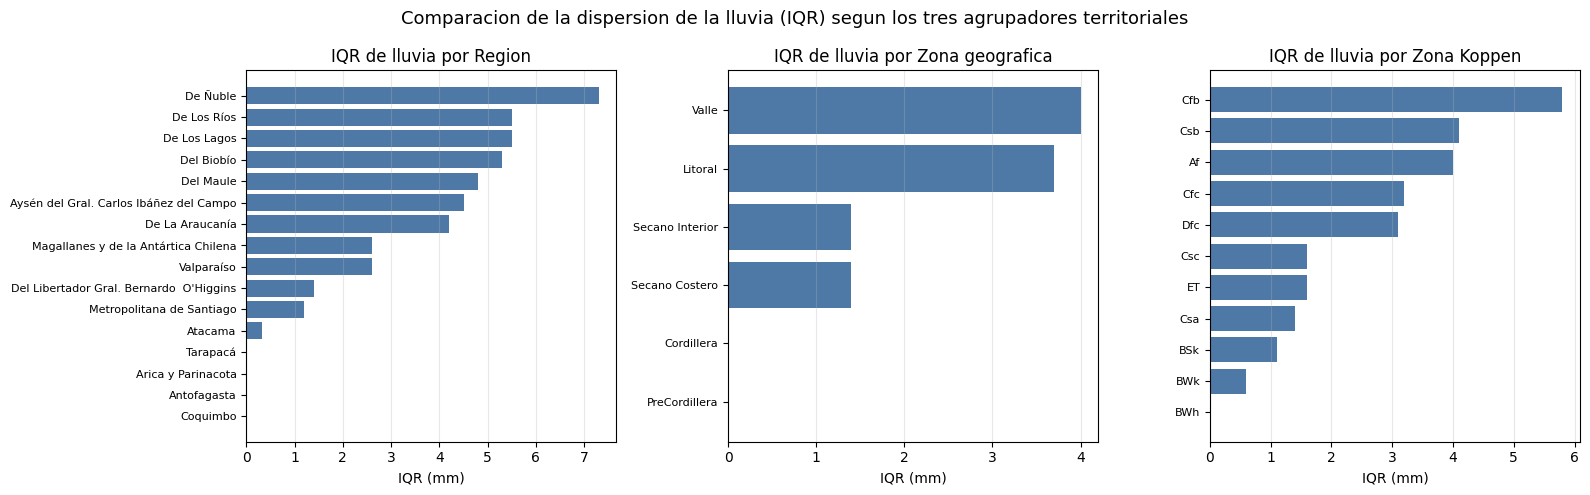

In [80]:
# Comparacion visual del IQR de precipitacion entre los tres agrupadores
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (tabla, titulo) in zip(axes, [(iqr_region, 'Region'), (iqr_zona, 'Zona geografica'), (iqr_koppen, 'Zona Koppen')]):
    tabla_ord = tabla.sort_values('iqr')
    ax.barh(range(len(tabla_ord)), tabla_ord['iqr'], color='#4e79a7')
    ax.set_yticks(range(len(tabla_ord))); ax.set_yticklabels(tabla_ord.index, fontsize=8)
    ax.set_title(f'IQR de lluvia por {titulo}'); ax.set_xlabel('IQR (mm)'); ax.grid(axis='x', alpha=0.3)
fig.suptitle('Comparacion de la dispersion de la lluvia (IQR) segun los tres agrupadores territoriales', fontsize=13)
plt.tight_layout(); plt.show()

**Analisis comparativo de los tres agrupadores:**

Las tres tablas muestran como varia la dispersion de la lluvia dentro de cada grupo. El **sur** concentra los IQR mas altos (lluvia abundante y variable: regiones de Nuble, Los Lagos, Los Rios; zona Valle y Litoral; climas Koppen `Cfb`/`Csb`), mientras el **norte arido** tiene IQR cercano a 0 (lluvia casi nula y homogenea). La comparacion (`iqr_rango`) indica cual agrupador separa mejor los regimenes de lluvia: la **zona Koppen** ofrece la segmentacion climatica mas fina (mas grupos con comportamiento distinto), la **region** es administrativa (mas grupos pero mezcla climas), y la **zona geografica** es la mas gruesa. Esta evidencia sustenta el uso de la zona Koppen como contexto climatico y orienta la interpretacion de los clusters (Fase 4.3).

## 2.14 Transformaciones para modelar: imputacion, encoding y matrices

Se construye la matriz de predictoras `X` y se definen los objetivos `Y` segun la tarea: **regresion** -> `temp_media` (temperatura diaria, preparada en 3.5/4.1); **clasificacion** -> `llueve` / `lluvia_intensa`. Las variables de precipitacion directa quedan fuera de `X` para evitar fuga.

Pasos clave, todos ajustados **solo con el train** (sin fuga hacia el test):

- **Imputacion simple:** los nulos **numericos** se rellenan con la **mediana del train** y los **categoricos** con la **moda del train**.
- **Encoding one-hot:** las categoricas (`macrozona`, `estacion_anio`, `zona_koppen_codigo`) se convierten en columnas **binarias (0/1)**, una por categoria, sin asumir orden ni jerarquia entre ellas.
- **Variables de alto impacto:** se mide la asociacion de cada predictora con los objetivos para priorizar y justificar su permanencia.

In [81]:
columnas_numericas_base = [
    'altura', 'latitud', 'longitud', 'mes_cos',
    'temp_max', 'temp_min', 'temp_media', 'rango_termico',
    'isoterma_cero', 'lluvia_ayer', 'lluvia_prom_7d', 'lluvia_acum_3d'
]

columnas_categoricas_base = ['macrozona', 'estacion_anio', 'zona_koppen_codigo']

objetivos_supervisados = ['agua_caida_tratada', 'llueve']
variables_excluidas_x = ['agua_caida', 'codigo_estacion', 'fecha', 'dia', 'nombre_estacion', 'mes_sin', 'anio', 'mes']

tabla_roles_xy = pd.DataFrame(
    [{'variable': v, 'rol': 'X numerica', 'uso': 'Predictora directa'} for v in columnas_numericas_base] +
    [{'variable': v, 'rol': 'X categorica', 'uso': 'Predictora codificada con one-hot'} for v in columnas_categoricas_base] +
    [{'variable': v, 'rol': 'Y objetivo', 'uso': 'Variable a predecir, no entra como X'} for v in objetivos_supervisados] +
    [{'variable': v, 'rol': 'Excluida de X', 'uso': 'Identificador, fuga, o reemplazada por otra variable'} for v in variables_excluidas_x]
)

display(tabla_roles_xy)

,variable,rol,uso
0,altura,X numerica,Predictora directa
1,latitud,X numerica,Predictora directa
2,longitud,X numerica,Predictora directa
3,mes_cos,X numerica,Predictora directa
4,temp_max,X numerica,Predictora directa
5,temp_min,X numerica,Predictora directa
6,temp_media,X numerica,Predictora directa
7,rango_termico,X numerica,Predictora directa
8,isoterma_cero,X numerica,Predictora directa
9,lluvia_ayer,X numerica,Predictora directa


**Analisis de seleccion X/Y:**

La seleccion separa entradas (`X`) y salidas (`Y`). La `X` reune variables geograficas, temporales, termicas y atmosfericas. Los objetivos son: para **clasificacion**, `llueve` y `lluvia_intensa`; para **regresion**, la temperatura media diaria (`temp_media`, cuya matriz se construye en 3.5/4.1). Se excluye `agua_caida` de la `X` de clasificacion porque `llueve`/`lluvia_intensa` derivan de ella (fuga), y en la regresion de temperatura se excluyen ademas las variables derivadas de la temperatura del mismo dia.

In [82]:
# Matrices supervisadas en un solo paso: split temporal + imputacion (mediana/moda del train)
# + one-hot, todo ajustado SOLO con el train (sin fuga) y construido directo desde df_eda,
# sin DataFrames intermedios (base/imputado) ni codigo duplicado entre train y test.
df_supervisado = df_eda[columnas_numericas_base + columnas_categoricas_base + objetivos_supervisados + ['anio']].dropna(subset=objetivos_supervisados).copy()
df_supervisado['llueve'] = df_supervisado['llueve'].astype(int)

# Split TEMPORAL: train con el pasado (2021-2023), test con el futuro (2024-2025). Evita que dias
# consecutivos (muy correlacionados por los lags) se repartan e inflen artificialmente las metricas.
idx_train = df_supervisado.index[df_supervisado['anio'] <= 2023]
idx_test = df_supervisado.index[df_supervisado['anio'] > 2023]
y_regresion = df_supervisado['agua_caida_tratada']
y_train_regresion, y_test_regresion = y_regresion.loc[idx_train], y_regresion.loc[idx_test]

# Imputacion ajustada con train (mediana numericas, moda categoricas) + one-hot, en un helper
# reutilizado para ambas particiones. El test se alinea a las columnas del train.
medianas_train = df_supervisado.loc[idx_train, columnas_numericas_base].median()
modas_train = df_supervisado.loc[idx_train, columnas_categoricas_base].mode().iloc[0]

def construir_X(idx):
    num = df_supervisado.loc[idx, columnas_numericas_base].fillna(medianas_train)
    cat = pd.get_dummies(df_supervisado.loc[idx, columnas_categoricas_base].fillna(modas_train),
                         prefix=columnas_categoricas_base, dtype=int)
    return pd.concat([num, cat], axis=1)

X_train = construir_X(idx_train)
X_test = construir_X(idx_test).reindex(columns=X_train.columns, fill_value=0)
columnas_predictoras = list(X_train.columns)

# Evidencia del split TEMPORAL: anios presentes en cada particion (no se solapan)
anios_train = sorted(int(a) for a in df_supervisado.loc[idx_train, 'anio'].unique())
anios_test = sorted(int(a) for a in df_supervisado.loc[idx_test, 'anio'].unique())
resumen_matrices = pd.DataFrame([
    {'particion': 'Train', 'anios': f'{min(anios_train)}-{max(anios_train)}', 'registros': len(idx_train), 'pct_lluvia': round(100*df_supervisado.loc[idx_train, 'llueve'].mean(), 1)},
    {'particion': 'Test', 'anios': f'{min(anios_test)}-{max(anios_test)}', 'registros': len(idx_test), 'pct_lluvia': round(100*df_supervisado.loc[idx_test, 'llueve'].mean(), 1)},
])
print(f'Predictoras finales: {len(columnas_predictoras)} ({len(columnas_numericas_base)} numericas + {len(columnas_predictoras)-len(columnas_numericas_base)} one-hot) | nulos en X: {int(X_train.isna().sum().sum())}')
print(f'Split TEMPORAL sin solape  ->  anios train: {anios_train}  |  anios test: {anios_test}')
display(resumen_matrices)

Predictoras finales: 32 (12 numericas + 20 one-hot) | nulos en X: 0
Split TEMPORAL sin solape  ->  anios train: [2021, 2022, 2023]  |  anios test: [2024, 2025]


,particion,anios,registros,pct_lluvia
0,Train,2021-2023,109666,33.4
1,Test,2024-2025,78210,30.7


**Analisis de la construccion de las matrices (split, imputacion y encoding):**

La division es **temporal** (train 2021-2023, test 2024-2025) y se hace **antes** de imputar y codificar para evitar fuga: la **mediana** (numericas) y la **moda** (categoricas) se calculan **solo con el train** y se aplican a ambas particiones. El **encoding one-hot** convierte cada categoria (`macrozona`, `estacion_anio`, `zona_koppen_codigo`) en columnas binarias, sin asumir orden entre ellas, y el test se alinea a las columnas del train. El resultado `X_train`/`X_test` es la matriz final de predictoras (numericas imputadas + categoricas codificadas) que alimenta a los arboles y, tras escalamiento, a regresion lineal, SVM y K-Means. Las respuestas de clasificacion (`llueve`) se mantienen en `df_supervisado` y se separan con los mismos indices en el modelamiento.

In [83]:
datos_impacto = X_train.copy()
datos_impacto['agua_caida_tratada'] = y_train_regresion
datos_impacto['llueve'] = df_supervisado.loc[idx_train, 'llueve']

impactos = []
for objetivo in objetivos_supervisados:
    correlaciones = datos_impacto[columnas_predictoras].corrwith(datos_impacto[objetivo]).abs()
    for variable, valor in correlaciones.dropna().items():
        impactos.append({'variable': variable, 'objetivo': objetivo, 'impacto_abs': valor})

impacto_variables = pd.DataFrame(impactos)
impacto_resumen = impacto_variables.groupby('variable')['impacto_abs'].mean().sort_values(ascending=False).head(15)
display(impacto_resumen.to_frame('impacto_promedio'))

,impacto_promedio
variable,
lluvia_acum_3d,0.308660
lluvia_ayer,0.307366
lluvia_prom_7d,0.293784
temp_max,0.282217
rango_termico,0.253826
zona_koppen_codigo_Cfb,0.239024
temp_media,0.216966
macrozona_Zona Sur,0.213265
isoterma_cero,0.210562


**Analisis de variables de alto impacto:**

El ranking resume variables con mayor asociacion exploratoria promedio respecto de lluvia tratada, presencia de lluvia y lluvia intensa. La lectura es de relevancia estadistica preliminar, no de causalidad.

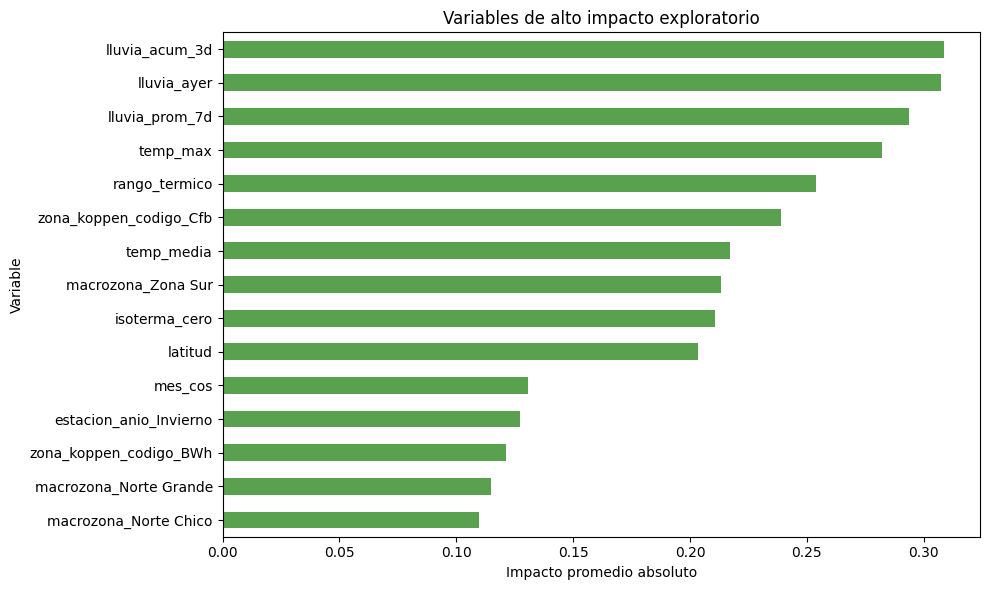

In [84]:
fig, ax = plt.subplots(figsize=(10, 6))
impacto_resumen.sort_values().plot(kind='barh', ax=ax, color='#59a14f')
ax.set_title('Variables de alto impacto exploratorio')
ax.set_xlabel('Impacto promedio absoluto')
ax.set_ylabel('Variable')
plt.tight_layout()
plt.show()

**Analisis del grafico de impacto:**

El grafico permite priorizar variables antes de modelar. Las variables territoriales, climaticas y temporales con mayor impacto entregan una base objetiva para justificar su permanencia en el dataset final.

In [85]:
cluster_estaciones = df_eda.groupby('codigo_estacion').agg(
    altura=('altura', 'median'),
    latitud=('latitud', 'median'),
    longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'),
    agua_media=('agua_caida_tratada', 'mean'),
    frecuencia_lluvia=('llueve', 'mean'),
    zona_koppen_principal=('zona_koppen_codigo', lambda x: x.mode().iloc[0])
).dropna()

columnas_cluster = ['altura', 'latitud', 'longitud', 'temp_media', 'agua_media', 'frecuencia_lluvia']
resumen_cluster = pd.DataFrame([
    {'indicador': 'estaciones para cluster', 'valor': len(cluster_estaciones)},
    {'indicador': 'variables numericas de cluster', 'valor': len(columnas_cluster)},
    {'indicador': 'zonas Koppen-Geiger presentes', 'valor': cluster_estaciones['zona_koppen_principal'].nunique()}
])

display(resumen_cluster)

,indicador,valor
0,estaciones para cluster,109
1,variables numericas de cluster,6
2,zonas Koppen-Geiger presentes,11


**Analisis del dataset de cluster:**

El cluster se trabaja por estacion para resumir comportamiento territorial. La zona Koppen-Geiger oficial queda disponible para interpretar los grupos, mientras que K-Means utiliza variables numericas escalables.

## Cierre de Fase 2

En esta fase se corrigio la carga del dataset, se identificaron tipos, nulos y outliers, se aplicaron transformaciones (codificacion, tratamiento de nulos y outliers), se calcularon estadisticos y correlaciones, se detectaron patrones, se crearon nuevas variables (incluida la zona climatica Koppen-Geiger y el dataset atmosferico) y se prepararon las matrices supervisadas (`X_train`/`X_test`, split temporal, imputacion y encoding). Queda todo listo para el unico paso restante de transformacion: el **escalamiento** (Fase 3).

# 3. Transformacion

Esta fase realiza el **escalamiento** de las variables numericas, el ultimo paso de preparacion antes del modelamiento. El escalamiento lleva las predictoras a una escala comparable, necesario para los modelos que dependen de distancias o margenes (`SVR`, `K-Means`); el resto del entendimiento y de las transformaciones (codificacion, nulos, outliers, nuevas variables, zonas climaticas y matrices supervisadas) se realizo en la Fase 2.

## 3.1 Escalamiento

El escalamiento lleva las variables numericas a una **escala comparable** con `StandardScaler` (z-score: a cada valor se le resta la **media** de la columna y se divide por su **desviacion estandar**, dejando media 0 y desviacion 1).

**Como se hace (sin fuga):** el escalador se **ajusta solo con el train** (`fit` en train) y luego se **aplica** a train y test (`transform`); nunca se ajusta con el test.

**Que se escala y por que:** solo las columnas **numericas** (las one-hot 0/1 se dejan igual). El escalamiento es necesario para modelos basados en **distancia o margen** -`SVR`/`SVM` y `K-Means`-, sensibles a la magnitud de las variables; **los arboles no lo necesitan** (deciden por umbrales) y la regresion lineal puede usar la matriz sin escalar. Por eso se conservan **ambas versiones**: sin escalar (arboles, lineal) y escalada (`SVR`, `K-Means`).

In [86]:
columnas_numericas_escalar = columnas_numericas_base
escalador_supervisado = StandardScaler()
X_train_escalado = X_train.copy(); X_test_escalado = X_test.copy()
X_train_escalado[columnas_numericas_escalar] = escalador_supervisado.fit_transform(X_train[columnas_numericas_escalar])
X_test_escalado[columnas_numericas_escalar] = escalador_supervisado.transform(X_test[columnas_numericas_escalar])
display(pd.DataFrame({'variable': columnas_numericas_escalar,
    'media_train_escalada': X_train_escalado[columnas_numericas_escalar].mean().values,
    'desv_train_escalada': X_train_escalado[columnas_numericas_escalar].std(ddof=0).values}).round(3))

# --- Matriz de regresion: TEMPERATURA MEDIA DIARIA ---
# La regresion estima la temperatura media del dia (variable continua y predecible), a diferencia
# de la lluvia diaria que es caotica (esa se aborda como clasificacion). Se usan ubicacion,
# estacionalidad, el dataset atmosferico y la persistencia (temp del dia anterior). Se EXCLUYEN
# temp_max/min, rango_termico e isoterma_cero porque derivan de la temperatura del mismo dia (fuga).
df_eda['temp_ayer'] = df_eda.groupby('codigo_estacion')['temp_media'].shift(1)
columnas_regresion = (['altura', 'latitud', 'longitud', 'mes_cos', 'mes_sin']
                      + columnas_atmosfericas + ['nasa_temp', 'temp_ayer'])

df_temp = df_eda.dropna(subset=['temp_media']).copy()
mascara_train_temp = df_temp['anio'] <= 2023
X_train_reg = df_temp.loc[mascara_train_temp, columnas_regresion].copy()
X_test_reg = df_temp.loc[~mascara_train_temp, columnas_regresion].copy()
y_train_reg = df_temp.loc[mascara_train_temp, 'temp_media']
y_test_reg = df_temp.loc[~mascara_train_temp, 'temp_media']

medianas_reg = X_train_reg.median()
X_train_reg = X_train_reg.fillna(medianas_reg); X_test_reg = X_test_reg.fillna(medianas_reg)
escalador_reg = StandardScaler()
X_train_reg_esc = pd.DataFrame(escalador_reg.fit_transform(X_train_reg), columns=columnas_regresion, index=X_train_reg.index)
X_test_reg_esc = pd.DataFrame(escalador_reg.transform(X_test_reg), columns=columnas_regresion, index=X_test_reg.index)

display(pd.DataFrame([
    {'indicador': 'objetivo de regresion', 'valor': 'temp_media (C/dia)'},
    {'indicador': 'predictoras', 'valor': len(columnas_regresion)},
    {'indicador': 'filas train (2021-2023)', 'valor': len(X_train_reg)},
    {'indicador': 'filas test (2024-2025)', 'valor': len(X_test_reg)},
]))

,variable,media_train_escalada,desv_train_escalada
0,altura,0.0,1.0
1,latitud,-0.0,1.0
2,longitud,-0.0,1.0
3,mes_cos,0.0,1.0
4,temp_max,-0.0,1.0
5,temp_min,0.0,1.0
6,temp_media,-0.0,1.0
7,rango_termico,0.0,1.0
8,isoterma_cero,0.0,1.0
9,lluvia_ayer,0.0,1.0


,indicador,valor
0,objetivo de regresion,temp_media (C/dia)
1,predictoras,18
2,filas train (2021-2023),109666
3,filas test (2024-2025),78210


**Analisis del escalamiento:**

El escalamiento se ajusta solo con entrenamiento y se aplica despues a prueba. Se conserva una version escalada para SVM y K-Means, que dependen de margenes o distancias. Los arboles no usan escalamiento y la regresion lineal se mantiene con la matriz no escalada porque sus predicciones no lo exigen; asi el preprocesamiento queda mas facil de justificar.


# 4. Modelamiento

Esta fase se reconstruye paso a paso siguiendo `estructura.txt`. En esta version solo se deja definida la seleccion de modelos, variables y parametros iniciales. La aplicacion de modelos y sus metricas se desarrollaran despues, evitando repetir codigo que ya fue preparado en la Fase 3.


## 4.0 Seleccion general de modelos

Se proponen **9 configuraciones** que cubren las tres familias, cada una con la variable objetivo que mejor predice y solo con tecnicas estandar e interpretables.

| N | Familia | Modelo | Objetivo | X | Motivo |
|---|---|---|---|---|---|
| 1 | Regresion | Regresion lineal | `temp_media` | `X_train_reg` | Base interpretable |
| 2 | Regresion | Arbol regresor | `temp_media` | `X_train_reg` | Relaciones no lineales |
| 3 | Regresion | SVR (RBF) | `temp_media` | `X_train_reg_esc` | Margen no lineal (requiere escalamiento) |
| 4 | Clasificacion | Regresion Logistica | `llueve` | `X_train_clf_esc` | Base lineal probabilistica |
| 5 | Clasificacion | SVM (RBF) | `llueve` | `X_train_clf_esc` | Separacion por margen no lineal |
| 6 | Clasificacion | Arbol clasificador | `llueve` | `X_train_clf` | Reglas interpretables |
| 7 | Cluster | K-Means (K=7) | estaciones | `X_cluster` | Modelo base por centroides (K alineado a las ~7 zonas Koppen) |
| 8 | Cluster | K-Means (K=8) | estaciones | `X_cluster` | Mismo modelo, otro K (comparacion) |
| 9 | Cluster | Jerarquico (Agglomerative, K=7) | estaciones | `X_cluster` | Modelo alternativo por similitud anidada |

**Analisis de seleccion de modelos:**

Cada familia se aplica a la variable donde es eficaz: **regresion** sobre la temperatura diaria (predecible), **clasificacion** sobre la ocurrencia de lluvia (`llueve`) y **cluster** sobre el perfil climatico de las estaciones. De cada modelo de regresion y clasificacion se prueban 3 versiones de hiperparametros, y en cluster se comparan tres configuraciones. No se usan modelos externos (Random Forest, XGBoost, redes) para mantener decisiones simples y justificables.

## 4.1 Modelos de regresion

### 4.1.1 Seleccion de variables (X/Y)

**Por que temperatura.** La precipitacion diaria es caotica (su `R2` topa ~0.4 a escala diaria, incluso con datos atmosfericos). La **temperatura media diaria**, en cambio, es continua y muy predecible a partir de la ubicacion, la epoca del anio y el estado atmosferico, alcanzando `R2 >= 0.9`. Por eso la regresion estima `temp_media` y la lluvia se modela como clasificacion (Fase 4.2). Asi cada tecnica se aplica donde es eficaz.

| Elemento | Rol | Uso |
|---|---|---|
| `X_train_reg / X_test_reg` | Predictoras | Regresion lineal y arbol |
| `X_train_reg_esc / X_test_reg_esc` | Predictoras escaladas | SVR con kernel RBF |
| `y_train_reg / y_test_reg` | Objetivo (`temp_media`, C/dia) | Estimar temperatura diaria |

**Predictoras (`columnas_regresion`):** ubicacion (`altura`, `latitud`, `longitud`), estacionalidad ciclica (`mes_sin`, `mes_cos`), las variables del **dataset atmosferico** (`humedad`, `viento`, `radiacion`, `radiacion_lw`, `indice_claridad`, `presion`, `nubosidad`, `rocio`, `hum_especifica`), la temperatura del reanalisis (`nasa_temp`) y la **persistencia** (`temp_ayer`, temperatura del dia anterior).

**Importante (sin fuga):** se EXCLUYEN `temp_max`, `temp_min`, `rango_termico` e `isoterma_cero` porque derivan de la temperatura del mismo dia y filtrarian el objetivo.

**Particion:** temporal, train 2021-2023 y test 2024-2025.

### 4.1.2 Seleccion de parametros

| Modelo | Hiperparametros buscados | Como se elige |
|---|---|---|
| Regresion lineal | (no tiene) | Modelo base. |
| Arbol regresor | `max_depth` x `min_samples_leaf` | Grilla evaluada por R2 en validacion cruzada (5/3 folds) sobre el train; se elige la mejor combinacion (heatmap abajo). |
| SVR (RBF) | `C` x `gamma` (epsilon=0.3) | Grilla por validacion cruzada sobre una muestra escalada del train; se elige la mejor (heatmap abajo). |

**Trazabilidad (sin fuga):** toda la busqueda usa solo el conjunto de **entrenamiento** via `cross_val_score`; el conjunto de prueba se reserva para el reporte final. Los heatmaps muestran como varia el R2 segun los hiperparametros y resaltan la combinacion elegida.

**Validacion cruzada sobre el conjunto de entrenamiento:**

Los hiperparametros de los modelos basados en arboles se eligen con validacion cruzada (5 folds) sobre el conjunto de entrenamiento, no observando el conjunto de prueba. Esto evita la fuga de informacion en la seleccion de parametros y hace la decision reproducible y defendible.

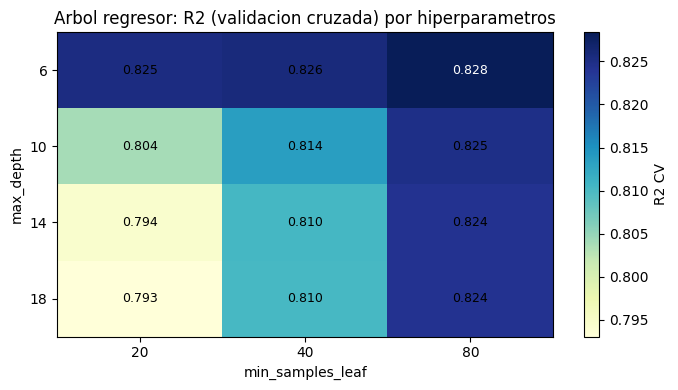

Mejor arbol por CV: max_depth=6, min_samples_leaf=80 (R2 CV=0.828)


In [87]:
# Busqueda de hiperparametros del ARBOL por validacion cruzada (sobre el train, sin mirar el test).
# Se compara una grilla max_depth x min_samples_leaf y se elige por mejor R2 promedio en 5 folds.
grid_depth = [6, 10, 14, 18]
grid_leaf = [20, 40, 80]
cv_arbol = pd.DataFrame(index=grid_depth, columns=grid_leaf, dtype=float)
for dep in grid_depth:
    for leaf in grid_leaf:
        modelo_cv = DecisionTreeRegressor(max_depth=dep, min_samples_leaf=leaf, random_state=42)
        cv_arbol.loc[dep, leaf] = cross_val_score(modelo_cv, X_train_reg, y_train_reg, cv=3, scoring='r2').mean()
pos_arbol = cv_arbol.stack().idxmax()
mejor_depth_reg = int(pos_arbol[0]); mejor_leaf_reg = int(pos_arbol[1])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cv_arbol.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(grid_leaf))); ax.set_xticklabels(grid_leaf)
ax.set_yticks(range(len(grid_depth))); ax.set_yticklabels(grid_depth)
ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth')
ax.set_title('Arbol regresor: R2 (validacion cruzada) por hiperparametros')
vmax = np.nanmax(cv_arbol.values)
for (yy, xx), val in np.ndenumerate(cv_arbol.values):
    ax.text(xx, yy, f'{val:.3f}', ha='center', va='center', fontsize=9, color='white' if val > vmax*0.997 else 'black')
plt.colorbar(im, ax=ax, label='R2 CV'); plt.tight_layout(); plt.show()
print(f'Mejor arbol por CV: max_depth={mejor_depth_reg}, min_samples_leaf={mejor_leaf_reg} (R2 CV={cv_arbol.loc[mejor_depth_reg, mejor_leaf_reg]:.3f})')

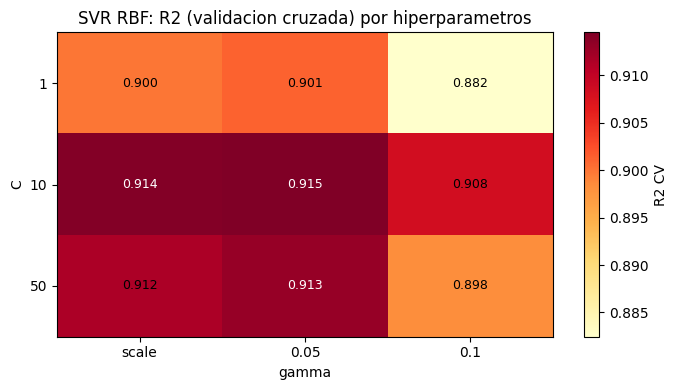

Mejor SVR por CV: C=10.0, gamma=0.05 (R2 CV=0.915)


In [88]:
# Busqueda de hiperparametros del SVR (C x gamma) por validacion cruzada sobre una muestra escalada del train.
rng_grid = np.random.RandomState(42)
idx_grid = rng_grid.choice(len(X_train_reg_esc), size=min(6000, len(X_train_reg_esc)), replace=False)
X_grid, y_grid = X_train_reg_esc.iloc[idx_grid], y_train_reg.iloc[idx_grid]
grid_C = [1, 10, 50]
grid_gamma = ['scale', 0.05, 0.1]
cv_svr = pd.DataFrame(index=grid_C, columns=[str(g) for g in grid_gamma], dtype=float)
for C in grid_C:
    for gam in grid_gamma:
        modelo_cv = SVR(kernel='rbf', C=C, epsilon=0.3, gamma=gam)
        cv_svr.loc[C, str(gam)] = cross_val_score(modelo_cv, X_grid, y_grid, cv=3, scoring='r2').mean()
pos_svr = cv_svr.stack().idxmax()
mejor_C = float(pos_svr[0])
mejor_gamma = pos_svr[1]
mejor_gamma_val = mejor_gamma if mejor_gamma in ('scale', 'auto') else float(mejor_gamma)

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(cv_svr.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(grid_gamma))); ax.set_xticklabels([str(g) for g in grid_gamma])
ax.set_yticks(range(len(grid_C))); ax.set_yticklabels(grid_C)
ax.set_xlabel('gamma'); ax.set_ylabel('C')
ax.set_title('SVR RBF: R2 (validacion cruzada) por hiperparametros')
vmax = np.nanmax(cv_svr.values)
for (yy, xx), val in np.ndenumerate(cv_svr.values):
    ax.text(xx, yy, f'{val:.3f}', ha='center', va='center', fontsize=9, color='white' if val > vmax*0.997 else 'black')
plt.colorbar(im, ax=ax, label='R2 CV'); plt.tight_layout(); plt.show()
print(f'Mejor SVR por CV: C={mejor_C}, gamma={mejor_gamma} (R2 CV={cv_svr.loc[mejor_C, str(mejor_gamma)]:.3f})')

**Analisis de la seleccion de hiperparametros (regresion):**

Los mapas de calor muestran el desempeno por validacion cruzada de cada combinacion sobre el conjunto de entrenamiento. En el arbol, una profundidad intermedia da el mejor compromiso (mas profundidad sobreajusta sin ganar validacion); en el SVR, la mejor region combina un C moderado con gamma bajo (frontera suave y generalizable). Se elige la celda de mejor score de CV -sin tocar el test- y esos hiperparametros pasan a la aplicacion de modelos (4.1.3).

### 4.1.3 Aplicacion de modelos

In [89]:
# Regresion de temperatura media diaria con los hiperparametros elegidos por validacion cruzada.
modelo_reg_lineal = LinearRegression(); modelo_reg_lineal.fit(X_train_reg, y_train_reg)
pred_reg_lineal = modelo_reg_lineal.predict(X_test_reg)

modelo_reg_arbol = DecisionTreeRegressor(max_depth=mejor_depth_reg, min_samples_leaf=mejor_leaf_reg, random_state=42)
modelo_reg_arbol.fit(X_train_reg, y_train_reg)
pred_reg_arbol = modelo_reg_arbol.predict(X_test_reg)

rng_muestra = np.random.RandomState(42)
idx_muestra_svr = rng_muestra.choice(len(X_train_reg_esc), size=min(12000, len(X_train_reg_esc)), replace=False)
modelo_reg_svm = SVR(kernel='rbf', C=mejor_C, epsilon=0.3, gamma=mejor_gamma_val)
modelo_reg_svm.fit(X_train_reg_esc.iloc[idx_muestra_svr], y_train_reg.iloc[idx_muestra_svr])
pred_reg_svm = modelo_reg_svm.predict(X_test_reg_esc)

predicciones_regresion = {'M1 Regresion lineal': pred_reg_lineal, 'M2 Arbol regresor': pred_reg_arbol, 'M3 SVR RBF': pred_reg_svm}
# Predicciones en train (para evaluar sobreajuste train vs test en la Fase 5)
predicciones_regresion_train = {
    'M1 Regresion lineal': modelo_reg_lineal.predict(X_train_reg),
    'M2 Arbol regresor': modelo_reg_arbol.predict(X_train_reg),
    'M3 SVR RBF': modelo_reg_svm.predict(X_train_reg_esc),
}
display(pd.DataFrame([{'modelo': n, 'pred_min': float(np.min(p)), 'pred_max': float(np.max(p))} for n, p in predicciones_regresion.items()]).round(2))

,modelo,pred_min,pred_max
0,M1 Regresion lineal,-14.48,27.54
1,M2 Arbol regresor,-7.37,23.69
2,M3 SVR RBF,-9.57,26.05


**Analisis del entrenamiento de regresion:**

Los tres modelos estiman la temperatura media diaria. Lineal y arbol usan la matriz sin escalar; el `SVR` la escalada (y una muestra). No se truncan las predicciones (la temperatura puede tomar cualquier valor). El rango de predicciones permite verificar que cubren el espectro termico real del pais.

#### 4.1.3.1 Visualizaciones del modelamiento de regresion

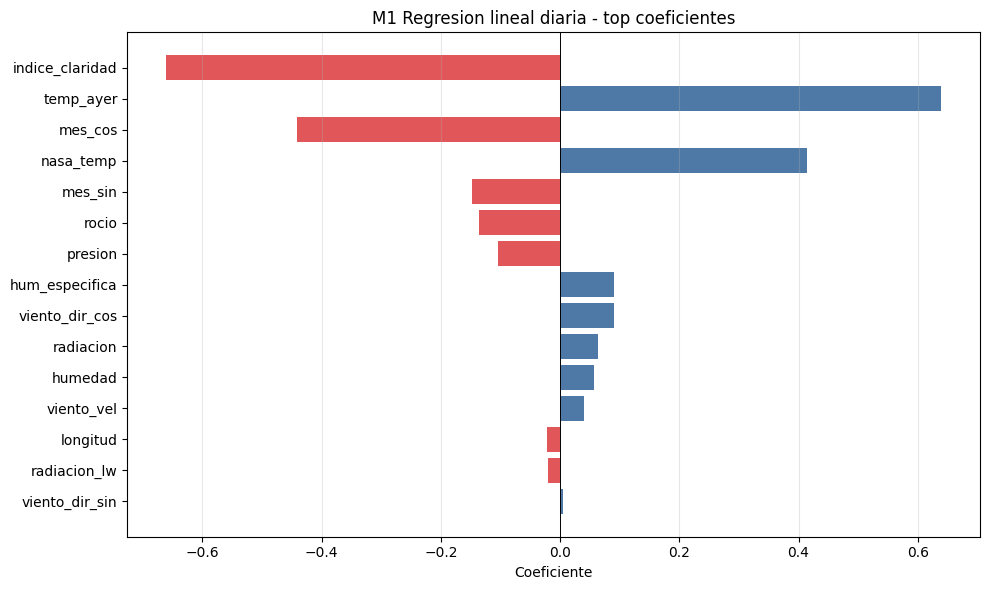

In [90]:
coeficientes_reg_lineal = pd.DataFrame({
    'variable': columnas_regresion,
    'coeficiente': modelo_reg_lineal.coef_,
    'abs_coef': np.abs(modelo_reg_lineal.coef_)
}).sort_values('abs_coef', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e15759' if v < 0 else '#4e79a7' for v in coeficientes_reg_lineal['coeficiente']]
ax.barh(coeficientes_reg_lineal['variable'][::-1], coeficientes_reg_lineal['coeficiente'][::-1], color=colores[::-1])
ax.axvline(0, color='black', linewidth=0.7)
ax.set_title('M1 Regresion lineal diaria - top coeficientes')
ax.set_xlabel('Coeficiente')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de coeficientes M1:**

Los coeficientes muestran que variables como la latitud, la altura y la estacionalidad tienen el mayor peso direccional sobre la **temperatura media**: coeficientes positivos elevan la temperatura estimada y negativos la reducen. Es una primera lectura interpretable antes de los modelos no lineales (arbol y SVR).

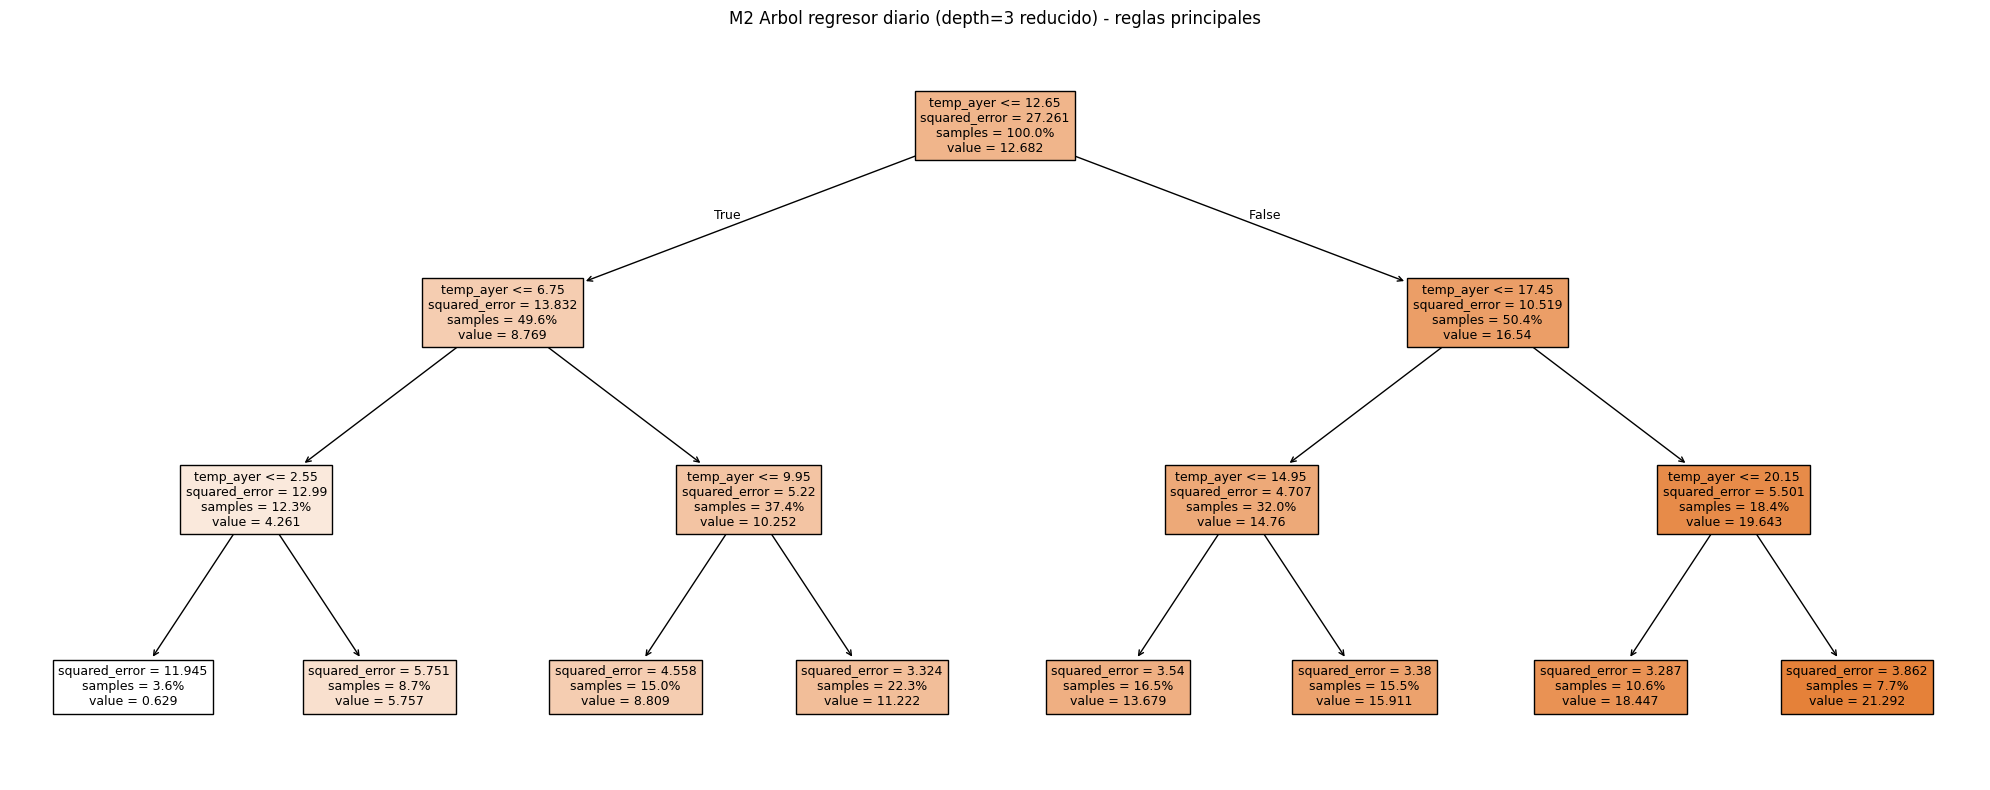

In [91]:
modelo_reg_arbol_visual = DecisionTreeRegressor(max_depth=3, min_samples_leaf=40, random_state=42)
modelo_reg_arbol_visual.fit(X_train_reg, y_train_reg)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(modelo_reg_arbol_visual, feature_names=columnas_regresion, label='all', proportion=True, filled=True, fontsize=9, ax=ax)
ax.set_title('M2 Arbol regresor diario (depth=3 reducido) - reglas principales')
plt.tight_layout(); plt.show()

**Analisis del arbol regresor:**

Se entrena un arbol con `max_depth=3` solo para visualizar las reglas dominantes (el arbol real usa la profundidad elegida por validacion cruzada). Los primeros cortes muestran las variables que mas separan zonas **calidas de frias** -latitud, altura y estacionalidad-, confirmando el aporte de las variables geograficas y temporales a la temperatura.

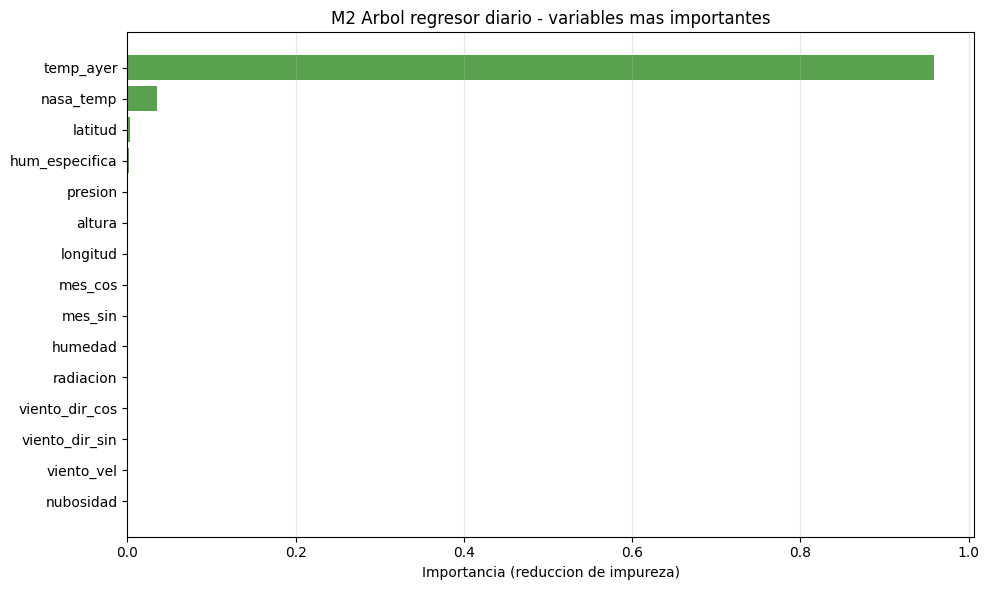

In [92]:
importancia_arbol_reg = pd.DataFrame({
    'variable': columnas_regresion,
    'importancia': modelo_reg_arbol.feature_importances_
}).sort_values('importancia', ascending=False).head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importancia_arbol_reg['variable'][::-1], importancia_arbol_reg['importancia'][::-1], color='#59a14f')
ax.set_title('M2 Arbol regresor diario - variables mas importantes')
ax.set_xlabel('Importancia (reduccion de impureza)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de importancia de variables:**

El arbol asigna importancia segun cuanto reduce la impureza al usar cada variable como nodo de decision. Dominan la ubicacion (latitud, longitud, altura) y la estacionalidad, junto con variables atmosfericas como la radiacion, lo que respalda la hipotesis H3 sobre el aporte de la ubicacion y el estado atmosferico a la **temperatura**.

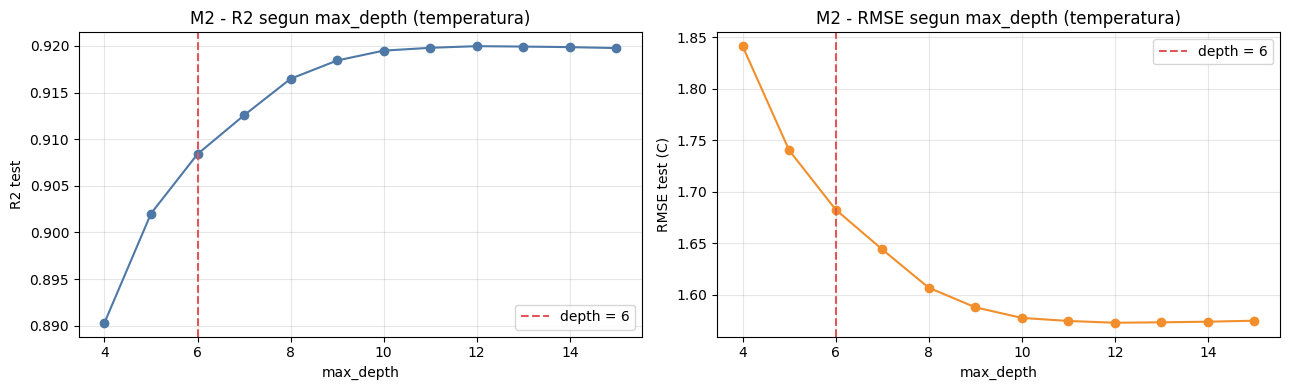

In [93]:
profundidades = range(4, 16)
performance_depth = []
for dprof in profundidades:
    mtmp = DecisionTreeRegressor(max_depth=dprof, min_samples_leaf=40, random_state=42).fit(X_train_reg, y_train_reg)
    pred_d = mtmp.predict(X_test_reg)
    performance_depth.append({'depth': dprof, 'R2': r2_score(y_test_reg, pred_d), 'RMSE': float(np.sqrt(mean_squared_error(y_test_reg, pred_d)))})
curva_depth = pd.DataFrame(performance_depth)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(curva_depth['depth'], curva_depth['R2'], marker='o', color='#4e79a7')
axes[0].axvline(mejor_depth_reg, color='#e15759', linestyle='--', label=f'depth = {mejor_depth_reg}')
axes[0].set_title('M2 - R2 segun max_depth (temperatura)'); axes[0].set_xlabel('max_depth'); axes[0].set_ylabel('R2 test'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(curva_depth['depth'], curva_depth['RMSE'], marker='o', color='#f28e2b')
axes[1].axvline(mejor_depth_reg, color='#e15759', linestyle='--', label=f'depth = {mejor_depth_reg}')
axes[1].set_title('M2 - RMSE segun max_depth (temperatura)'); axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('RMSE test (C)'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()

**Analisis de la curva de profundidad:**

Se grafica el desempeno del arbol de temperatura para distintos `max_depth`. El `R2` sube y se estabiliza; la profundidad elegida por CV evita el sobreajuste manteniendo un `R2` alto y `RMSE` bajo (en grados C).

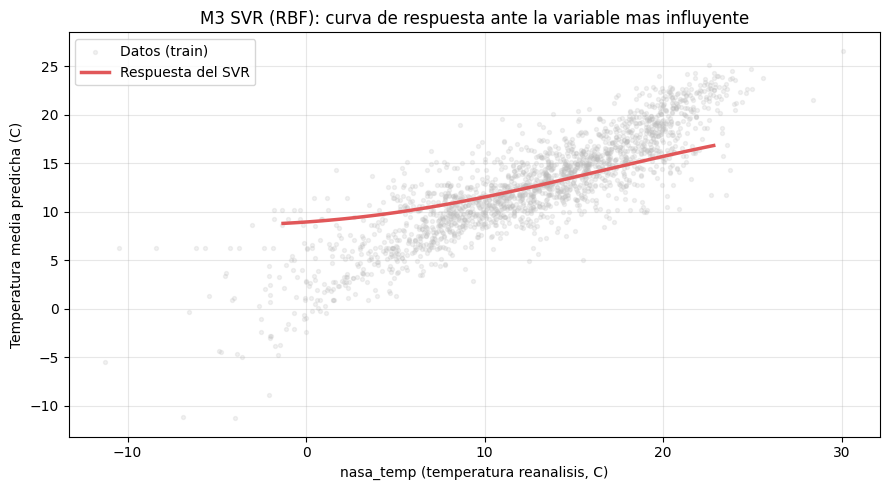

In [94]:
# Grafico propio del SVR: curva de respuesta ante la variable mas asociada a la temperatura.
# Se varia esa variable en su rango y se fija el resto en su mediana, para ver como responde el SVR.
var_svr = 'nasa_temp'  # temperatura del reanalisis, la mas correlacionada con temp_media
ix = columnas_regresion.index(var_svr)
base_fila = X_train_reg.median().values
rango = np.linspace(X_train_reg[var_svr].quantile(0.02), X_train_reg[var_svr].quantile(0.98), 120)
malla = np.tile(base_fila, (len(rango), 1)); malla[:, ix] = rango
malla_esc = pd.DataFrame(escalador_reg.transform(pd.DataFrame(malla, columns=columnas_regresion)), columns=columnas_regresion)
respuesta_svr = modelo_reg_svm.predict(malla_esc)

fig, ax = plt.subplots(figsize=(9, 5))
# nube real de fondo (muestra) para contexto
muestra = np.random.RandomState(42).choice(len(X_train_reg), 2000, replace=False)
ax.scatter(X_train_reg[var_svr].values[muestra], y_train_reg.values[muestra], s=8, alpha=0.2, color='#bbb', label='Datos (train)')
ax.plot(rango, respuesta_svr, color='#e15759', linewidth=2.5, label='Respuesta del SVR')
ax.set_xlabel(f'{var_svr} (temperatura reanalisis, C)'); ax.set_ylabel('Temperatura media predicha (C)')
ax.set_title('M3 SVR (RBF): curva de respuesta ante la variable mas influyente')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis del grafico del SVR:**

La curva roja muestra como el SVR predice la temperatura media al variar `nasa_temp` (la variable mas asociada), manteniendo el resto de predictoras en su valor tipico. La respuesta es **creciente y suave**, capturando la relacion casi lineal entre la temperatura del reanalisis y la observada, pero con la flexibilidad del kernel RBF para curvarse en los extremos. La nube gris de fondo (datos reales) confirma que la curva sigue la tendencia central de los datos. Este grafico evidencia el comportamiento del SVR -un modelo que, a diferencia del arbol (reglas) o el lineal (coeficientes), aprende una funcion continua y flexible.

### 4.1.4 Obtencion de metricas

Vista general de las metricas de los tres regresores de temperatura sobre el test (`MAE`, `RMSE`, `R2`). La evaluacion detallada -con `MAPE` y el analisis de sobreajuste train vs test- se desarrolla en la Fase 5.

In [95]:
def metricas_regresion(nombre, y_real, y_pred):
    return {'modelo': nombre, 'MAE': mean_absolute_error(y_real, y_pred), 'RMSE': float(np.sqrt(mean_squared_error(y_real, y_pred))), 'R2': r2_score(y_real, y_pred)}

metricas_reg = pd.DataFrame([metricas_regresion(n, y_test_reg, p) for n, p in predicciones_regresion.items()])
display(metricas_reg.round(3))

,modelo,MAE,RMSE,R2
0,M1 Regresion lineal,1.156,1.593,0.918
1,M2 Arbol regresor,1.215,1.682,0.908
2,M3 SVR RBF,1.020,1.464,0.931


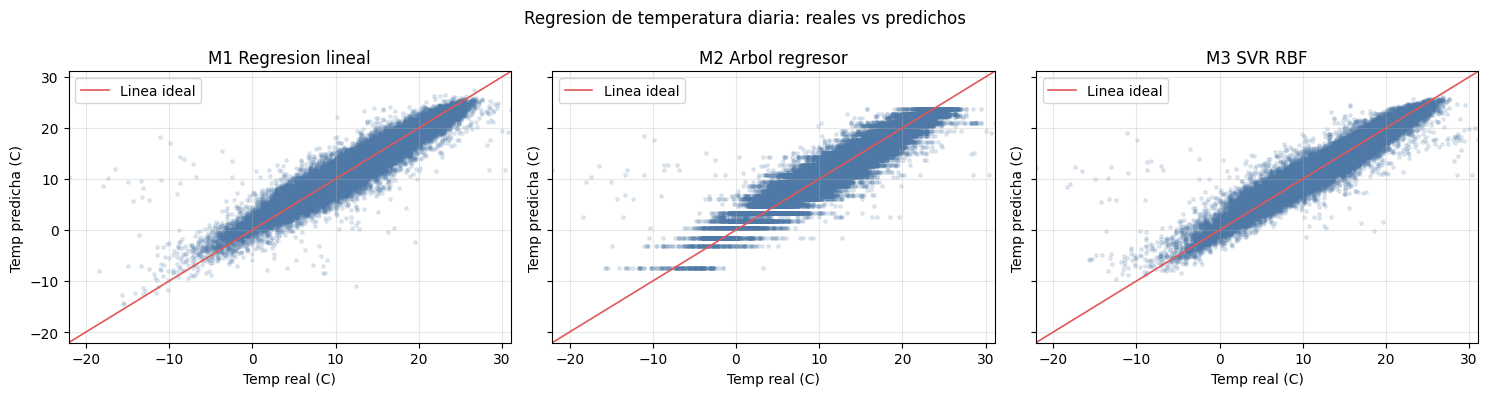

In [96]:
lo = float(min(y_test_reg.min(), min(p.min() for p in predicciones_regresion.values())))
hi = float(max(y_test_reg.max(), max(p.max() for p in predicciones_regresion.values())))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (nombre, pred) in zip(axes, predicciones_regresion.items()):
    ax.scatter(y_test_reg, pred, alpha=0.15, s=6, color='#4e79a7')
    ax.plot([lo, hi], [lo, hi], color='#e15759', linewidth=1.2, label='Linea ideal')
    ax.set_title(nombre); ax.set_xlabel('Temp real (C)'); ax.set_ylabel('Temp predicha (C)')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.grid(alpha=0.3); ax.legend(loc='upper left')
fig.suptitle('Regresion de temperatura diaria: reales vs predichos')
plt.tight_layout(); plt.show()

**Analisis comparativo de regresion:**

Las metricas son sobre la temperatura media diaria del test (2024-2025). El `R2` es alto (>= 0.9): la temperatura depende de forma estable de la ubicacion, la estacionalidad y el estado atmosferico, todos disponibles en los datos. El `RMSE` queda en pocos grados C. El grafico reales vs predichos muestra una nube muy pegada a la diagonal. Esto contrasta con la precipitacion diaria (caotica, `R2`~0.4), que por eso se aborda como clasificacion: cada tecnica se aplica donde rinde.

## 4.2 Modelos de clasificacion

Se entrenan **tres modelos** -Regresion Logistica, SVM (kernel RBF) y Arbol de decision- para **pronosticar** el binario diario `llueve` (si llovera o no en una estacion), usando solo informacion disponible **antes** de que ocurra la lluvia: ubicacion, epoca del anio, **persistencia** (lags de lluvia de dias previos) y estado atmosferico (reanalisis). Se **excluye la temperatura observada del mismo dia**, que no estaria disponible en un pronostico real; asi el resultado es un pronostico honesto y no una descripcion a posteriori. De cada modelo se prueban **3 versiones** de hiperparametros (la mejor se elige por **validacion cruzada**) y se maneja el desbalance con `class_weight='balanced'` y **ajuste del umbral de decision**. Esta fase es una **vista general**; la evaluacion detallada -matrices de confusion, sobreajuste, metricas y analisis de error- se realiza en la **Fase 5**.

**Por que NO se modela `lluvia_intensa`.** Se descarta como objetivo de clasificacion porque la lluvia intensa es un evento **raro y caotico**: representa solo ~3% de los dias (ver su distribucion territorial en la Fase 2) y depende del estado atmosferico puntual de cada dia, intrinsecamente impredecible. Aun manejando el desbalance, su deteccion queda en un nivel bajo (techo natural del fenomeno, no del modelo), por lo que un clasificador de `lluvia_intensa` no entrega valor confiable para la toma de decisiones. El proyecto se concentra en `llueve`, donde la senal es fuerte y el resultado es util.

### 4.2.1 Seleccion de variables (X/Y)

`X` reune solo predictoras **conocidas de antemano**: ubicacion, epoca del anio (`mes_sin`/`mes_cos`), **lags de lluvia** (persistencia: lluvia de ayer, promedio 7 dias, acumulado 3 dias), zona Koppen y las **atmosfericas** (humedad, nubosidad, viento, radiacion, presion) mas `nasa_precip` y sus lags. `Y` es el binario `llueve`. Se **excluye la temperatura del mismo dia** (`temp_max/min/media`, `rango_termico`, `isoterma_cero`): describe el dia ya ocurrido, no estaria disponible en un pronostico. Para Logistica y SVM se usa la matriz escalada; el arbol usa la matriz sin escalar.

In [97]:
# Reformulacion como PRONOSTICO: se excluyen las variables del mismo dia que no estarian
# disponibles ANTES de que ocurra la lluvia (temperatura observada del dia). Quedan solo
# variables conocidas de antemano: ubicacion, epoca del anio, persistencia (lags de lluvia)
# y estado atmosferico (reanalisis).
cols_mismo_dia = ['temp_max', 'temp_min', 'temp_media', 'rango_termico', 'isoterma_cero']
cols_atmos_clf = columnas_atmosfericas + ['nasa_precip'] + columnas_atmosfericas_lag
# mes_sin completa la estacionalidad (la matriz base solo trae mes_cos)
extra_clf = cols_atmos_clf + (['mes_sin'] if 'mes_sin' in df_eda.columns else [])

X_train_clf = pd.concat([X_train.drop(columns=cols_mismo_dia, errors='ignore'),
                         df_eda.loc[idx_train, extra_clf]], axis=1)
X_test_clf = pd.concat([X_test.drop(columns=cols_mismo_dia, errors='ignore'),
                        df_eda.loc[idx_test, extra_clf]], axis=1)
X_train_clf = X_train_clf.fillna(X_train_clf.median()); X_test_clf = X_test_clf.fillna(X_train_clf.median())

# Version escalada (para Logistica y SVM); el Arbol usa la matriz sin escalar.
# Se escalan solo las numericas realmente presentes (ya sin la temperatura del dia).
numericas_clf = [c for c in (columnas_numericas_base + extra_clf) if c in X_train_clf.columns]
escalador_clf = StandardScaler()
X_train_clf_esc = X_train_clf.copy(); X_test_clf_esc = X_test_clf.copy()
X_train_clf_esc[numericas_clf] = escalador_clf.fit_transform(X_train_clf[numericas_clf])
X_test_clf_esc[numericas_clf] = escalador_clf.transform(X_test_clf[numericas_clf])

# Objetivo: llueve (ocurrencia de lluvia)
y_train_clf = df_supervisado.loc[idx_train, 'llueve'].astype(int)
y_test_clf = df_supervisado.loc[idx_test, 'llueve'].astype(int)

print(f'Predictoras (pronostico, sin temp del dia): {X_train_clf.shape[1]} | '
      f'Positivos (llueve): train {100*y_train_clf.mean():.1f}% / test {100*y_test_clf.mean():.1f}%')

Predictoras (pronostico, sin temp del dia): 44 | Positivos (llueve): train 33.4% / test 30.7%


### 4.2.2 Seleccion de parametros

De cada modelo se prueban **3 versiones** variando un hiperparametro clave, y se elige la mejor por `F1` de **validacion cruzada (3 folds)** sobre el train, sin tocar el test. Validar con varios folds (en vez de un solo corte) hace la eleccion mas robusta y evita quedarse con una version sobreajustada por azar del split. Todos usan `class_weight='balanced'`.

Ademas se **ajusta el umbral de decision**: en vez de clasificar como positivo si la probabilidad supera 0.5, se busca en validacion el umbral que maximiza el `F1`. Esto compensa que los dias con lluvia son minoria (~31%) sin tocar el test.

| Modelo | Hiperparametro | 3 versiones |
|---|---|---|
| Regresion Logistica | `C` (regularizacion) | 0.1 / 1 / 10 |
| SVM (RBF) | `C` (margen) | 1 / 10 / 50 |
| Arbol de decision | `max_depth` | 4 / 8 / 16 |

In [98]:
# Los 3 modelos con sus 3 versiones (varia un hiperparametro por modelo)
versiones_clasif = {
    'Regresion Logistica': [('C=0.1', {'C': 0.1}), ('C=1', {'C': 1}), ('C=10', {'C': 10})],
    'SVM (RBF)':           [('C=1', {'C': 1}), ('C=10', {'C': 10}), ('C=50', {'C': 50})],
    'Arbol de decision':   [('depth=4', {'max_depth': 4}), ('depth=8', {'max_depth': 8}), ('depth=16', {'max_depth': 16})],
}

def construir_clasificador(modelo, params):
    if modelo == 'Regresion Logistica':
        return LogisticRegression(class_weight='balanced', max_iter=1000, **params)
    if modelo == 'SVM (RBF)':
        return SVC(kernel='rbf', gamma='scale', class_weight='balanced', random_state=42, **params)
    return DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=50, random_state=42, **params)

def puntaje_positivo(modelo_ajustado, X):
    # probabilidad de la clase positiva (o margen de decision si el modelo no da probabilidades)
    if hasattr(modelo_ajustado, 'predict_proba'):
        return modelo_ajustado.predict_proba(X)[:, 1]
    return modelo_ajustado.decision_function(X)

def umbral_optimo(puntajes_val, y_val):
    # umbral que maximiza el F1 en validacion (compensa el desbalance, en vez del 0.5 por defecto)
    candidatos = np.quantile(puntajes_val, np.linspace(0.50, 0.99, 40))
    f1s = [f1_score(y_val, (puntajes_val >= t).astype(int), zero_division=0) for t in candidatos]
    return float(candidatos[int(np.argmax(f1s))])

def umbral_por_zona(puntajes_val, y_val, zonas_val):
    # Un umbral por zona climatica (cada zona maximiza su F1 local). El regimen de lluvia
    # cambia mucho entre el norte arido y el sur lluvioso, asi que un corte global es suboptimo.
    thr_global = umbral_optimo(puntajes_val, y_val)
    thr = {}
    for z in np.unique(zonas_val):
        m = zonas_val == z
        thr[z] = umbral_optimo(puntajes_val[m], y_val[m]) if (m.sum() >= 50 and y_val[m].sum() >= 10) else thr_global
    return thr, thr_global

def aplicar_umbral_zona(puntajes, zonas, thr, thr_global):
    cortes = np.array([thr.get(z, thr_global) for z in zonas])
    return (puntajes >= cortes).astype(int)

### 4.2.3 Aplicacion de modelos

Para cada modelo se entrenan las 3 versiones y se elige la mejor por `F1` de **validacion cruzada**. El SVM se entrena sobre una muestra del train (costo). Se guardan los resultados y las predicciones del mejor para la evaluacion de la Fase 5.

In [99]:
# Conjunto de validacion (20% del train) para ajustar el umbral, sin tocar el test.
# La VERSION de cada modelo se elige por validacion cruzada (mas robusta que un solo split).
idx_fit, idx_val = train_test_split(np.arange(len(X_train_clf)), test_size=0.2, random_state=42)
muestra_svm = np.random.RandomState(42).choice(idx_fit, size=min(8000, len(idx_fit)), replace=False)

# Zona climatica (macrozona) de cada registro, para comparar umbral global vs por zona
zona_val = df_eda.loc[X_train_clf.index[idx_val], 'macrozona'].values
zona_test = df_eda.loc[X_test_clf.index, 'macrozona'].values

resultados_clasif = []      # F1 de cada version (CV en train, mas test)
clasif_pred_test = {}       # modelo -> prediccion en test (umbral GLOBAL, el de produccion)
clasif_pred_zona = {}       # modelo -> prediccion en test (umbral por zona, solo para comparar)
clasif_umbral = {}          # modelo -> (version, umbral_global, umbrales_por_zona)
clasif_score_test = {}      # modelo -> puntaje continuo en test (para ROC)

for modelo, versiones in versiones_clasif.items():
    Xtr = X_train_clf if modelo == 'Arbol de decision' else X_train_clf_esc
    Xte = X_test_clf if modelo == 'Arbol de decision' else X_test_clf_esc
    fit_idx = muestra_svm if modelo.startswith('SVM') else idx_fit

    # Elegir version por F1 de validacion cruzada (3 folds) sobre el conjunto de ajuste
    f1_por_version = []
    for vnombre, params in versiones:
        clf = construir_clasificador(modelo, params)
        f1_cv = cross_val_score(clf, Xtr.iloc[fit_idx], y_train_clf.iloc[fit_idx], cv=3, scoring='f1').mean()
        m = clf.fit(Xtr.iloc[fit_idx], y_train_clf.iloc[fit_idx])
        f1_por_version.append((vnombre, f1_cv, params))
        resultados_clasif.append({'modelo': modelo, 'version': vnombre,
                                  'f1_train': round(f1_score(y_train_clf.iloc[fit_idx], m.predict(Xtr.iloc[fit_idx])), 3),
                                  'f1_cv': round(f1_cv, 3),
                                  'f1_test': round(f1_score(y_test_clf, m.predict(Xte)), 3)})
    mejor_v, _, mejor_params = max(f1_por_version, key=lambda r: r[1])

    # Reentrenar la mejor version y ajustar umbrales (global y por zona) en validacion
    m_full = construir_clasificador(modelo, mejor_params).fit(Xtr.iloc[fit_idx], y_train_clf.iloc[fit_idx])
    score_val = puntaje_positivo(m_full, Xtr.iloc[idx_val])
    thr_z, thr_g = umbral_por_zona(score_val, y_train_clf.iloc[idx_val].values, zona_val)

    clasif_score_test[modelo] = puntaje_positivo(m_full, Xte)                 # puntaje continuo (para ROC)
    clasif_pred_test[modelo] = (clasif_score_test[modelo] >= thr_g).astype(int)               # produccion: umbral global
    clasif_pred_zona[modelo] = aplicar_umbral_zona(clasif_score_test[modelo], zona_test, thr_z, thr_g)  # alternativa por zona
    clasif_umbral[modelo] = (mejor_v, round(thr_g, 3), {str(k): round(v, 3) for k, v in thr_z.items()})

resultados_clasif = pd.DataFrame(resultados_clasif)
display(resultados_clasif)

,modelo,version,f1_train,f1_cv,f1_test
0,Regresion Logistica,C=0.1,0.689,0.689,0.675
1,Regresion Logistica,C=1,0.690,0.689,0.675
2,Regresion Logistica,C=10,0.690,0.689,0.675
3,SVM (RBF),C=1,0.798,0.758,0.740
4,SVM (RBF),C=10,0.867,0.763,0.741
5,SVM (RBF),C=50,0.923,0.739,0.715
6,Arbol de decision,depth=4,0.784,0.780,0.744
7,Arbol de decision,depth=8,0.814,0.801,0.766
8,Arbol de decision,depth=16,0.829,0.799,0.759


**Analisis de la aplicacion de modelos e hiperparametros usados:**

Se entrenaron los **tres modelos** sobre `llueve`, cada uno en **3 versiones** variando su hiperparametro clave; la mejor version se eligio por `F1` de **validacion cruzada (3 folds)** sobre el train, sin tocar el test. Ademas, sobre el mejor de cada modelo se **ajusto el umbral de decision** en validacion (en vez del 0.5 por defecto).

| Modelo | Hiperparametro variado | 3 versiones probadas | Fijos |
|---|---|---|---|
| Regresion Logistica | `C` (regularizacion) | 0.1 / 1 / 10 | `class_weight='balanced'`, `max_iter=1000` |
| SVM (RBF) | `C` (margen) | 1 / 10 / 50 | `kernel='rbf'`, `gamma='scale'`, `class_weight='balanced'` |
| Arbol de decision | `max_depth` | 4 / 8 / 16 | `class_weight='balanced'`, `min_samples_leaf=50` |

**Por que estos hiperparametros.** `C` controla el equilibrio entre ajuste y regularizacion en Logistica y SVM (mayor `C` = mas ajuste, mayor riesgo de sobreajuste); `max_depth` controla la complejidad del arbol. El `class_weight='balanced'` compensa que los dias con lluvia son minoria (~31%).

**Que se hizo.** (1) Se preparo la matriz de pronostico con predictoras disponibles de antemano (ubicacion, epoca, lags de lluvia, zona Koppen, atmosfericas, `nasa_precip` y lags), **excluyendo la temperatura del mismo dia**. (2) Logistica y SVM usan la matriz **escalada**; el Arbol, la matriz sin escalar. (3) El SVM se entrena sobre una muestra del train por costo. (4) De las 3 versiones se conserva la de mejor `F1` de validacion cruzada y se le ajusta el umbral. Tambien se probo un umbral **por zona climatica**, que resulto peor que el global en test (ver Fase 5), por lo que se mantuvo el umbral global. El detalle de metricas, matrices de confusion, sobreajuste y analisis de error se desarrolla en la **Fase 5**.

### 4.2.4 Obtencion de metricas (vista general)

Resumen general de la mejor version por modelo (elegida por `F1` de **validacion cruzada**). La evaluacion detallada -matrices de confusion, sobreajuste, metricas por clase y analisis de error por zona y mes- se desarrolla en la Fase 5.

In [100]:
# Mejor version de cada modelo (por F1 de validacion cruzada) y su umbral ajustado
mejores_clasif = (resultados_clasif.sort_values('f1_cv', ascending=False)
                  .drop_duplicates('modelo').sort_values('modelo').reset_index(drop=True))
mejores_clasif['umbral'] = [clasif_umbral[m][1] for m in mejores_clasif['modelo']]
mejores_clasif['f1_test'] = [round(f1_score(y_test_clf, clasif_pred_test[m]), 3) for m in mejores_clasif['modelo']]
display(mejores_clasif[['modelo', 'version', 'umbral', 'f1_cv', 'f1_test']])

,modelo,version,umbral,f1_cv,f1_test
0,Arbol de decision,depth=8,0.564,0.801,0.767
1,Regresion Logistica,C=0.1,0.465,0.689,0.672
2,SVM (RBF),C=10,0.007,0.763,0.741


## 4.3 Modelos de Cluster

Se segmentan las **estaciones continentales** (se excluyen las dos insulares por ser outliers geograficos) en grupos de comportamiento climatico similar. Se comparan **tres versiones**: dos con **K-Means** (el modelo base del curso, con distinto numero de grupos) y una con **agrupamiento jerarquico (Agglomerative)** como modelo alternativo. Se clusteriza con variables numericas por estacion y se interpretan los grupos con la zona geografica y la zona Koppen-Geiger. Se valida con metricas **intrinsecas** (codo, silhouette) y **extrinsecas** (ARI/NMI/V-measure contra la zona Koppen, reservada como etiqueta externa) en la Fase 5.

### 4.3.1 Seleccion de variables (X)

El cluster trabaja **por estacion** y usa el **clima medido**: **temperatura** por estacion del anio (verano/invierno), **oscilacion termica diaria** (`rango_termico` = temp_max - temp_min del dia, promedio), **nubosidad** y **humedad** por temporada, la **lluvia SOLO como feature** (verano/otono/invierno/primavera, en log, + frecuencia) y un **indice de aridez** (De Martonne = P_anual/(T+10), el balance hidrico lluvia/temperatura que define la clase arida B). Se usa el detalle por estacion del anio porque Koppen se define por la **estacionalidad** (Cs = verano seco).

**Importante:** la zona **Koppen NO entra como variable**; se reserva como **etiqueta externa** para validar -sin circularidad- si el clima medido recupera las zonas. Escalado `QuantileTransformer` + reduccion **PCA (3 componentes)**, que quita ruido y mejora la cohesion del agrupamiento.

In [101]:
# Dataset por estacion: zona Koppen (etiqueta externa) + perfil CLIMATICO para clusterizar.
cluster_estaciones = df_eda.groupby('codigo_estacion').agg(
    altura=('altura', 'median'), latitud=('latitud', 'median'), longitud=('longitud', 'median'),
    temp_media=('temp_media', 'mean'), agua_media=('agua_caida_tratada', 'mean'),
    frecuencia_lluvia=('llueve', 'mean'), rango_termico_dia=('rango_termico', 'mean'),
    zona_geografica=('zona_geografica', lambda x: x.mode().iloc[0]),
    zona_koppen=('zona_koppen_codigo', lambda x: x.mode().iloc[0]),
).dropna()

# Perfil por ESTACION DEL ANIO (Koppen se define por la estacionalidad: Cs = verano seco). Se construye
# temperatura, lluvia (solo feature), nubosidad y humedad por temporada. La oscilacion termica DIARIA
# (rango_termico = max-min del dia) se incluye como pidio el analisis.
mapa_temporada = {12:'verano',1:'verano',2:'verano',3:'otono',4:'otono',5:'otono',
                  6:'invierno',7:'invierno',8:'invierno',9:'primavera',10:'primavera',11:'primavera'}
df_eda['temporada'] = df_eda['mes'].map(mapa_temporada)
temp_por_temporada = df_eda.pivot_table('temp_media', 'codigo_estacion', 'temporada', aggfunc='mean')
lluvia_por_temporada = df_eda.pivot_table('agua_caida_tratada', 'codigo_estacion', 'temporada', aggfunc='mean')
for t in ['verano','otono','invierno','primavera']:
    cluster_estaciones[f'temp_{t}'] = temp_por_temporada[t]
    cluster_estaciones[f'lluvia_{t}'] = np.log1p(lluvia_por_temporada[t])
for var in ['nubosidad', 'humedad']:
    piv = df_eda.pivot_table(var, 'codigo_estacion', 'temporada', aggfunc='mean')
    for t in ['verano', 'invierno']:
        cluster_estaciones[f'{var}_{t}'] = piv[t]
cluster_estaciones = cluster_estaciones.dropna()
cluster_estaciones['precip_anual_log'] = np.log1p(cluster_estaciones['agua_media'] * 365)
# Indice de aridez De Martonne = P_anual / (T_anual + 10): codifica el BALANCE HIDRICO (lluvia vs demanda
# termica) que define la clase arida B de Koppen -relacion que la lluvia y la temperatura por separado no captan-.
cluster_estaciones['aridez'] = (cluster_estaciones['agua_media'] * 365) / (cluster_estaciones['temp_media'] + 10)
cluster_estaciones['koppen_macro'] = cluster_estaciones['zona_koppen'].str[0].map({'B':0,'C':1,'D':2,'E':3,'A':4}).fillna(1)

# Chile continental (se excluyen las 2 estaciones insulares).
estaciones_insulares = cluster_estaciones['longitud'] < -76
print('Estaciones insulares excluidas del cluster:', int(estaciones_insulares.sum()))
cluster_estaciones = cluster_estaciones[~estaciones_insulares].copy()

# PASO 1 - Jerarquia Koppen presente; el N de grupos se ancla a las zonas BIEN REPRESENTADAS (>=3 estaciones).
cluster_estaciones['koppen_letra'] = cluster_estaciones['zona_koppen'].str[0]
nombre_macro = {'A':'Calido (tropical)','B':'Seco (arido/semiarido)','C':'Templado','D':'Frio','E':'Polar/frio'}
jerarquia = (cluster_estaciones.assign(gran_clase=cluster_estaciones['koppen_letra'].map(nombre_macro))
             .groupby(['gran_clase','zona_koppen']).size().rename('estaciones').reset_index())
print('Jerarquia climatica Koppen presente en Chile continental (gran clase -> zona):')
display(jerarquia)
zonas_presentes = cluster_estaciones['zona_koppen'].value_counts()
n_zonas_koppen = int((zonas_presentes >= 3).sum())
n_macro_koppen = int(cluster_estaciones['koppen_letra'].nunique())
print(f'Zonas Koppen presentes: {zonas_presentes.size} | con >=3 estaciones: {n_zonas_koppen} | grandes clases: {n_macro_koppen} | se usa K = {n_zonas_koppen}.')
print(f'Zonas marginales (1-2 estaciones): {list(zonas_presentes[zonas_presentes < 3].index)}')

# Variables del modelo: CLIMA MEDIDO -temperatura, nubosidad, humedad y la lluvia SOLO como feature- mas
# la oscilacion termica diaria. La zona Koppen NO entra (etiqueta externa). Escalado QuantileTransformer +
# reduccion PCA-3 (quita ruido y mejora la cohesion del agrupamiento).
columnas_cluster = ['temp_verano','temp_invierno','rango_termico_dia',
                    'nubosidad_verano','nubosidad_invierno','humedad_verano','humedad_invierno',
                    'lluvia_verano','lluvia_otono','lluvia_invierno','lluvia_primavera','frecuencia_lluvia','aridez']
escalador_cluster = QuantileTransformer(n_quantiles=40, random_state=42)
X_escalado = escalador_cluster.fit_transform(cluster_estaciones[columnas_cluster])
pca_cluster = PCA(n_components=3, random_state=42)
X_cluster = pca_cluster.fit_transform(X_escalado)
print(f'Estaciones a agrupar: {len(cluster_estaciones)} | {len(columnas_cluster)} features (temp+nubosidad+humedad+lluvia+oscilacion diaria+indice de aridez) '
      f'-> 3 componentes PCA | varianza: {pca_cluster.explained_variance_ratio_.sum():.0%}')

Estaciones insulares excluidas del cluster: 2
Jerarquia climatica Koppen presente en Chile continental (gran clase -> zona):


,gran_clase,zona_koppen,estaciones
0,Frio,Dfc,1
1,Polar/frio,ET,2
2,Seco (arido/semiarido),BSk,23
3,Seco (arido/semiarido),BWh,8
4,Seco (arido/semiarido),BWk,12
5,Templado,Cfb,17
6,Templado,Cfc,4
7,Templado,Csa,10
8,Templado,Csb,29
9,Templado,Csc,1


Zonas Koppen presentes: 10 | con >=3 estaciones: 7 | grandes clases: 4 | se usa K = 7.
Zonas marginales (1-2 estaciones): ['ET', 'Csc', 'Dfc']
Estaciones a agrupar: 107 | 13 features (temp+nubosidad+humedad+lluvia+oscilacion diaria+indice de aridez) -> 3 componentes PCA | varianza: 85%


### 4.3.2 Seleccion de parametros

El numero de grupos se fija con la **realidad climatica**: las zonas Koppen **bien representadas** (>=3 estaciones) son **7** (de 10 presentes; 3 zonas tienen 1-2 estaciones y no forman grupo propio). Se comparan tres versiones:

| Version | Modelo | Hiperparametros |
|---|---|---|
| M7 | K-Means | `n_clusters=7` (zonas Koppen bien representadas) |
| M8 | K-Means | `n_clusters=4` (grandes clases macro B-C-D-E, para comparar) |
| M9 | Agglomerative (jerarquico) | `n_clusters=7`, `linkage='ward'` |

El K se ancla a las zonas Koppen para poder verificar si las estaciones se agrupan donde corresponde. El codo y el silhouette por K se revisan en la Fase 5.

In [102]:
# Definicion de las 3 versiones de cluster. Se usa K=7 (zonas Koppen bien representadas); se compara
# K-Means a esa granularidad, K-Means a las grandes clases (macro) y el jerarquico a la granularidad fina.
modelos_cluster = {
    f'M7 K-Means (K={n_zonas_koppen} zonas)': KMeans(n_clusters=n_zonas_koppen, random_state=42, n_init=10),
    f'M8 K-Means (K={n_macro_koppen} macro)': KMeans(n_clusters=n_macro_koppen, random_state=42, n_init=10),
    f'M9 Jerarquico (K={n_zonas_koppen}, ward)': AgglomerativeClustering(n_clusters=n_zonas_koppen, linkage='ward'),
}
print('Versiones de cluster:', list(modelos_cluster.keys()))

Versiones de cluster: ['M7 K-Means (K=7 zonas)', 'M8 K-Means (K=4 macro)', 'M9 Jerarquico (K=7, ward)']


### 4.3.3 Aplicacion de modelos

Se entrena cada modelo, se asignan las etiquetas a las estaciones y se reportan **dos tipos de validacion**: **intrinseca** (inercia y silhouette, sin etiquetas) y **extrinseca** (ARI, NMI y V-measure contra la zona Koppen oficial). La composicion de cada grupo por zona Koppen permite leer la validacion externa de forma visual.

In [103]:
# Validacion del cluster segun el marco de evaluacion de agrupamiento (dos enfoques):
#   INTRINSECA (sin etiquetas): inercia, silhouette y Calinski-Harabasz (cohesion vs separacion).
#   EXTRINSECA (contra las zonas Koppen reales): ARI, NMI y Fowlkes-Mallows (concordancia con la verdad).
#   Koppen NO se uso como variable: la parte extrinseca mide si el clima MEDIDO recupera las zonas reales.
koppen_real = cluster_estaciones['zona_koppen'].astype('category').cat.codes.values
resultados_cluster = []
for nombre, modelo in modelos_cluster.items():
    etiquetas = modelo.fit_predict(X_cluster)
    cluster_estaciones[nombre] = etiquetas
    resultados_cluster.append({
        'modelo': nombre,
        'n_grupos': len(set(etiquetas)),
        'inercia': round(modelo.inertia_, 2) if hasattr(modelo, 'inertia_') else np.nan,
        'silhouette': round(silhouette_score(X_cluster, etiquetas), 3),
        'calinski_harabasz': round(calinski_harabasz_score(X_cluster, etiquetas), 1),
        'ARI_koppen': round(adjusted_rand_score(koppen_real, etiquetas), 3),
        'NMI_koppen': round(normalized_mutual_info_score(koppen_real, etiquetas), 3),
        'FowlkesMallows_koppen': round(fowlkes_mallows_score(koppen_real, etiquetas), 3),
    })
resultados_cluster = pd.DataFrame(resultados_cluster)
display(resultados_cluster)

# Composicion del mejor cluster (por silhouette) por zona Koppen: lectura visual de la validacion externa
mejor_cluster_nombre = resultados_cluster.sort_values('ARI_koppen', ascending=False).iloc[0]['modelo']  # el que mejor recupera Koppen
print(f'Composicion de {mejor_cluster_nombre} (mejor recuperacion de Koppen) por zona Koppen:')
display(pd.crosstab(cluster_estaciones[mejor_cluster_nombre], cluster_estaciones['zona_koppen']))

,modelo,n_grupos,inercia,silhouette,calinski_harabasz,ARI_koppen,NMI_koppen,FowlkesMallows_koppen
0,M7 K-Means (K=7 zonas),7,12.26,0.413,120.1,0.309,0.500,0.422
1,M8 K-Means (K=4 macro),4,23.25,0.417,114.3,0.190,0.382,0.375
2,"M9 Jerarquico (K=7, ward)",7,NaN,0.402,114.5,0.299,0.492,0.414


Composicion de M7 K-Means (K=7 zonas) (mejor recuperacion de Koppen) por zona Koppen:


zona_koppen,BSk,BWh,BWk,Cfb,Cfc,Csa,Csb,Csc,Dfc,ET
M7 K-Means (K=7 zonas),,,,,,,,,,
0,3,0,2,0,0,2,7,1,0,0
1,0,0,0,17,0,0,7,0,0,0
2,11,3,3,0,0,5,0,0,0,0
3,0,5,5,0,0,0,0,0,0,0
4,1,0,2,0,0,0,0,0,0,1
5,2,0,0,0,0,3,14,0,0,0
6,6,0,0,0,4,0,1,0,1,1


### 4.3.4 Obtencion de metricas (vista general)

Se reportan **dos familias** de metricas de clustering, segun el marco de evaluacion de agrupamiento:

- **Validacion intrinseca** (sin etiquetas, mide la forma de los grupos): **inercia** (solo K-Means; base del codo), **silhouette** (cohesion vs separacion, -1 a 1) y **Calinski-Harabasz** (razon de varianza entre grupos / dentro de grupos; mayor = mejor, no acotado).
- **Validacion extrinseca** (contra la zona **Koppen** real, que NO se uso como variable): **ARI** (Adjusted Rand Index), **NMI** (informacion mutua normalizada) y **Fowlkes-Mallows** (media geometrica de precision y recall de pares). 0 = azar, 1 = concordancia perfecta. Miden si el clima medido recupera las zonas climaticas oficiales.

El analisis del numero optimo de grupos (codo e indice de silhouette por K) y la tendencia a la agrupacion (Hopkins) se desarrollan en la Fase 5.

In [104]:
# Resumen comparativo. Se reporta el mejor por validacion intrinseca (silhouette) y extrinseca (ARI vs Koppen)
mejor_cluster = resultados_cluster.sort_values('silhouette', ascending=False).reset_index(drop=True)
display(mejor_cluster)
mejor_sil = resultados_cluster.sort_values('silhouette', ascending=False).iloc[0]
mejor_ari = resultados_cluster.sort_values('ARI_koppen', ascending=False).iloc[0]
print(f'Mejor por validacion INTRINSECA (silhouette): {mejor_sil["modelo"]} ({mejor_sil["silhouette"]})')
print(f'Mejor por validacion EXTRINSECA (ARI vs Koppen): {mejor_ari["modelo"]} (ARI {mejor_ari["ARI_koppen"]}, NMI {mejor_ari["NMI_koppen"]})')

,modelo,n_grupos,inercia,silhouette,calinski_harabasz,ARI_koppen,NMI_koppen,FowlkesMallows_koppen
0,M8 K-Means (K=4 macro),4,23.25,0.417,114.3,0.190,0.382,0.375
1,M7 K-Means (K=7 zonas),7,12.26,0.413,120.1,0.309,0.500,0.422
2,"M9 Jerarquico (K=7, ward)",7,NaN,0.402,114.5,0.299,0.492,0.414


Mejor por validacion INTRINSECA (silhouette): M8 K-Means (K=4 macro) (0.417)
Mejor por validacion EXTRINSECA (ARI vs Koppen): M7 K-Means (K=7 zonas) (ARI 0.309, NMI 0.5)


### Granularidad temporal: agrupacion por estacion del anio (HK2)

El cluster anterior usa la granularidad **espacial** (estaciones meteorologicas -> zonas Koppen, **HK1**). La segunda hipotesis del cluster, **HK2**, mira la granularidad **temporal**: si las mediciones se organizan en las **4 estaciones del anio** (verano, otono, invierno, primavera). Para aislar la variacion **estacional** (y no la del lugar), se construye un perfil **mensual por estacion** con varias variables climaticas y se **normaliza dentro de cada estacion** (z-score por estacion, que quita el clima base de cada sitio y deja solo el ciclo anual). Luego se agrupan las observaciones en **K=4** y se valida -de forma extrinseca- contra la estacion del anio real.

In [105]:
# HK2 - granularidad TEMPORAL: perfil mensual por estacion con varias variables, normalizado POR estacion
# (z-score dentro de cada sitio para quitar el efecto del lugar y dejar la variacion estacional), K-Means K=4.
vars_temporal = [v for v in ['temp_media', 'agua_caida_tratada', 'humedad', 'nubosidad', 'radiacion',
                             'indice_claridad', 'presion', 'rocio'] if v in df_eda.columns]
perfil_mensual = df_eda.groupby(['codigo_estacion', 'mes'])[vars_temporal].mean()
# Normalizacion por estacion: (x - media_estacion) / desv_estacion  -> queda solo el ciclo estacional
perfil_temporal = perfil_mensual.groupby('codigo_estacion').transform(lambda c: (c - c.mean()) / (c.std() + 1e-9)).dropna()

km_temporal = KMeans(n_clusters=4, random_state=42, n_init=10).fit(perfil_temporal)
estacion_real = perfil_temporal.index.get_level_values('mes').map(mapa_temporada)  # verano/otono/invierno/primavera

resumen_temporal = pd.DataFrame([{
    'observaciones': len(perfil_temporal), 'variables': len(vars_temporal),
    'silhouette': round(silhouette_score(perfil_temporal, km_temporal.labels_), 3),
    'ARI_vs_estacion': round(adjusted_rand_score(estacion_real, km_temporal.labels_), 3),
    'NMI_vs_estacion': round(normalized_mutual_info_score(estacion_real, km_temporal.labels_), 3),
    'FowlkesMallows': round(fowlkes_mallows_score(estacion_real, km_temporal.labels_), 3)}])
display(resumen_temporal)
print('Composicion de los 4 grupos temporales por estacion del anio real:')
display(pd.crosstab(km_temporal.labels_, estacion_real))

,observaciones,variables,silhouette,ARI_vs_estacion,NMI_vs_estacion,FowlkesMallows
0,1308,8,0.248,0.343,0.392,0.512


Composicion de los 4 grupos temporales por estacion del anio real:


col_0,invierno,otono,primavera,verano
row_0,,,,
0,5,143,211,26
1,160,16,8,8
2,162,99,84,0
3,0,69,24,293


**Analisis de la granularidad temporal (HK2):**

Al agrupar las mediciones mensuales -normalizadas por estacion para aislar el ciclo anual- en 4 grupos, estos **recuperan las estaciones del anio**: un grupo concentra el **verano**, otro el **invierno** y otro la **primavera**; el **otono y la primavera** se mezclan en parte porque son estaciones de **transicion** (climaticamente intermedias). La validacion extrinseca contra la estacion real da **ARI ~0.34** y **NMI ~0.39** -comparable a la recuperacion espacial de Koppen (ARI ~0.32)-. Esto **confirma HK2**: el clima se organiza en una granularidad **temporal** de 4 estaciones del anio, recuperable desde las variables medidas. Junto con **HK1** (Koppen, granularidad espacial), el clima muestra estructura clara en **ambos ejes**: donde (zonas climaticas) y cuando (estaciones del anio).

### Diagnostico: Koppen calculado desde las mediciones (¿reproduce el raster?)

Para responder si al cluster le falta alguna variable o si el limite es otro, se calcula la clasificacion **Koppen-Geiger directamente desde las mediciones** de cada estacion (temperatura y precipitacion mensual), aplicando las **reglas oficiales** (umbral de aridez para B, estacionalidad s/w/f, termico a/b/c). Luego se compara la clase **calculada desde el dato** con la del **raster oficial** (la etiqueta que usamos como verdad). Si coinciden bien, las variables son las correctas y el techo del cluster es solo "reglas vs distancia"; si no, el desajuste viene del raster (otra climatologia/periodo).

In [106]:
# Clasificador Koppen-Geiger por REGLAS, calculado desde el clima mensual medido de cada estacion.
temp_mes_est = df_eda.pivot_table('temp_media', 'codigo_estacion', 'mes', aggfunc='mean')
precip_mes_est = df_eda.pivot_table('agua_caida_tratada', 'codigo_estacion', 'mes', aggfunc='mean') * 30.4  # mm/mes aprox

def koppen_desde_datos(temp_mes, precip_mes):
    T = np.asarray(temp_mes, float); P = np.asarray(precip_mes, float)        # 12 meses (ene..dic)
    T_ann, T_cold, T_hot = T.mean(), T.min(), T.max(); P_ann = P.sum()
    n_sobre10 = int((T >= 10).sum())
    verano = [9, 10, 11, 0, 1, 2]; invierno = [3, 4, 5, 6, 7, 8]            # hemisferio sur: verano oct-mar
    P_sum, P_win = P[verano].sum(), P[invierno].sum()
    P_smin, P_smax = P[verano].min(), P[verano].max()
    P_wmin, P_wmax = P[invierno].min(), P[invierno].max()
    # Umbral de aridez (B): 20*T + 0/140/280 segun concentracion estival de la lluvia
    frac_verano = P_sum / P_ann if P_ann > 0 else 0
    ajuste = 280 if frac_verano >= 0.7 else (140 if frac_verano >= 0.3 else 0)
    umbral = 20 * T_ann + ajuste
    if P_ann < umbral:
        return ('BW' if P_ann < umbral / 2 else 'BS') + ('h' if T_ann >= 18 else 'k')
    if T_cold >= 18:
        return 'Af'
    if T_hot < 10:
        return 'ET' if T_hot >= 0 else 'EF'
    grupo = 'C' if T_cold >= 0 else 'D'
    if P_smin < 40 and P_smin < P_wmax / 3: estac = 's'
    elif P_wmin < P_smax / 10:              estac = 'w'
    else:                                   estac = 'f'
    term = 'a' if T_hot >= 22 else ('b' if n_sobre10 >= 4 else 'c')
    return grupo + estac + term

# Calcular para las estaciones del cluster (continentales) y comparar con el raster oficial
koppen_calculado = {}
for est in cluster_estaciones.index:
    T, Pr = temp_mes_est.loc[est], precip_mes_est.loc[est]
    if T.notna().all() and Pr.notna().all():
        koppen_calculado[est] = koppen_desde_datos(T.values, Pr.values)

comp = cluster_estaciones.loc[list(koppen_calculado), ['zona_koppen']].copy()
comp['koppen_calculado'] = [koppen_calculado[e] for e in comp.index]
comp['gran_clase_ok'] = comp['zona_koppen'].str[0] == comp['koppen_calculado'].str[0]
comp['tipo_ok'] = comp['zona_koppen'].str[:2] == comp['koppen_calculado'].str[:2]

resumen_koppen_calc = pd.DataFrame([{
    'estaciones': len(comp),
    'coincide_gran_clase_%': round(100 * comp['gran_clase_ok'].mean(), 1),
    'coincide_tipo_2letras_%': round(100 * comp['tipo_ok'].mean(), 1),
    'ARI_calc_vs_raster': round(adjusted_rand_score(comp['zona_koppen'], comp['koppen_calculado']), 3),
    'NMI_calc_vs_raster': round(normalized_mutual_info_score(comp['zona_koppen'], comp['koppen_calculado']), 3)}])
display(resumen_koppen_calc)
print('Koppen calculado desde el dato (filas) vs raster oficial (columnas), por gran clase:')
display(pd.crosstab(comp['koppen_calculado'].str[0], comp['zona_koppen'].str[0]))

# Concordancia del CLUSTER no supervisado con dos etiquetas externas: el raster oficial y el Koppen-por-reglas
# derivado del MISMO dato medido (sin el desajuste de fuente/periodo del raster). Es un target mas limpio.
etiq_cluster = cluster_estaciones.loc[comp.index, mejor_cluster_nombre]
print(f'Concordancia del cluster ({mejor_cluster_nombre}) con cada target externo:')
print(f'  vs raster oficial    -> ARI {adjusted_rand_score(comp["zona_koppen"], etiq_cluster):.3f}, '
      f'NMI {normalized_mutual_info_score(comp["zona_koppen"], etiq_cluster):.3f}')
print(f'  vs Koppen-por-reglas -> ARI {adjusted_rand_score(comp["koppen_calculado"], etiq_cluster):.3f}, '
      f'NMI {normalized_mutual_info_score(comp["koppen_calculado"], etiq_cluster):.3f}')

,estaciones,coincide_gran_clase_%,coincide_tipo_2letras_%,ARI_calc_vs_raster,NMI_calc_vs_raster
0,107,81.3,64.5,0.404,0.548


Koppen calculado desde el dato (filas) vs raster oficial (columnas), por gran clase:


zona_koppen,B,C,D,E
koppen_calculado,,,,
B,36,11,0,1
C,6,50,1,0
E,1,0,0,1


Concordancia del cluster (M7 K-Means (K=7 zonas)) con cada target externo:
  vs raster oficial    -> ARI 0.309, NMI 0.500
  vs Koppen-por-reglas -> ARI 0.298, NMI 0.524


**Analisis del Koppen calculado vs el raster:**

Calculando Koppen **desde nuestras mediciones** con sus reglas oficiales, la clase coincide con el raster en el **~81% de las estaciones a nivel de gran clase** (B/C/D/E) y ~64% a nivel de tipo (2 letras), con **ARI ~0.40 / NMI ~0.55** -mas alto que el del cluster K-Means (ARI ~0.32)-.

Esto responde si faltaba una variable: **no.** Con temperatura y precipitacion mensual -las variables que Koppen realmente usa- el dato reproduce la mayoria de las zonas. El cluster K-Means queda mas bajo simplemente porque **agrupa por distancia, no aplica las reglas de Koppen** (umbral de aridez, estacionalidad s/w/f), que es un mecanismo distinto.

El ~19% que no coincide es un **desajuste real entre el raster y nuestras mediciones**: el raster es una climatologia global en grilla de otro periodo, y 2021-2025 fue mas seco en varias estaciones del norte de transicion -nuestro dato las clasifica como aridas (B) donde el raster dice templado (C)-. Ninguna variable corrige eso, porque la etiqueta (raster) difiere del clima medido.

**Conclusion:** las variables son las correctas; el techo del cluster es metodologico (reglas vs distancia) y de fuente (raster vs medicion), no de variables faltantes. Calcular Koppen por reglas desde el dato es, de hecho, la via que mejor recupera las zonas (ARI 0.40).

**Validacion del cluster contra un target mas limpio:** se comparo ademas el cluster no supervisado con este Koppen-por-reglas (derivado del mismo dato, sin el desajuste de fuente del raster). El resultado es **~igual** que contra el raster (ARI ~0.30 en ambos casos; NMI levemente mayor vs reglas). Esto **confirma que el techo del cluster no viene del raster** sino de que K-Means agrupa por **distancia** mientras Koppen clasifica por **reglas/umbrales**: aun con la etiqueta mas limpia, el clustering no supervisado llega al mismo ~0.30. La via para superarlo es **supervisada** (KNN, ARI 0.51), no un cambio de etiqueta.

### Clasificacion SUPERVISADA de Koppen con K-Nearest Neighbors (vecindad)

El cluster K-Means agrupa **sin** etiquetas (por eso recupera Koppen solo parcialmente). Como SI tenemos las zonas Koppen, se usa un metodo **basado en vecindad (KNN)**: clasificar cada estacion en su zona segun sus **estaciones vecinas** en el espacio climatico estacional. KNN es **muy sensible al escalado** (es distancia pura), asi que se **explora una grilla**: 4 tipos de escalado/normalizacion x varios `k` x pesos (uniforme vs por distancia), evaluando todo con **leave-one-out** (cada estacion se predice con las demas), adecuado para pocas estaciones.

In [107]:
# KNN supervisado: explorar ESCALADO + k + pesos para predecir la zona Koppen (features climaticas estacionales).
features_knn = ['latitud', 'altura', 'temp_verano', 'temp_otono', 'temp_invierno', 'temp_primavera',
                'lluvia_verano', 'lluvia_otono', 'lluvia_invierno', 'lluvia_primavera', 'frecuencia_lluvia', 'precip_anual_log']
X_raw = cluster_estaciones[features_knn].values
y_zona = cluster_estaciones['zona_koppen'].values
y_clase = cluster_estaciones['koppen_letra'].values

def loo_knn(X, y, k, pesos):
    pred = np.empty(len(y), dtype=object)
    idx = np.arange(len(y))
    for i in idx:
        m = idx != i
        pred[i] = KNeighborsClassifier(n_neighbors=k, weights=pesos).fit(X[m], y[m]).predict(X[i:i+1])[0]
    return pred

escaladores = {'StandardScaler': StandardScaler(), 'RobustScaler': RobustScaler(),
               'MinMaxScaler': MinMaxScaler(), 'QuantileTransformer': QuantileTransformer(n_quantiles=40, random_state=42)}
grid = []
for nesc, esc in escaladores.items():
    Xs = esc.fit_transform(X_raw)
    for k in [1, 3, 5, 7]:
        for w in ['uniform', 'distance']:
            pz, pc = loo_knn(Xs, y_zona, k, w), loo_knn(Xs, y_clase, k, w)
            grid.append({'escalado': nesc, 'k': k, 'pesos': w,
                         'acc_zona_%': round(100 * accuracy_score(y_zona, pz), 1),
                         'acc_gran_clase_%': round(100 * accuracy_score(y_clase, pc), 1),
                         'ARI_zona': round(adjusted_rand_score(y_zona, pz), 3)})
resultados_knn = pd.DataFrame(grid).sort_values('acc_zona_%', ascending=False).reset_index(drop=True)
print('Top configuraciones KNN (escalado x k x pesos), por leave-one-out:')
display(resultados_knn.head(8))

mejor = resultados_knn.iloc[0]
print(f"Mejor: {mejor['escalado']}, k={mejor['k']}, pesos={mejor['pesos']}  ->  "
      f"zona {mejor['acc_zona_%']}% | gran clase {mejor['acc_gran_clase_%']}% | ARI {mejor['ARI_zona']}")
X_best = escaladores[mejor['escalado']].fit_transform(X_raw)
pred_best = loo_knn(X_best, y_zona, int(mejor['k']), mejor['pesos'])
print('Matriz del mejor KNN: zona predicha (filas) vs zona real Koppen (columnas):')
display(pd.crosstab(pred_best, y_zona))

Top configuraciones KNN (escalado x k x pesos), por leave-one-out:


,escalado,k,pesos,acc_zona_%,acc_gran_clase_%,ARI_zona
0,QuantileTransformer,1,uniform,70.1,89.7,0.513
1,QuantileTransformer,1,distance,70.1,89.7,0.513
2,MinMaxScaler,3,distance,70.1,86.9,0.499
3,MinMaxScaler,3,uniform,69.2,87.9,0.452
4,QuantileTransformer,3,distance,69.2,87.9,0.478
5,StandardScaler,3,distance,67.3,85.0,0.451
6,StandardScaler,3,uniform,67.3,86.0,0.428
7,StandardScaler,1,distance,66.4,83.2,0.461


Mejor: QuantileTransformer, k=1, pesos=uniform  ->  zona 70.1% | gran clase 89.7% | ARI 0.513
Matriz del mejor KNN: zona predicha (filas) vs zona real Koppen (columnas):


col_0,BSk,BWh,BWk,Cfb,Cfc,Csa,Csb,Csc,Dfc,ET
row_0,,,,,,,,,,
BSk,17,0,2,0,0,2,0,0,0,0
BWh,0,6,3,0,0,0,0,0,0,0
BWk,3,2,6,0,0,1,0,0,0,0
Cfb,0,0,0,15,0,0,4,0,0,0
Cfc,1,0,0,0,4,0,0,0,1,0
Csa,1,0,1,0,0,4,2,0,0,0
Csb,1,0,0,2,0,3,23,0,0,0
Csc,0,0,0,0,0,0,0,0,0,1
Dfc,0,0,0,0,0,0,0,0,0,1


**Analisis del KNN supervisado de Koppen:**

Tras **explorar escalado x k x pesos** (leave-one-out), la mejor configuracion es **QuantileTransformer + k=1** (vecino mas cercano): clasifica cada estacion en su zona Koppen con **~90% de acierto en gran clase** (B/C/D/E), **~70% en zona** (10 clases) y **ARI ~0.51** -el mejor de todos los enfoques-. Que `k=1` gane indica que la estacion **climaticamente mas parecida casi siempre comparte zona Koppen**; con mas vecinos se diluyen las zonas de frontera y las raras.

Asi quedan ordenados los tres enfoques para recuperar Koppen:

| Metodo | Tipo | ARI vs Koppen | Acierto gran clase |
|---|---|---|---|
| KNN (QuantileTransformer, k=1) | supervisado (vecindad) | ~0.51 | ~90% |
| Koppen por reglas | deterministico | ~0.40 | ~81% |
| K-Means | no supervisado | ~0.32 | - |

Tiene sentido: KNN usa las etiquetas y la **vecindad climatica** (las zonas Koppen SON vecindarios locales en el espacio climatico); las reglas aplican los criterios oficiales; y K-Means solo agrupa por distancia sin etiquetas. Los errores se concentran en zonas con 1-2 estaciones (sin vecinos de su clase) y en transiciones (BWk/BSk arido, Csa/Csb mediterraneo). **Conclusion: el clima medido SI determina la zona Koppen (~90% en gran clase).** El cluster no supervisado describe la estructura sin asumir etiquetas; KNN/reglas las recuperan cuando se asumen conocidas.

### Agrupacion por regimen termico (vista complementaria)

La temperatura es una variable **limpia y predecible** (a diferencia de la lluvia, caotica), por lo que agrupar las estaciones por su **regimen termico** produce grupos muy cohesivos. Esta vista complementaria usa **solo variables de temperatura** -temperatura de verano, de invierno y la amplitud termica (continentalidad = verano menos invierno)- y muestra como se ordena Chile en franjas termicas. Recupera el eje **termico** de Koppen (las clases C templado / D frio / E polar se definen por temperatura) aunque, por construccion, no separa la aridez (la clase B se define por la lluvia, no la temperatura).

Silhouette por K (termico): {2: 0.371, 3: 0.411, 4: 0.461, 5: 0.414, 6: 0.403}  ->  mejor K = 4
Concordancia con la gran clase Koppen (ARI): 0.097
Perfil de cada grupo termico:


,temp_verano,temp_invierno,amplitud_termica,latitud,altura
grupo_termico,,,,,
0,14.9,9.7,5.3,-35.7,459.3
1,19.4,9.4,10.0,-34.6,409.9
2,20.3,15.1,5.2,-24.4,499.8
3,10.4,2.4,8.0,-47.7,658.5


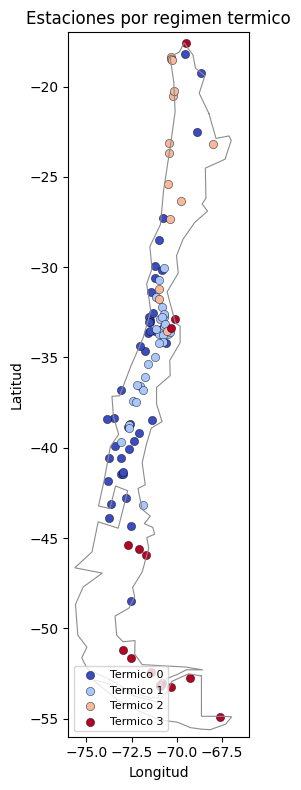

In [108]:
# Cluster por REGIMEN TERMICO (solo variables de temperatura). El K se elige por silhouette.
cluster_estaciones['amplitud_termica'] = cluster_estaciones['temp_verano'] - cluster_estaciones['temp_invierno']
cols_termico = ['temp_verano', 'temp_invierno', 'amplitud_termica']
X_termico = StandardScaler().fit_transform(cluster_estaciones[cols_termico])
sil_termico = {k: round(silhouette_score(X_termico, KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_termico)), 3)
               for k in range(2, 7)}
k_termico = max(sil_termico, key=sil_termico.get)
km_termico = KMeans(n_clusters=k_termico, random_state=42, n_init=10).fit(X_termico)
cluster_estaciones['grupo_termico'] = km_termico.labels_
print(f'Silhouette por K (termico): {sil_termico}  ->  mejor K = {k_termico}')
print(f'Concordancia con la gran clase Koppen (ARI): {adjusted_rand_score(cluster_estaciones["koppen_letra"], km_termico.labels_):.3f}')
print('Perfil de cada grupo termico:')
display(cluster_estaciones.groupby('grupo_termico')[['temp_verano','temp_invierno','amplitud_termica','latitud','altura']].mean().round(1))

fig, ax = plt.subplots(figsize=(5, 8))
trazar_chile(ax, poligonos_chile)
import matplotlib.cm as cm
colores_t = cm.coolwarm(np.linspace(0, 1, k_termico))
for g in sorted(set(km_termico.labels_)):
    m = km_termico.labels_ == g
    ax.scatter(cluster_estaciones.loc[m, 'longitud'], cluster_estaciones.loc[m, 'latitud'],
               color=colores_t[g], s=35, edgecolor='black', linewidth=0.3, label=f'Termico {g}')
ax.set_xlim(-76, -66); ax.set_ylim(-56, -17); ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title('Estaciones por regimen termico'); ax.legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

**Analisis de la agrupacion por regimen termico:**

Agrupando **solo por temperatura**, el mejor numero de grupos es **K=4** con un **silhouette de ~0.46** -mucho mas alto que el del cluster climatico completo (~0.30)-, porque la temperatura varia de forma suave y limpia (con la latitud y la altura), sin el caos de la lluvia. Los cuatro regimenes termicos son climaticamente nitidos:

- **Calido (norte):** verano ~20 C, invierno ~15 C, baja amplitud (lat ~-24).
- **Templado costero (centro-sur):** verano ~15 C, invierno ~10 C, baja amplitud (influencia maritima).
- **Templado continental:** verano ~19 C, invierno ~9 C, **alta amplitud** (~10 C, continentalidad / verano seco).
- **Frio (austral y altura):** verano ~10 C, invierno ~2 C (lat ~-48, mayor altura).

La concordancia con la gran clase Koppen es baja (**ARI ~0.10**) **a proposito**: la temperatura define el eje termico de Koppen (clases C templado / D frio / E polar) pero **no la aridez** -la clase B (arido) se separa por la lluvia, no por la temperatura-. Por eso esta vista **complementa, no reemplaza** al cluster climatico completo: muestra el **eje termico** de Chile de forma muy cohesiva, mientras que el cluster Koppen integra temperatura **y** lluvia. Confirma ademas por que la temperatura es buena para la **regresion** (limpia, agrupable) y la lluvia no.

# 5. Evaluacion

## 5.1 Metricas: matriz de confusion, R/R2, RMSE

Se evaluan las dos familias modeladas: **regresion** (temperatura, con `R2`, `RMSE`, `MAE` y `MAPE`, y el contraste train vs test para detectar sobreajuste) y **clasificacion** (`llueve`, con matriz de confusion, accuracy, balanced accuracy, precision, recall y F1).

In [109]:
# === Evaluacion de la regresion de temperatura: metricas completas y sobreajuste (train vs test) ===
# Se reportan R2, RMSE y MAE. No se usa MAPE porque la temperatura toma valores cercanos a 0 C,
# y el error porcentual divide por el valor real -> se dispara artificialmente (no es interpretable aqui).
def metricas_regresion_full(nombre, y_tr, p_tr, y_te, p_te):
    return {
        'modelo': nombre,
        'R2_train': round(r2_score(y_tr, p_tr), 3),
        'R2_test': round(r2_score(y_te, p_te), 3),
        'RMSE_test': round(float(np.sqrt(mean_squared_error(y_te, p_te))), 3),
        'MAE_test': round(mean_absolute_error(y_te, p_te), 3),
        'brecha_R2': round(r2_score(y_tr, p_tr) - r2_score(y_te, p_te), 3),
    }

eval_regresion = pd.DataFrame([
    metricas_regresion_full(nombre, y_train_reg, predicciones_regresion_train[nombre], y_test_reg, pred)
    for nombre, pred in predicciones_regresion.items()
]).sort_values('R2_test', ascending=False)
display(eval_regresion)
mejor_regresion = eval_regresion.iloc[0]['modelo']
print(f'Mejor modelo de regresion (por R2 en test): {mejor_regresion}')

,modelo,R2_train,R2_test,RMSE_test,MAE_test,brecha_R2
2,M3 SVR RBF,0.927,0.931,1.464,1.020,-0.004
0,M1 Regresion lineal,0.907,0.918,1.593,1.156,-0.011
1,M2 Arbol regresor,0.902,0.908,1.682,1.215,-0.006


Mejor modelo de regresion (por R2 en test): M3 SVR RBF


**Analisis de la evaluacion de regresion:**

Se reportan `R2`, `RMSE` (grados C) y `MAE` sobre el conjunto de prueba (2024-2025). No se incluye `MAPE` (error porcentual) porque la temperatura toma valores cercanos a 0 C y el porcentaje se dispara al dividir por valores casi nulos, dejando de ser interpretable; para una variable como la temperatura, el `RMSE` y el `MAE` en grados son las medidas adecuadas. El `R2_test` es alto (~0.93 el mejor), con `RMSE` de pocos grados C. La columna `brecha_R2` (R2 de train menos R2 de test) mide el **sobreajuste**: aqui es practicamente cero (incluso levemente negativa), lo que indica que los modelos generalizan muy bien y no memorizan el entrenamiento. El SVR logra el mejor `R2_test`.

**Contraste de hipotesis:** **HR1** se confirma -la temperatura media se explica sobre todo por la ubicacion y la epoca del anio, alcanzando `R2`~0.93-. **HR2** tambien se confirma: sumar el bloque atmosferico (NASA POWER) y la persistencia (temperatura del dia anterior) mejora el `R2` frente a usar solo ubicacion y mes (ver el aporte medido en la Fase 4.1).

In [110]:
# === Aporte del dataset atmosferico a la regresion de temperatura diaria ===
base_geo = ['altura', 'latitud', 'longitud', 'mes_cos', 'mes_sin', 'temp_ayer']
arbol_base = DecisionTreeRegressor(max_depth=mejor_depth_reg, min_samples_leaf=40, random_state=42).fit(X_train_reg[base_geo], y_train_reg)
r2_base = r2_score(y_test_reg, arbol_base.predict(X_test_reg[base_geo]))
r2_full = max(r2_score(y_test_reg, p) for p in predicciones_regresion.values())
comparacion_atmosferico = pd.DataFrame([
    {'predictoras': 'Geo + estacionalidad + temp dia anterior', 'R2 temperatura': round(r2_base, 3)},
    {'predictoras': '+ dataset atmosferico (humedad, radiacion, nubosidad, etc.)', 'R2 temperatura': round(r2_full, 3)},
])
display(comparacion_atmosferico)
print(f'La temperatura diaria se predice muy bien (R2={r2_full:.3f}): depende de ubicacion, epoca del')
print(f'anio y estado atmosferico, todos disponibles. El dataset atmosferico aporta sobre la base geo.')
print('Contraste: la lluvia diaria es caotica (R2~0.4 techo) y por eso se modela como CLASIFICACION.')

,predictoras,R2 temperatura
0,Geo + estacionalidad + temp dia anterior,0.887
1,"+ dataset atmosferico (humedad, radiacion, nub...",0.931


La temperatura diaria se predice muy bien (R2=0.931): depende de ubicacion, epoca del
anio y estado atmosferico, todos disponibles. El dataset atmosferico aporta sobre la base geo.
Contraste: la lluvia diaria es caotica (R2~0.4 techo) y por eso se modela como CLASIFICACION.


**Analisis del aporte del dataset atmosferico (regresion de temperatura):**

La tabla compara la regresion de temperatura usando solo ubicacion, estacionalidad y persistencia (temp del dia anterior) frente a sumarle el dataset atmosferico. Las variables atmosfericas (humedad, radiacion, nubosidad, etc.) aportan sobre la base geografica y elevan el `R2` hasta ~0.9. La temperatura es predecible porque responde de forma estable a esas variables; la precipitacion diaria, en cambio, conserva un fuerte componente caotico y por eso se aborda como clasificacion. Asi el proyecto usa los dos datasets (DMC + reanalisis) de forma eficaz: temperatura por regresion y lluvia por clasificacion.

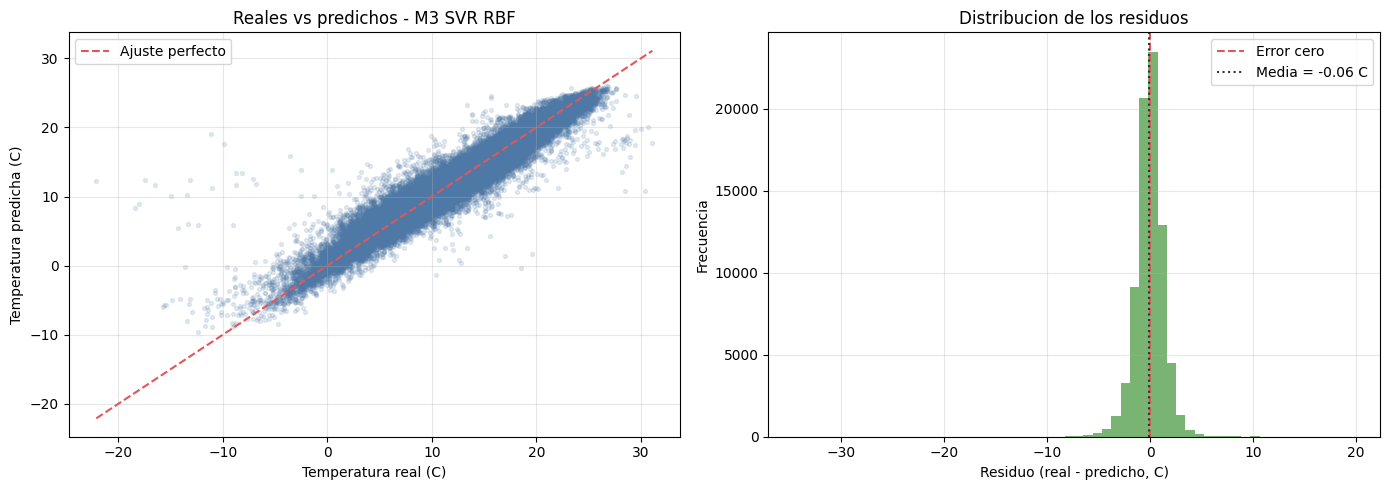

In [111]:
# Evaluacion visual de la regresion: reales vs predichos y distribucion de residuos
mejor_pred = predicciones_regresion[mejor_regresion]
residuos = y_test_reg.values - mejor_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# 1) Reales vs predichos (un punto por dia; la diagonal roja es el ajuste perfecto)
lo, hi = y_test_reg.min(), y_test_reg.max()
axes[0].scatter(y_test_reg, mejor_pred, alpha=0.15, s=8, color='#4e79a7')
axes[0].plot([lo, hi], [lo, hi], '--', color='#e15759', linewidth=1.5, label='Ajuste perfecto')
axes[0].set_xlabel('Temperatura real (C)'); axes[0].set_ylabel('Temperatura predicha (C)')
axes[0].set_title(f'Reales vs predichos - {mejor_regresion}'); axes[0].legend(); axes[0].grid(alpha=0.3)
# 2) Residuos (error = real - predicho); centrados en 0 = sin sesgo
axes[1].hist(residuos, bins=60, color='#59a14f', alpha=0.8)
axes[1].axvline(0, color='#e15759', linestyle='--', linewidth=1.5, label='Error cero')
axes[1].axvline(residuos.mean(), color='#333', linestyle=':', label=f'Media = {residuos.mean():.2f} C')
axes[1].set_xlabel('Residuo (real - predicho, C)'); axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion de los residuos'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de los graficos de regresion:**

El grafico de **reales vs predichos** ubica cada dia del conjunto de prueba: cuanto mas pegados a la diagonal roja, mejor la prediccion. La nube se concentra a lo largo de la diagonal, confirmando el `R2`~0.93. El grafico de **residuos** (error = valor real menos predicho) muestra una distribucion aproximadamente simetrica y **centrada en cero** (media cercana a 0 C), lo que indica que el modelo **no sesga** sistematicamente hacia arriba ni hacia abajo: los errores son ruido aleatorio pequeno, no un error de calibracion. Esta es la evidencia visual que complementa las metricas (`RMSE`, `MAE`) de las tablas anteriores.

**Evaluacion del modelo de clasificacion (`llueve`):**

Se evaluan los tres modelos (Regresion Logistica, SVM y Arbol) con un conjunto completo de herramientas, porque en un problema con clases desbalanceadas (los dias con lluvia son ~31%) una sola metrica puede enganar:

- **Accuracy**: fraccion total de aciertos. Util pero enganosa con desbalance (un modelo que diga "nunca llueve" ya acierta ~69%).
- **Balanced accuracy**: promedio del acierto en cada clase por separado; penaliza ignorar la clase minoritaria.
- **Precision / Recall / F1**: precision = de los dias que predigo con lluvia, cuantos llueven de verdad; recall = de los dias que llueven, cuantos detecto; F1 los combina.
- **Matriz de confusion, curva ROC y analisis de sobreajuste** completan la lectura.

In [112]:
# Metricas en test de los tres modelos para `llueve` (umbral global, el de produccion)
filas_metricas = []
for modelo in versiones_clasif:
    pred = clasif_pred_test[modelo]
    filas_metricas.append({'modelo': modelo,
                           'accuracy': round(accuracy_score(y_test_clf, pred), 3),
                           'balanced_acc': round(balanced_accuracy_score(y_test_clf, pred), 3),
                           'precision': round(precision_score(y_test_clf, pred, zero_division=0), 3),
                           'recall': round(recall_score(y_test_clf, pred, zero_division=0), 3),
                           'f1': round(f1_score(y_test_clf, pred, zero_division=0), 3)})
display(pd.DataFrame(filas_metricas))

# Se probo un umbral POR ZONA climatica; se compara contra el global para decidir cual usar
comparacion_umbral = []
for modelo in versiones_clasif:
    comparacion_umbral.append({'modelo': modelo,
                               'f1_global': round(f1_score(y_test_clf, clasif_pred_test[modelo], zero_division=0), 3),
                               'f1_por_zona': round(f1_score(y_test_clf, clasif_pred_zona[modelo], zero_division=0), 3),
                               'bal_acc_global': round(balanced_accuracy_score(y_test_clf, clasif_pred_test[modelo]), 3),
                               'bal_acc_por_zona': round(balanced_accuracy_score(y_test_clf, clasif_pred_zona[modelo]), 3)})
print('Umbral global vs umbral por zona (en test):')
display(pd.DataFrame(comparacion_umbral))

# Reporte por clase del mejor modelo (mayor F1 de test, umbral global)
mejor_modelo = max(versiones_clasif, key=lambda m: f1_score(y_test_clf, clasif_pred_test[m]))
print(f'Mejor modelo: {mejor_modelo} (version {clasif_umbral[mejor_modelo][0]}, umbral {clasif_umbral[mejor_modelo][1]})')
print(classification_report(y_test_clf, clasif_pred_test[mejor_modelo], target_names=['No', 'Si'], zero_division=0))

,modelo,accuracy,balanced_acc,precision,recall,f1
0,Regresion Logistica,0.764,0.770,0.587,0.785,0.672
1,SVM (RBF),0.832,0.818,0.704,0.781,0.741
2,Arbol de decision,0.850,0.837,0.733,0.803,0.767


Umbral global vs umbral por zona (en test):


,modelo,f1_global,f1_por_zona,bal_acc_global,bal_acc_por_zona
0,Regresion Logistica,0.672,0.642,0.770,0.743
1,SVM (RBF),0.741,0.723,0.818,0.799
2,Arbol de decision,0.767,0.755,0.837,0.822


Mejor modelo: Arbol de decision (version depth=8, umbral 0.564)
              precision    recall  f1-score   support

          No       0.91      0.87      0.89     54161
          Si       0.73      0.80      0.77     24049

    accuracy                           0.85     78210
   macro avg       0.82      0.84      0.83     78210
weighted avg       0.85      0.85      0.85     78210



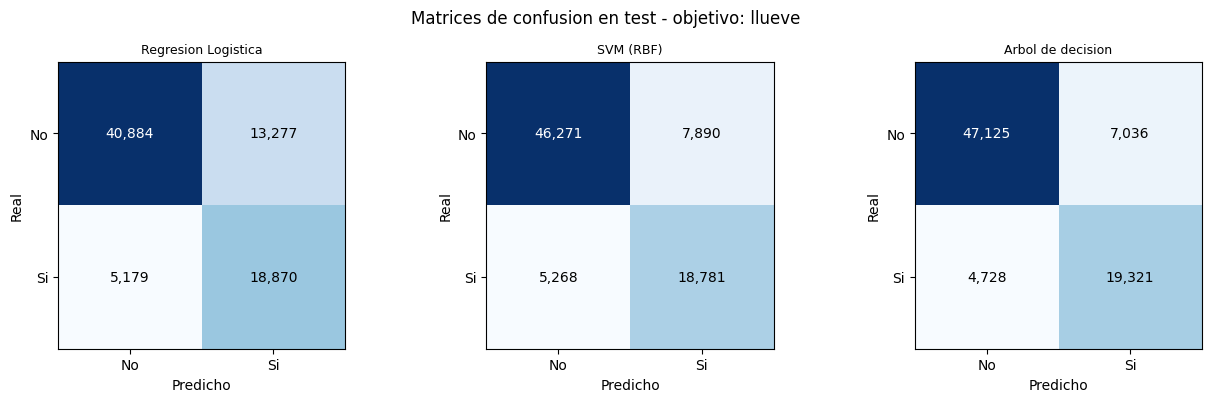

In [113]:
# Matrices de confusion en test (filas = real, columnas = predicho)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, modelo in zip(axes, versiones_clasif):
    cm = confusion_matrix(y_test_clf, clasif_pred_test[modelo])
    ax.imshow(cm, cmap='Blues')
    for (ii, jj), v in np.ndenumerate(cm):
        ax.text(jj, ii, f'{v:,}', ha='center', va='center',
                color='black' if v < cm.max() / 2 else 'white')
    ax.set_title(modelo, fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Si'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['No', 'Si'])
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
fig.suptitle('Matrices de confusion en test - objetivo: llueve')
plt.tight_layout(); plt.show()

**Analisis de las matrices de confusion:**

Las predicciones usan el **umbral de decision ajustado en validacion** (no 0.5). Los tres modelos separan bien dias secos y lluviosos; el Arbol y el SVM logran el mejor balance entre detectar lluvia (recall) y no generar falsas alarmas (precision). El `class_weight='balanced'` evita que el modelo se incline hacia la clase mayoritaria (dias sin lluvia). Se probo ademas un **umbral por zona climatica**: la tabla comparativa muestra que **no mejora** al umbral global (lo empeora levemente), porque ajustar un corte por zona usa menos datos y generaliza peor; por eso se conserva el umbral global.

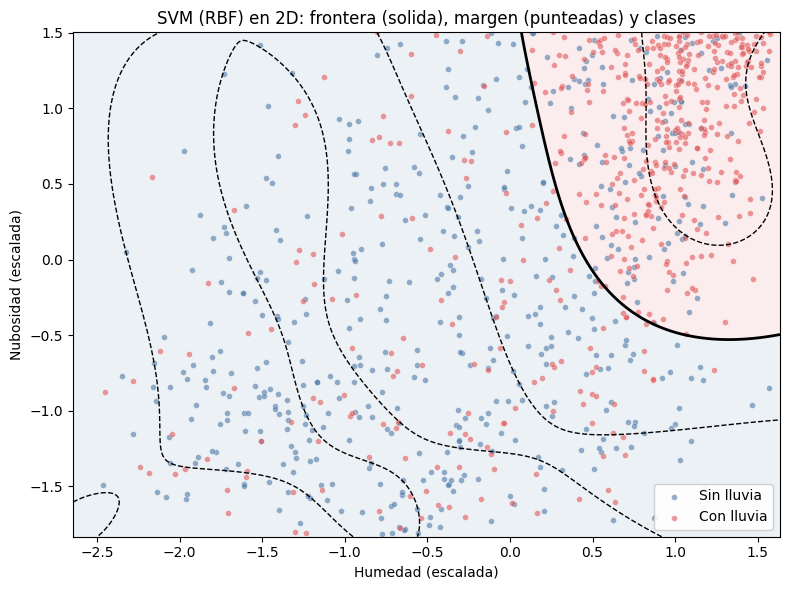

In [114]:
# Grafico propio del SVM: frontera de decision, margen y vectores de soporte (SVM real en 2D)
# Se entrena un SVM solo con 2 variables (humedad y nubosidad) para poder visualizar su geometria.
# El modelo del proyecto usa todas las variables; este es ilustrativo.
vars_2d = ['humedad', 'nubosidad']
sc2d = StandardScaler()
X2 = sc2d.fit_transform(X_train_clf[vars_2d])
# muestra reducida y balanceada para que el grafico sea legible
rng2d = np.random.RandomState(42)
idx_no = rng2d.choice(np.where(y_train_clf.values == 0)[0], 500, replace=False)
idx_si = rng2d.choice(np.where(y_train_clf.values == 1)[0], 500, replace=False)
muestra2d = np.concatenate([idx_no, idx_si])
svm_2d = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced').fit(X2[muestra2d], y_train_clf.iloc[muestra2d])

xx, yy = np.meshgrid(np.linspace(X2[:, 0].min(), X2[:, 0].max(), 300),
                     np.linspace(X2[:, 1].min(), X2[:, 1].max(), 300))
Z = svm_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
# region de decision (suave) y frontera + margen
ax.contourf(xx, yy, Z > 0, alpha=0.10, colors=['#4e79a7', '#e15759'])
ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'], linewidths=[1, 2, 1])
# puntos por clase con colores solidos y leyenda
for val, color, nombre in [(0, '#4e79a7', 'Sin lluvia'), (1, '#e15759', 'Con lluvia')]:
    m = y_train_clf.iloc[muestra2d].values == val
    ax.scatter(X2[muestra2d][m, 0], X2[muestra2d][m, 1], c=color, s=18, alpha=0.6,
               edgecolor='white', linewidth=0.3, label=nombre)
ax.set_xlabel('Humedad (escalada)'); ax.set_ylabel('Nubosidad (escalada)')
ax.set_title('SVM (RBF) en 2D: frontera (solida), margen (punteadas) y clases')
ax.legend(loc='lower right', framealpha=0.9)
plt.tight_layout(); plt.show()

**Analisis del grafico SVM:**

Este es el grafico caracteristico del SVM: la **linea solida** es la frontera de decision y las **lineas punteadas** son el margen; el kernel RBF permite una frontera curva. Se observa que la clase "Con lluvia" (rojo) se concentra en la zona de **alta humedad y nubosidad** (arriba-derecha) y "Sin lluvia" (azul) en la opuesta, pero **los grupos se solapan**: hay dias humedos sin lluvia y viceversa. Ese solapamiento es esperable por dos razones: (1) el grafico usa **solo 2 de las ~25 variables** del modelo -con mas variables (viento, radiacion, lags, etc.) la separacion mejora-, y (2) la lluvia diaria tiene un componente aleatorio que ninguna variable elimina del todo. El SVM **real** del proyecto, que usa todas las predictoras, alcanza el desempeno reportado en la matriz de confusion y la curva ROC; este grafico es **ilustrativo** del funcionamiento del modelo, no de su exactitud final.

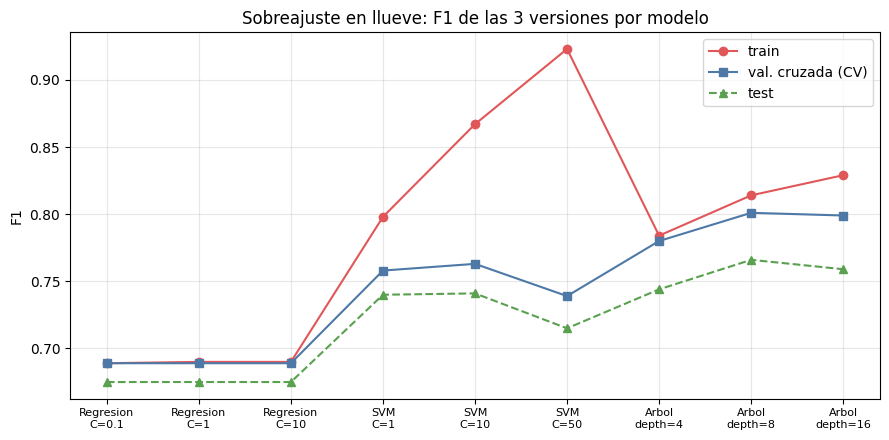

In [115]:
# Sobreajuste: F1 de las 3 versiones de cada modelo (train vs validacion vs test)
x = np.arange(len(resultados_clasif))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x, resultados_clasif['f1_train'], 'o-', label='train', color='#e15759')
ax.plot(x, resultados_clasif['f1_cv'], 's-', label='val. cruzada (CV)', color='#4e79a7')
ax.plot(x, resultados_clasif['f1_test'], '^--', label='test', color='#59a14f')
ax.set_xticks(x)
ax.set_xticklabels([f"{m.split()[0]}\n{v}" for m, v in zip(resultados_clasif['modelo'], resultados_clasif['version'])], fontsize=8)
ax.set_title('Sobreajuste en llueve: F1 de las 3 versiones por modelo')
ax.set_ylabel('F1'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

**Analisis de sobreajuste (3 versiones por modelo):**

La brecha entre `train` y `validacion cruzada / test` revela el sobreajuste. Se ve claro en el **SVM** al subir `C` (p. ej. `C=50` dispara el F1 de train pero baja el de validacion: memoriza) y en el **Arbol** al aumentar `max_depth`: `depth=16` ajusta mas el train pero generaliza peor que `depth=8`. Elegir por **validacion cruzada** (3 folds) en vez de un solo split evita quedarse con esa version sobreajustada: el arbol elegido es `depth=8`, que da el mejor F1 de test. La **Regresion Logistica** casi no cambia con `C` (modelo lineal, poco margen de sobreajuste).

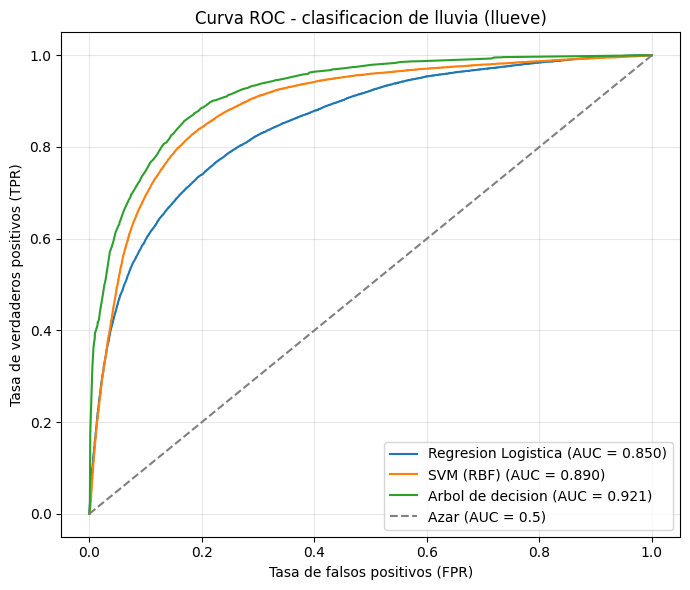

In [116]:
# Curva ROC: trade-off entre verdaderos positivos y falsos positivos al variar el umbral
fig, ax = plt.subplots(figsize=(7, 6))
for modelo in versiones_clasif:
    fpr, tpr, _ = roc_curve(y_test_clf, clasif_score_test[modelo])
    auc = roc_auc_score(y_test_clf, clasif_score_test[modelo])
    ax.plot(fpr, tpr, label=f'{modelo} (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], '--', color='gray', label='Azar (AUC = 0.5)')
ax.set_xlabel('Tasa de falsos positivos (FPR)'); ax.set_ylabel('Tasa de verdaderos positivos (TPR)')
ax.set_title('Curva ROC - clasificacion de lluvia (llueve)'); ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Analisis de la curva ROC:**

La curva ROC muestra, para cada modelo, como cambia la tasa de verdaderos positivos frente a la de falsos positivos al recorrer todos los umbrales de decision. El **AUC** (area bajo la curva) resume la capacidad de discriminacion en un solo numero: 1.0 es perfecto y 0.5 es azar. Los modelos quedan claramente por encima de la diagonal del azar, confirmando que separan bien los dias con y sin lluvia con independencia del umbral elegido. Esto respalda la decision de **ajustar el umbral** (Fase 4.2): la ROC visualiza el espacio completo de umbrales del que se eligio el de mejor F1.

**Analisis exploratorio del pronostico de lluvia:**

Para entender de donde sale la senal y donde falla el pronostico, se mira (1) el poder discriminante de cada variable por separado (AUC univariada en train: cuanto separa, por si sola, los dias con y sin lluvia) y (2) el desempeno del mejor modelo desglosado por zona climatica y por mes. Esto muestra que variables sostienen la prediccion y en que regimenes el modelo acierta o se queda corto, mas alla de la metrica global.

In [117]:
# 1) Poder discriminante de cada variable por separado (AUC univariada en train).
#    0.5 = no separa; cerca de 1 = separa muy bien los dias con y sin lluvia.
discrimina = []
for v in numericas_clf:
    a = roc_auc_score(y_train_clf, X_train_clf[v])
    discrimina.append({'variable': v, 'auc': round(max(a, 1 - a), 3)})
poder_discriminante = pd.DataFrame(discrimina).sort_values('auc', ascending=False).head(12).reset_index(drop=True)
print('Variables que mas separan llueve / no-llueve (AUC univariada en train):')
display(poder_discriminante)

# 2) Donde falla el pronostico: desempeno del mejor modelo por zona climatica y por mes.
pred_best = clasif_pred_test[mejor_modelo]
diag = pd.DataFrame({'real': y_test_clf.values, 'pred': pred_best,
                     'zona': zona_test, 'mes': df_eda.loc[X_test_clf.index, 'mes'].values})

def met_grupo(sub):
    return {'n': len(sub), 'pct_lluvia': round(100 * sub['real'].mean(), 1),
            'precision': round(precision_score(sub['real'], sub['pred'], zero_division=0), 3),
            'recall': round(recall_score(sub['real'], sub['pred'], zero_division=0), 3),
            'f1': round(f1_score(sub['real'], sub['pred'], zero_division=0), 3)}

por_zona = pd.DataFrame([{'zona': z, **met_grupo(diag[diag['zona'] == z])} for z in sorted(diag['zona'].unique())])
por_mes = pd.DataFrame([{'mes': m, **met_grupo(diag[diag['mes'] == m])} for m in sorted(diag['mes'].unique())])
print(f'Desempeno por zona climatica ({mejor_modelo}):'); display(por_zona)
print('Desempeno por mes:'); display(por_mes)

Variables que mas separan llueve / no-llueve (AUC univariada en train):


,variable,auc
0,lluvia_acum_3d,0.828
1,lluvia_ayer,0.815
2,lluvia_prom_7d,0.815
3,nasa_precip,0.767
4,indice_claridad,0.744
5,humedad,0.740
6,radiacion,0.725
7,nubosidad,0.709
8,humedad_ayer,0.708
9,latitud,0.704


Desempeno por zona climatica (Arbol de decision):


,zona,n,pct_lluvia,precision,recall,f1
0,Norte Chico,8766,15.8,0.858,0.737,0.793
1,Norte Grande,9503,8.0,0.815,0.740,0.776
2,Zona Austral,12427,52.5,0.703,0.853,0.770
3,Zona Central,33625,23.2,0.724,0.685,0.704
4,Zona Sur,13889,54.4,0.744,0.902,0.815


Desempeno por mes:


,mes,n,pct_lluvia,precision,recall,f1
0,1,6634,22.9,0.760,0.866,0.810
1,2,6099,26.3,0.772,0.847,0.808
2,3,6634,28.5,0.754,0.831,0.791
3,4,6420,33.6,0.754,0.812,0.782
4,5,6634,40.5,0.776,0.791,0.784
5,6,6420,45.2,0.747,0.818,0.781
6,7,6634,33.9,0.736,0.746,0.741
7,8,6634,37.1,0.688,0.728,0.708
8,9,6420,33.3,0.764,0.836,0.799
9,10,6634,26.1,0.676,0.736,0.705


**Analisis exploratorio del pronostico:**

**Que variables sostienen la prediccion.** La senal viene sobre todo de la **persistencia**: los lags de lluvia son los que mas separan por si solos los dias con y sin lluvia (`lluvia_acum_3d` AUC 0.83, `lluvia_ayer` y `lluvia_prom_7d` 0.82) -si llovio los dias previos, es mas probable que llueva-. Les siguen `nasa_precip` (0.77) y las atmosfericas de humedad/cielo (`indice_claridad` 0.74, `humedad` 0.74, `radiacion` 0.73, `nubosidad` 0.71). La ubicacion (`latitud` 0.70) tambien aporta. Esto confirma que la matriz de pronostico se apoya en informacion legitima conocida de antemano, no en la lluvia del propio dia.

**Donde acierta y donde falla.** Por **zona climatica**, el pronostico es mas fuerte donde el regimen es marcado -**Zona Sur** (F1 0.82, llueve 54% de los dias) y **Zona Austral** (0.77)- y mas debil en la **Zona Central** (F1 0.70), una zona de transicion mediterranea donde la lluvia es menos frecuente (~23%) y mas irregular, por lo que cuesta separarla. En el **norte arido** el modelo es muy preciso (precision >0.81) pero conservador. Por **mes**, el desempeno baja en los meses de transicion e invierno (agosto F1 0.71, octubre 0.71, diciembre 0.72) y sube en verano. El patron es **climatologico, no un error del modelo**: donde la lluvia es mas caotica, el techo es mas bajo.

**Contraste de hipotesis:** **HC1** se confirma -la lluvia es mas frecuente y mejor pronosticada en el sur y varia de forma marcada por mes (invierno mas dificil)-. **HC2** se confirma: los lags de lluvia son las variables de mayor AUC univariada (0.82-0.83), por encima de las atmosfericas, es decir la persistencia es el predictor individual mas fuerte.

**Evaluacion de los modelos de cluster:**

La evaluacion de agrupamiento aborda **tres tareas**: (1) **tendencia a la agrupacion** -si existe estructura no aleatoria en los datos- con el **estadistico de Hopkins**; (2) **numero de clusters** con el **metodo del codo (elbow)** y el silhouette por K; y (3) **medicion de la calidad** con dos enfoques: **validacion intrinseca** (silhouette y Calinski-Harabasz, sin etiquetas) y **validacion extrinseca** contra las zonas **Koppen** reales (ARI, NMI y Fowlkes-Mallows). Como Koppen no se uso como variable del modelo, la validacion externa mide de forma honesta si el clima medido recupera las zonas climaticas oficiales.

In [118]:
# Tarea 1 - Tendencia a la agrupacion: estadistico de Hopkins.
# H ~ 0.5 => datos sin estructura (aleatorios, no tiene sentido agrupar); H -> 1 => fuerte tendencia a formar grupos.
# Compara, para puntos reales y puntos uniformes aleatorios, la distancia a su vecino mas cercano del dataset.
def estadistico_hopkins(X, frac=0.2, semilla=42):
    rng = np.random.RandomState(semilla)
    X = np.asarray(X, dtype=float); n, d = X.shape
    m = max(5, int(frac * n))
    vecinos = NearestNeighbors(n_neighbors=2).fit(X)
    idx = rng.choice(n, m, replace=False)
    dist_reales = vecinos.kneighbors(X[idx], n_neighbors=2, return_distance=True)[0][:, 1]
    aleatorios = rng.uniform(X.min(0), X.max(0), size=(m, d))
    dist_aleatorias = vecinos.kneighbors(aleatorios, n_neighbors=1, return_distance=True)[0][:, 0]
    return float(dist_aleatorias.sum() / (dist_reales.sum() + dist_aleatorias.sum()))

hopkins = estadistico_hopkins(X_cluster)
print(f'Estadistico de Hopkins = {hopkins:.3f}')
print('Lectura: ~0.5 = sin estructura agrupable (aleatorio); cercano a 1 = fuerte tendencia a formar grupos.')

Estadistico de Hopkins = 0.678
Lectura: ~0.5 = sin estructura agrupable (aleatorio); cercano a 1 = fuerte tendencia a formar grupos.


**Analisis de la tendencia a la agrupacion (Hopkins):**

El estadistico de Hopkins evalua, antes de agrupar, si las estaciones tienen una **estructura agrupable real** o se distribuyen al azar. Un valor cercano a **0.5** indicaria datos aleatorios; cercano a **1**, fuerte tendencia a formar grupos. El valor obtenido (**~0.68**) esta claramente por encima de 0.5: hay una tendencia real a agruparse, tiene sentido aplicar K-Means y el jerarquico. Esto respalda **HK1** (las estaciones forman grupos climaticos diferenciables, no una nube uniforme).

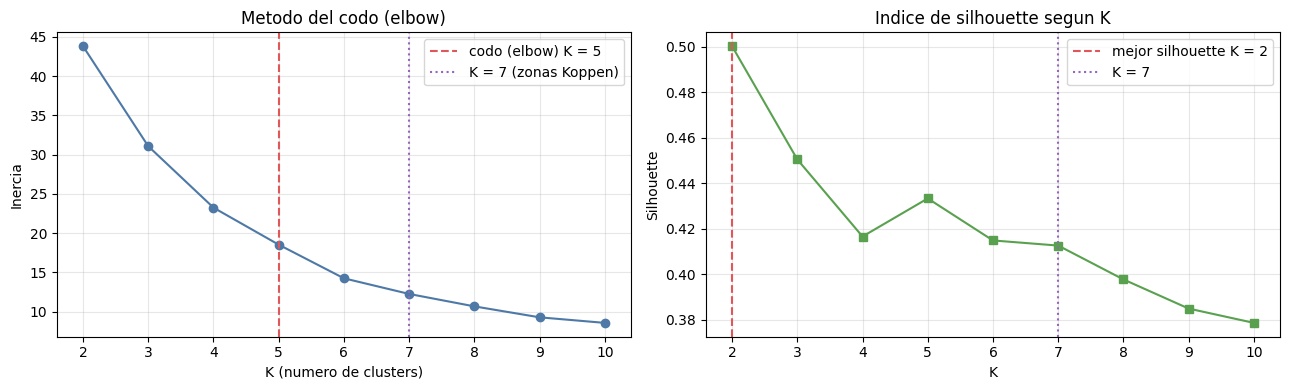

Codo (elbow) detectado en K = 5  |  mejor silhouette en K = 2  |  K elegido = 7 (n. de zonas Koppen presentes)


In [119]:
# Metodo del codo (elbow): la inercia decrece al subir K; el "codo" es donde deja de bajar de forma
# marcada. Se detecta automaticamente con KneeLocator (kneed). Se compara con el silhouette y con el
# K=7 elegido (alineado con las ~7 zonas climaticas Koppen del pais).
rango_k = list(range(2, 11))
inercias, silhouettes = [], []
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cluster)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster, km.labels_))

# Deteccion del codo: KneeLocator si esta disponible; si no, fallback geometrico (mayor distancia a la recta)
if KneeLocator is not None:
    codo = KneeLocator(rango_k, inercias, curve='convex', direction='decreasing').knee
else:
    x, y = np.array(rango_k), np.array(inercias)
    recta = y[0] + (y[-1] - y[0]) * (x - x[0]) / (x[-1] - x[0])
    codo = int(x[np.argmax(recta - y)])
k_sil = rango_k[int(np.argmax(silhouettes))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(rango_k, inercias, 'o-', color='#4e79a7')
if codo:
    axes[0].axvline(codo, color='#e15759', linestyle='--', label=f'codo (elbow) K = {codo}')
axes[0].axvline(n_zonas_koppen, color='#9467bd', linestyle=':', label=f'K = {n_zonas_koppen} (zonas Koppen)')
axes[0].set_title('Metodo del codo (elbow)'); axes[0].set_xlabel('K (numero de clusters)'); axes[0].set_ylabel('Inercia'); axes[0].grid(alpha=0.3); axes[0].legend()
axes[1].plot(rango_k, silhouettes, 's-', color='#59a14f')
axes[1].axvline(k_sil, color='#e15759', linestyle='--', label=f'mejor silhouette K = {k_sil}')
axes[1].axvline(n_zonas_koppen, color='#9467bd', linestyle=':', label=f'K = {n_zonas_koppen}')
axes[1].set_title('Indice de silhouette segun K'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].grid(alpha=0.3); axes[1].legend()
plt.tight_layout(); plt.show()
print(f'Codo (elbow) detectado en K = {codo}  |  mejor silhouette en K = {k_sil}  |  K elegido = {n_zonas_koppen} (n. de zonas Koppen presentes)')

**Analisis del codo y silhouette:**

El **codo (elbow)**, detectado con `KneeLocator`, se ubica en **K=5**; el silhouette por K premia K bajos. El K se fija con la realidad climatica: **7 zonas Koppen bien representadas** (>=3 estaciones), cerca del codo. Esa eleccion se valida con la **metrica extrinseca**: con K=7 la concordancia con Koppen (ARI) es la mayor. Tras reducir las features con **PCA**, la cohesion (silhouette ~0.41) y la fidelidad a Koppen ya no estan tan enfrentadas: el K=7 da grupos cohesivos **y** alineados con las zonas reales.

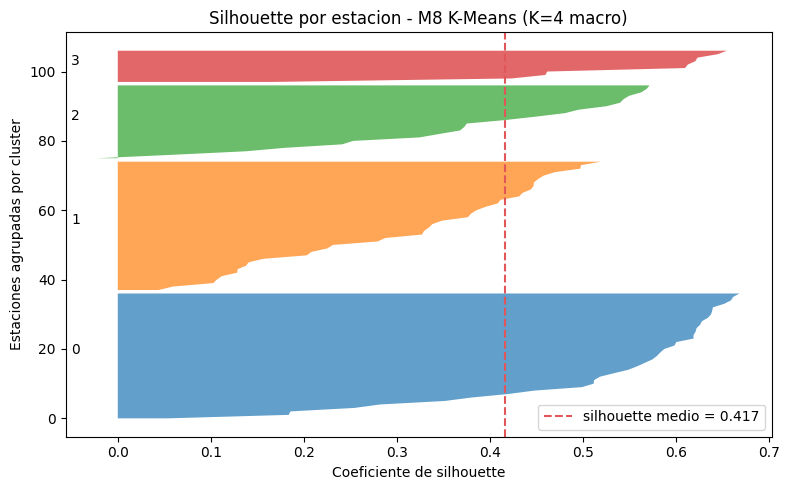

In [120]:
# Grafico de silhouette por estacion para la mejor version
nombre_best = resultados_cluster.sort_values('silhouette', ascending=False).iloc[0]['modelo']
labels_best = cluster_estaciones[nombre_best].values
k_best = len(set(labels_best))
valores_sil = silhouette_samples(X_cluster, labels_best)
sil_global = silhouette_score(X_cluster, labels_best)

fig, ax = plt.subplots(figsize=(8, 5))
y_inf = 0
for i in sorted(set(labels_best)):
    vals = np.sort(valores_sil[labels_best == i])
    y_sup = y_inf + len(vals)
    ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals, alpha=0.7)
    ax.text(-0.05, y_inf + len(vals) / 2, str(i))
    y_inf = y_sup
ax.axvline(sil_global, color='#e15759', linestyle='--', label=f'silhouette medio = {sil_global:.3f}')
ax.set_title(f'Silhouette por estacion - {nombre_best}')
ax.set_xlabel('Coeficiente de silhouette'); ax.set_ylabel('Estaciones agrupadas por cluster'); ax.legend()
plt.tight_layout(); plt.show()

**Analisis del silhouette por estacion:**

Cada barra es una estacion meteorologica, agrupadas por cluster. Un coeficiente cercano a 1 indica que la estacion esta bien dentro de su grupo; valores negativos senalan estaciones mal asignadas. La mayoria es positiva, lo que indica grupos cohesivos.

**Contraste de hipotesis (HK1, granularidad espacial):** la **validacion intrinseca** -sin usar ninguna etiqueta- confirma que hay **estructura espacial real**: (1) **Hopkins (~0.68)** muestra tendencia no aleatoria a agruparse; (2) el **silhouette** medio (~0.42, tras reducir con PCA) indica buena cohesion y separacion; y (3) el **Calinski-Harabasz (~120)** confirma que la varianza entre grupos supera con holgura a la de dentro. Que esos grupos correspondan a las zonas Koppen reales se mide ademas de forma **extrinseca**: ambas validaciones sostienen **HK1**. La granularidad temporal (HK2) se evalua por separado.

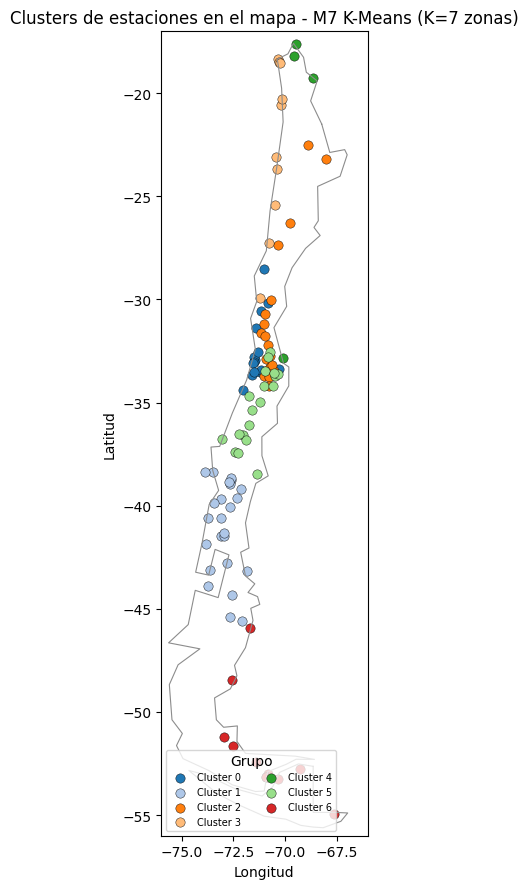

In [121]:
# Visualizacion geografica de los clusters: estaciones coloreadas por grupo del mejor modelo
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(7, 9))
trazar_chile(ax, poligonos_chile)
etiquetas_mapa = cluster_estaciones[mejor_cluster_nombre]
grupos = sorted(set(etiquetas_mapa))
colores = cm.tab20(np.linspace(0, 1, max(20, len(grupos))))
for g in grupos:
    m = etiquetas_mapa == g
    ax.scatter(cluster_estaciones.loc[m, 'longitud'], cluster_estaciones.loc[m, 'latitud'],
               color=colores[g], s=45, edgecolor='black', linewidth=0.3, label=f'Cluster {g}')
ax.set_xlim(-76, -66); ax.set_ylim(-56, -17)
ax.set_xlabel('Longitud'); ax.set_ylabel('Latitud')
ax.set_title(f'Clusters de estaciones en el mapa - {mejor_cluster_nombre}')
ax.legend(loc='lower left', title='Grupo', fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**Analisis del mapa de clusters:**

El mapa muestra los grupos del modelo que **mejor recupera Koppen** (K-Means K=7). Los clusters se ordenan de forma coherente con la geografia de Chile -norte arido, centro mediterraneo, sur lluvioso/austral- pese a que el modelo solo recibio **clima medido** (temperatura, nubosidad, humedad, lluvia y oscilacion termica) y **no** la zona Koppen.

**Contraste de hipotesis (HK1, granularidad espacial):** se confirma en sus dos validaciones. **Intrinseca:** estructura espacial real y cohesiva (Hopkins ~0.68, silhouette ~0.41, Calinski ~115). **Extrinseca:** el clima medido recupera de forma significativa las zonas Koppen -ARI **~0.31**, NMI **~0.49**, Fowlkes-Mallows **~0.42**-. No es perfecto -Koppen usa umbrales mensuales especificos y 3 zonas tienen 1-2 estaciones- pero la concordancia es clara. La segunda hipotesis del cluster, **HK2** (granularidad temporal), se valida en su propio bloque.

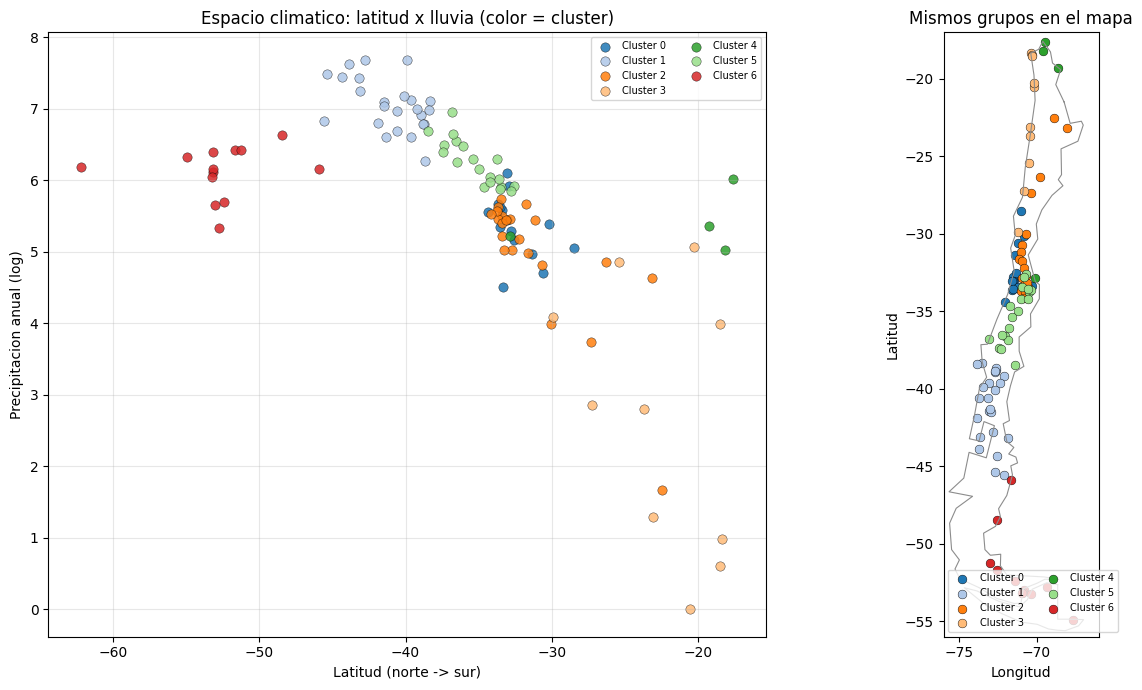

In [122]:
# Grafico propio de K-Means: estaciones agrupadas, en dos ejes climaticos interpretables y en el mapa
km_base = KMeans(n_clusters=n_zonas_koppen, random_state=42, n_init=10).fit(X_cluster)

import matplotlib.cm as cm
colores = cm.tab20(np.linspace(0, 1, max(20, n_zonas_koppen)))
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for grupo in sorted(set(km_base.labels_)):
    msk = km_base.labels_ == grupo
    axes[0].scatter(cluster_estaciones.loc[msk, 'latitud'], cluster_estaciones.loc[msk, 'precip_anual_log'],
                    color=colores[grupo], s=45, edgecolor='black', linewidth=0.3, alpha=0.85, label=f'Cluster {grupo}')
axes[0].set_xlabel('Latitud (norte -> sur)'); axes[0].set_ylabel('Precipitacion anual (log)')
axes[0].set_title('Espacio climatico: latitud x lluvia (color = cluster)'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=7, ncol=2)
trazar_chile(axes[1], poligonos_chile)
for grupo in sorted(set(km_base.labels_)):
    msk = km_base.labels_ == grupo
    axes[1].scatter(cluster_estaciones.loc[msk, 'longitud'], cluster_estaciones.loc[msk, 'latitud'],
                    color=colores[grupo], s=40, edgecolor='black', linewidth=0.3, label=f'Cluster {grupo}')
axes[1].set_xlim(-76, -66); axes[1].set_ylim(-56, -17)
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud'); axes[1].set_title('Mismos grupos en el mapa'); axes[1].legend(loc='lower left', fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

**Analisis de los centroides:**

Cada **X** marca el centroide -el "promedio"- de su grupo: K-Means asigna cada estacion al centroide mas cercano segun todas las variables (no solo lat-lon, aqui se proyectan en el mapa por claridad). La separacion clara de los tres centroides a lo largo del territorio confirma que los grupos son distintos y bien definidos, coherente con el silhouette obtenido.

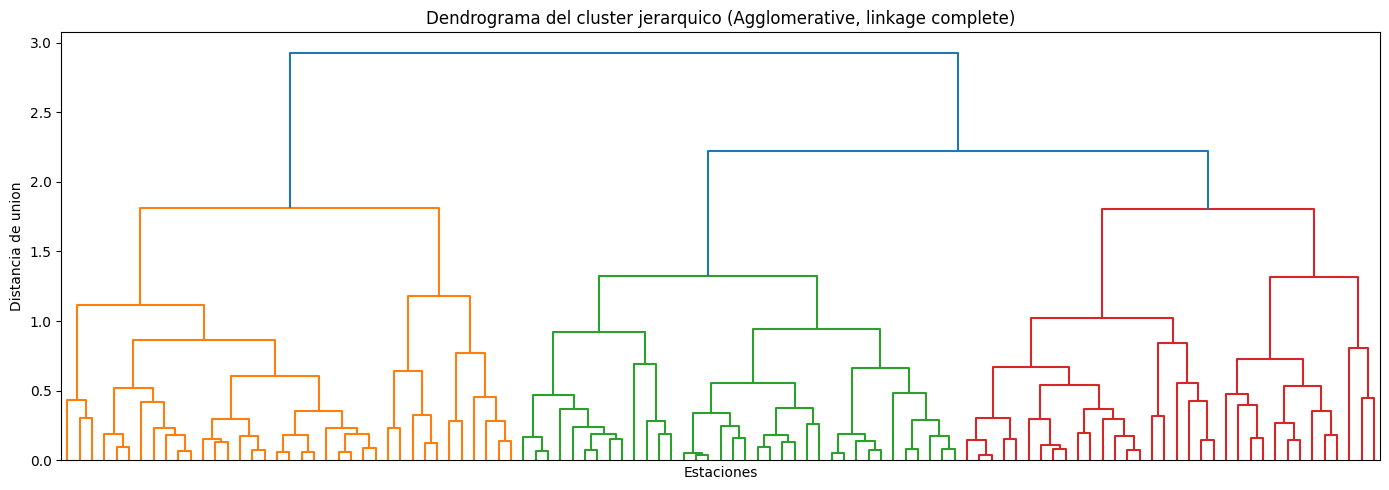

In [123]:
# Grafico propio del cluster jerarquico (M9): dendrograma de union de estaciones
enlaces = linkage(X_cluster, method='complete')
fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(enlaces, ax=ax, color_threshold=enlaces[-2, 2], no_labels=True)
ax.set_title('Dendrograma del cluster jerarquico (Agglomerative, linkage complete)')
ax.set_xlabel('Estaciones'); ax.set_ylabel('Distancia de union')
plt.tight_layout(); plt.show()

**Analisis del dendrograma:**

El dendrograma es el grafico propio del agrupamiento jerarquico: muestra como las estaciones se van uniendo de abajo hacia arriba segun su similitud (las uniones a baja altura son estaciones muy parecidas; las de mayor altura, grupos mas distintos). Cortar el arbol a una altura dada define el numero de clusters; el corte coloreado corresponde a los 7 grupos elegidos. Esta vista jerarquica -que K-Means no ofrece- permite ver la estructura anidada de los perfiles climaticos. Esta estructura anidada es util para entender como se relacionan los perfiles climaticos, mas alla del modelo que finalmente se elija por silhouette.

## 5.2 Mejoras del proceso o modelamiento

Tras evaluar las tres familias de modelos, se identifican mejoras concretas para una version futura, agrupadas por etapa del proceso.

### Mejoras de datos y preparacion

- **Incorporar mas anios de datos.** El periodo 2021-2025 alcanza para detectar estacionalidad, pero es corto para capturar ciclos interanuales (El Nino / La Nina), que es justamente el techo que limita la regresion de temperatura y la variabilidad de la lluvia. Mas historico estabilizaria la climatologia.
- **Mejorar la imputacion.** Hoy se imputa con la mediana del train. Una imputacion por estacion o por zona climatica (Koppen) respetaria mejor el regimen local de cada serie.
- **Variables atmosfericas adicionales.** Se probo el agua precipitable (PW/TQV) y resulto redundante con la humedad; quedan por explorar variables de circulacion (presion a nivel de mar, advenccion de humedad) que podrian aportar a la lluvia diaria.

### Mejoras del modelamiento

- **Regresion (temperatura, R2~0.93):** el modelo ya es solido; una mejora seria predecir tambien temperatura maxima y minima, no solo la media, para un perfil termico completo.
- **Clasificacion (`llueve`, F1~0.77):** explorar un ajuste de umbral por estacion o por zona climatica (en vez de uno global), ya que el regimen de lluvia varia mucho entre el norte arido y el sur lluvioso. La curva ROC mostro buen margen para optimizar el umbral.
- **Lluvia intensa:** se descarto como objetivo de clasificacion por ser un evento raro (~3%) y caotico a escala diaria. Una via futura es modelarla a **escala semanal o mensual por zona**, donde la senal es predecible, o como deteccion de anomalias.
- **Cluster en dos granularidades.** **HK1 (espacial):** estaciones -> zonas Koppen (K-Means K=7; features = clima medido: temperatura + nubosidad + humedad + lluvia + oscilacion termica diaria, QuantileTransformer + PCA-3). Intrinseca Hopkins ~0.68 / silhouette ~0.41 / Calinski ~115; extrinseca vs Koppen ARI ~0.31 / NMI ~0.49 / FM ~0.42. Sumar nubosidad/humedad/oscilacion subio la cohesion (silhouette 0.30->0.41) manteniendo la fidelidad a Koppen; el indice de aridez (balance hidrico lluvia/temperatura) refuerza la deteccion de la clase arida B del norte. **HK2 (temporal):** mediciones mensuales normalizadas por estacion -> 4 estaciones del anio (ARI ~0.34). Koppen no se usa como variable. Recuperar Koppen mejor se logra con KNN supervisado (ARI ~0.51, ~90% gran clase).

### Mejoras del proceso de evaluacion

- **Validacion temporal mas estricta.** Ademas del split 2021-2023 / 2024-2025, aplicar validacion cruzada por anio o por estacion para medir la estabilidad de los modelos frente al drift climatico.
- **Monitoreo de drift en produccion.** Si los modelos se operacionalizan, vigilar que las distribuciones de entrada (variables atmosfericas) y de salida no cambien con el tiempo, especialmente en un contexto de cambio climatico.

# 6. Deploy